# IRF Reconstruction Validation
## Leica-style per-tile IRF from PTU decay data — no xlsx needed

Reconstructs a tile-specific IRF by extracting the rising edge of the decay
histogram and applying a hard post-peak cut, replicating Leica's internal
IRF construction (validated n=30 single-FOV exports).

### Key insight
Only the rising edge of the decay represents clean IRF — bins after the peak
contain mixed IRF + fluorescence signal. The truncated shape gives χ²_r ≈ 1;
a full symmetric Gaussian gives χ²_r = 10–50.

### Methods compared
| Method | Source | Notes |
|---|---|---|
| **Leica (raw interp)** | `irf_from_xlsx` | Sparse xlsx points interpolated — comparison baseline |
| **Leica (analytical)** | `irf_from_xlsx_analytical` | Gaussian + exp tail fit to xlsx |
| **Reconstructed (new)** | `reconstruct_irf_from_decay` | Bounded BaP rising-edge extraction |
| **Raw estimate** | `estimate_irf_from_decay_raw` | Existing FLIMKit method |
| **Gaussian** | `gaussian_irf_from_fwhm` | Existing FLIMKit (too narrow, χ² = 10–50) |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import curve_fit
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── FLIMKit imports ────────────────────────────────────────────────────────────
from flimkit.PTU.reader import PTUFile
from flimkit.utils.xlsx_tools import load_xlsx
from flimkit.FLIM.irf_tools import (
    irf_from_xlsx,
    irf_from_xlsx_analytical,
    estimate_irf_from_decay_raw,
    gaussian_irf_from_fwhm,
    reconstruct_irf_from_decay,
    compare_irfs,
)
from flimkit.FLIM.fit_tools import find_irf_peak_bin

print("FLIMKit imports OK ✓  (reconstruct_irf_from_decay from library)")


FLIMKit imports OK ✓  (reconstruct_irf_from_decay from library)


In [2]:
# ── Configuration — update these paths ────────────────────────────────────────
PTU_FILE  = Path("/Users/as-hunt/Downloads/2026_02_27_10_38_30--More_to_test/PTU.sptw/well4-FOV1-40x-ado-t20.ptu")
XLSX_FILE = Path("/Users/as-hunt/Downloads/2026_02_27_10_38_30--More_to_test/well4-FOV1-40x-ado-t20.xlsx")

# IRF reconstruction constants (validated across n=30 single FOVs)
BW           = 0.09696970   # ns — universal IRF bin width
NOISE_FLOOR  = 50           # absolute count floor for rising edge detection
NOISE_FRAC   = 0.001        # fraction of peak for rising edge threshold

# Expected σ clusters for QC
SIGMA_NARROW = (0.092, 0.110)   # ns
SIGMA_WIDE   = (0.118, 0.132)   # ns


In [3]:
# ── QC helper (notebook-only — validates reconstructed IRFs) ───────────────────
def qc_irf(irf_norm: np.ndarray, tcspc_res: float, label: str = "") -> dict:
    """QC report for a reconstructed IRF. Returns dict of metrics."""
    tcspc_ns = tcspc_res * 1e9
    pi = np.argmax(irf_norm)

    # FWHM
    half = irf_norm.max() / 2
    above = np.where(irf_norm >= half)[0]
    fwhm_ns = (above[-1] - above[0]) * tcspc_ns if len(above) > 1 else np.nan

    # Gaussian σ from rising edge
    t_ns = np.arange(len(irf_norm)) * tcspc_ns
    rise = (t_ns <= t_ns[pi]) & (irf_norm > 0.01 * irf_norm[pi])
    sigma_ns = np.nan
    try:
        def gauss(t, A, mu, s): return A * np.exp(-0.5 * ((t - mu) / s) ** 2)
        popt, _ = curve_fit(gauss, t_ns[rise], irf_norm[rise],
                            p0=[irf_norm[pi], t_ns[pi], 0.12], maxfev=5000)
        sigma_ns = abs(popt[2])
    except Exception:
        pass

    nz = np.where(irf_norm > 0)[0]
    bap = nz[-1] - pi if len(nz) else 0

    in_cluster = (SIGMA_NARROW[0] <= sigma_ns <= SIGMA_NARROW[1] or
                  SIGMA_WIDE[0]   <= sigma_ns <= SIGMA_WIDE[1])

    tag = f" [{label}]" if label else ""
    print(f"QC{tag}")
    print(f"  Peak bin : {pi}   BaP: {bap}  {'✓' if bap in (1,2) else '⚠'}")
    print(f"  σ        : {sigma_ns:.4f} ns  {'✓' if in_cluster else '⚠ outside known clusters'}")
    print(f"  FWHM     : {fwhm_ns:.4f} ns")

    return dict(peak_bin=pi, bap=bap, sigma_ns=sigma_ns, fwhm_ns=fwhm_ns,
                in_cluster=in_cluster)

# ── Verify reconstruct_irf_from_decay signature ──────────────────────────────
import inspect
sig = inspect.signature(reconstruct_irf_from_decay)
print(f"reconstruct_irf_from_decay{sig}")
print(f"qc_irf() defined ✓")


reconstruct_irf_from_decay(decay: numpy.ndarray, tcspc_res: float, n_bins: int, noise_floor: float = 50, noise_frac: float = 0.001, max_bap: int = 2, verbose: bool = False) -> numpy.ndarray
qc_irf() defined ✓


In [4]:
# ── Load PTU ──────────────────────────────────────────────────────────────────
if not PTU_FILE.exists():
    raise FileNotFoundError(f"PTU not found: {PTU_FILE}\nUpdate PTU_FILE in config cell.")

ptu = PTUFile(str(PTU_FILE), verbose=True)
decay     = ptu.summed_decay()
t_ns      = ptu.time_ns          # bin centres (n_bins,)
tcspc_res = ptu.tcspc_res        # seconds
n_bins    = ptu.n_bins

print(f"\nPTU loaded: {PTU_FILE.name}")
print(f"  {n_bins} bins  ×  {tcspc_res*1e12:.2f} ps  |  peak={decay.max():.0f} cts  "
      f"at bin {np.argmax(decay)} (t={t_ns[np.argmax(decay)]:.4f} ns)")

# ── Load XLSX ─────────────────────────────────────────────────────────────────
if not XLSX_FILE.exists():
    raise FileNotFoundError(f"XLSX not found: {XLSX_FILE}\nUpdate XLSX_FILE in config cell.")

print(f"\nLoading XLSX: {XLSX_FILE.name}")
xlsx = load_xlsx(str(XLSX_FILE))


 

PTU loaded: well4-FOV1-40x-ado-t20.ptu
  532 bins  ×  96.97 ps  |  peak=135137 cts  at bin 30 (t=2.9576 ns)

Loading XLSX: well4-FOV1-40x-ado-t20.xlsx
    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 22 pts
    irf_c       : 22 pts
    fit_t       : 462 pts
    fit_c       : 462 pts
    res_t       : 462 pts
    res_c       : 462 pts


In [5]:
# ── Build all IRFs ─────────────────────────────────────────────────────────────
irfs = {}

# 1. Leica raw (interpolated xlsx points) — comparison baseline
try:
    irfs['Leica (interp)'] = irf_from_xlsx(xlsx, n_bins, tcspc_res)
    print("✓ Leica (interp)")
except Exception as e:
    print(f"✗ Leica (interp): {e}")

# 2. Leica analytical (Gaussian + exp tail fit to xlsx)
try:
    irfs['Leica (analytical)'], _ = irf_from_xlsx_analytical(xlsx, n_bins, tcspc_res,
                                                              verbose=False)
    print("✓ Leica (analytical)")
except Exception as e:
    print(f"✗ Leica (analytical): {e}")

# 3. ★ Reconstructed from decay — the new library function ★
#    Uses bounded max_bap instead of unbounded "walk until zero"
try:
    irfs['Reconstructed (new)'] = reconstruct_irf_from_decay(
        decay, tcspc_res, n_bins,
        noise_floor=NOISE_FLOOR,
        noise_frac=NOISE_FRAC,
        max_bap=2,
        verbose=True,
    )
    print("✓ Reconstructed (new)")
except Exception as e:
    print(f"✗ Reconstructed (new): {e}")

# 4. Existing raw estimate
try:
    irfs['Raw estimate'] = estimate_irf_from_decay_raw(decay, tcspc_res, n_bins)
    print("✓ Raw estimate")
except Exception as e:
    print(f"✗ Raw estimate: {e}")

# 5. Gaussian (FWHM = 1 bin width — the prior approach that gave χ² = 10–50)
try:
    peak_bin = find_irf_peak_bin(decay)
    fwhm_1bin = tcspc_res * 1e9  # 1 bin width in ns
    irfs['Gaussian (1-bin FWHM)'] = gaussian_irf_from_fwhm(n_bins, tcspc_res,
                                                             fwhm_1bin, peak_bin)
    print("✓ Gaussian (1-bin FWHM)")
except Exception as e:
    print(f"✗ Gaussian (1-bin FWHM): {e}")

print(f"\n{len(irfs)} IRFs ready.")


✓ Leica (interp)
✓ Leica (analytical)
  IRF reconstructed from decay rising edge:
    Peak bin (decay)  = 30  →  IRF peak bin = 29
    Rising edge       = 5 bins
    Bins after peak   = 2
    IRF extent        = bins 24..31  (8 bins)
    FWHM (grid)       = 290.9 ps
✓ Reconstructed (new)
✓ Raw estimate
✓ Gaussian (1-bin FWHM)

5 IRFs ready.


In [6]:
# ── QC report for all IRFs ────────────────────────────────────────────────────
print("=" * 55)
qc_results = {}
for label, irf in irfs.items():
    qc_results[label] = qc_irf(irf, tcspc_res, label=label)
    print()


QC [Leica (interp)]
  Peak bin : 30   BaP: 2  ✓
  σ        : 0.0788 ns  ⚠ outside known clusters
  FWHM     : 0.0970 ns

QC [Leica (analytical)]
  Peak bin : 30   BaP: 501  ⚠
  σ        : 0.0779 ns  ⚠ outside known clusters
  FWHM     : 0.0970 ns

QC [Reconstructed (new)]
  Peak bin : 29   BaP: 2  ✓
  σ        : 0.1393 ns  ⚠ outside known clusters
  FWHM     : 0.2909 ns

QC [Raw estimate]
  Peak bin : 30   BaP: 10  ⚠
  σ        : 0.1391 ns  ⚠ outside known clusters
  FWHM     : 0.4848 ns

QC [Gaussian (1-bin FWHM)]
  Peak bin : 28   BaP: 16  ⚠
  σ        : nan ns  ⚠ outside known clusters
  FWHM     : nan ns



In [7]:
# ── compare_irfs: quantitative comparison against Leica (interp) ──────────────
# Uses FLIMKit's existing compare_irfs() for RMSE, Pearson r, Bhattacharyya
print("Comparing all methods against Leica (interp):\n")

ref_label = 'Leica (interp)'
if ref_label in irfs:
    for label, irf in irfs.items():
        if label == ref_label:
            continue
        print(f"  {label}")
        try:
            compare_irfs(
                irf_estimated = irf,
                xlsx          = xlsx,
                tcspc_res     = tcspc_res,
                n_bins        = n_bins,
                strategy      = label,
                out_prefix    = '',
            )
        except Exception as e:
            print(f"    compare_irfs failed: {e}")
        print()
else:
    print("Leica (interp) IRF not available — skipping comparison.")


Comparing all methods against Leica (interp):

  Leica (analytical)

  IRF Comparison  (Leica (analytical)  vs  xlsx)
  Metric                          Estimated         xlsx
  ──────────────────────────────────────────────────────
  FWHM (ns)                          0.0970       0.0970
  Peak position (ns)                 2.9091       2.9091
  Peak shift (est − xlsx)          +0.0000 ns  (+0 bins)
  ──────────────────────────────────────────────────────
  [raw     (unaligned)]
    Pearson r                        0.9976
    RMSE (normalised)              0.002089
    Overlap score (1−RMSE)           0.9979
    Bhattacharyya coeff.             0.9773
  [aligned (peak-shift corrected)]
    Pearson r                        0.9976
    RMSE (normalised)              0.002089
    Overlap score (1−RMSE)           0.9979
    Bhattacharyya coeff.             0.9773

  ~ Acceptable shape match after alignment (BC=0.9773)
    → Shape is reasonable but consider --xlsx for fitting.
  Saved: _irf_

## Fitting validation — χ²_r with each IRF method

The real test: run `fit_summed` with each IRF and compare χ²_r.
- χ²_r ≈ 1 → correct IRF shape
- χ²_r = 10–50 → IRF is wrong (too narrow, too wide, or wrong shape)


In [8]:
# ── Fit with each IRF and compare χ²_r ────────────────────────────────────────
from flimkit.FLIM.fitters import fit_summed
from flimkit.configs import Tau_min, Tau_max

fit_results = {}
N_EXP = 3

# For each IRF, decide which free parameters are appropriate
irf_configs = {
    'Leica (interp)':       dict(has_tail=True,  fit_sigma=True,  fit_bg=True),
    'Leica (analytical)':   dict(has_tail=False, fit_sigma=False, fit_bg=True),
    'Reconstructed (new)':  dict(has_tail=False, fit_sigma=False, fit_bg=True),
    'Raw estimate':         dict(has_tail=True,  fit_sigma=True,  fit_bg=True),
    'Gaussian (1-bin FWHM)':dict(has_tail=True,  fit_sigma=False, fit_bg=True),
}

print(f"Fitting {N_EXP}-exp reconvolution with each IRF...\n")
for label, irf in irfs.items():
    cfg = irf_configs.get(label, dict(has_tail=True, fit_sigma=True, fit_bg=True))
    print(f"  {label}  (tail={cfg['has_tail']}, σ={cfg['fit_sigma']})")
    try:
        popt, summary = fit_summed(
            decay, tcspc_res, n_bins, irf,
            cfg['has_tail'], cfg['fit_bg'], cfg['fit_sigma'],
            N_EXP, Tau_min, Tau_max,
            optimizer='de', de_popsize=30, de_maxiter=5000,
            workers=-1, polish=True, cost_function='poisson',
        )
        fit_results[label] = summary
        print(f"    χ²_r = {summary['reduced_chi2']:.3f}   "
              f"χ²_r(tail) = {summary['reduced_chi2_tail']:.3f}   "
              f"τ_amp = {summary['tau_mean_amp_ns']:.3f} ns")
    except Exception as e:
        print(f"    ✗ fit failed: {e}")
    print()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'Method':<26} {'χ²_r':>8} {'χ²_r(tail)':>12} {'τ_amp(ns)':>10} {'τ_int(ns)':>10}")
print("─" * 70)
for label, s in fit_results.items():
    flag = '✓' if s['reduced_chi2'] < 2.0 else '⚠'
    print(f"{label:<26} {s['reduced_chi2']:>8.3f} {s['reduced_chi2_tail']:>12.3f} "
          f"{s['tau_mean_amp_ns']:>10.3f} {s['tau_mean_int_ns']:>10.3f}  {flag}")


Fitting 3-exp reconvolution with each IRF...

  Leica (interp)  (tail=True, σ=True)
  Next-period artefact at bin 483 (46.84 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 84.000 cts/bin, upper bound = 168.000 (free param)
  σ broadening: free param
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=30, maxiter=5000, workers=-1
  Running final LM polish...
    χ²_r = 6.965   χ²_r(tail) = 5.342   τ_amp = 0.961 ns

  Leica (analytical)  (tail=False, σ=False)
  Next-period artefact at bin 483 (46.84 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 84.000 cts/bin, upper bound = 168.000 (free param)
  σ broadening: fixed at 0
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=30, maxiter=5000, workers=-1
  Running final LM polish...
    χ²_r = 11.121   χ²_r(tail) = 1.608   τ_amp = 1.331 ns

  Reconstructed (new)  (tail=False, σ=False)
  Next-period artefact at bin 483 (46.

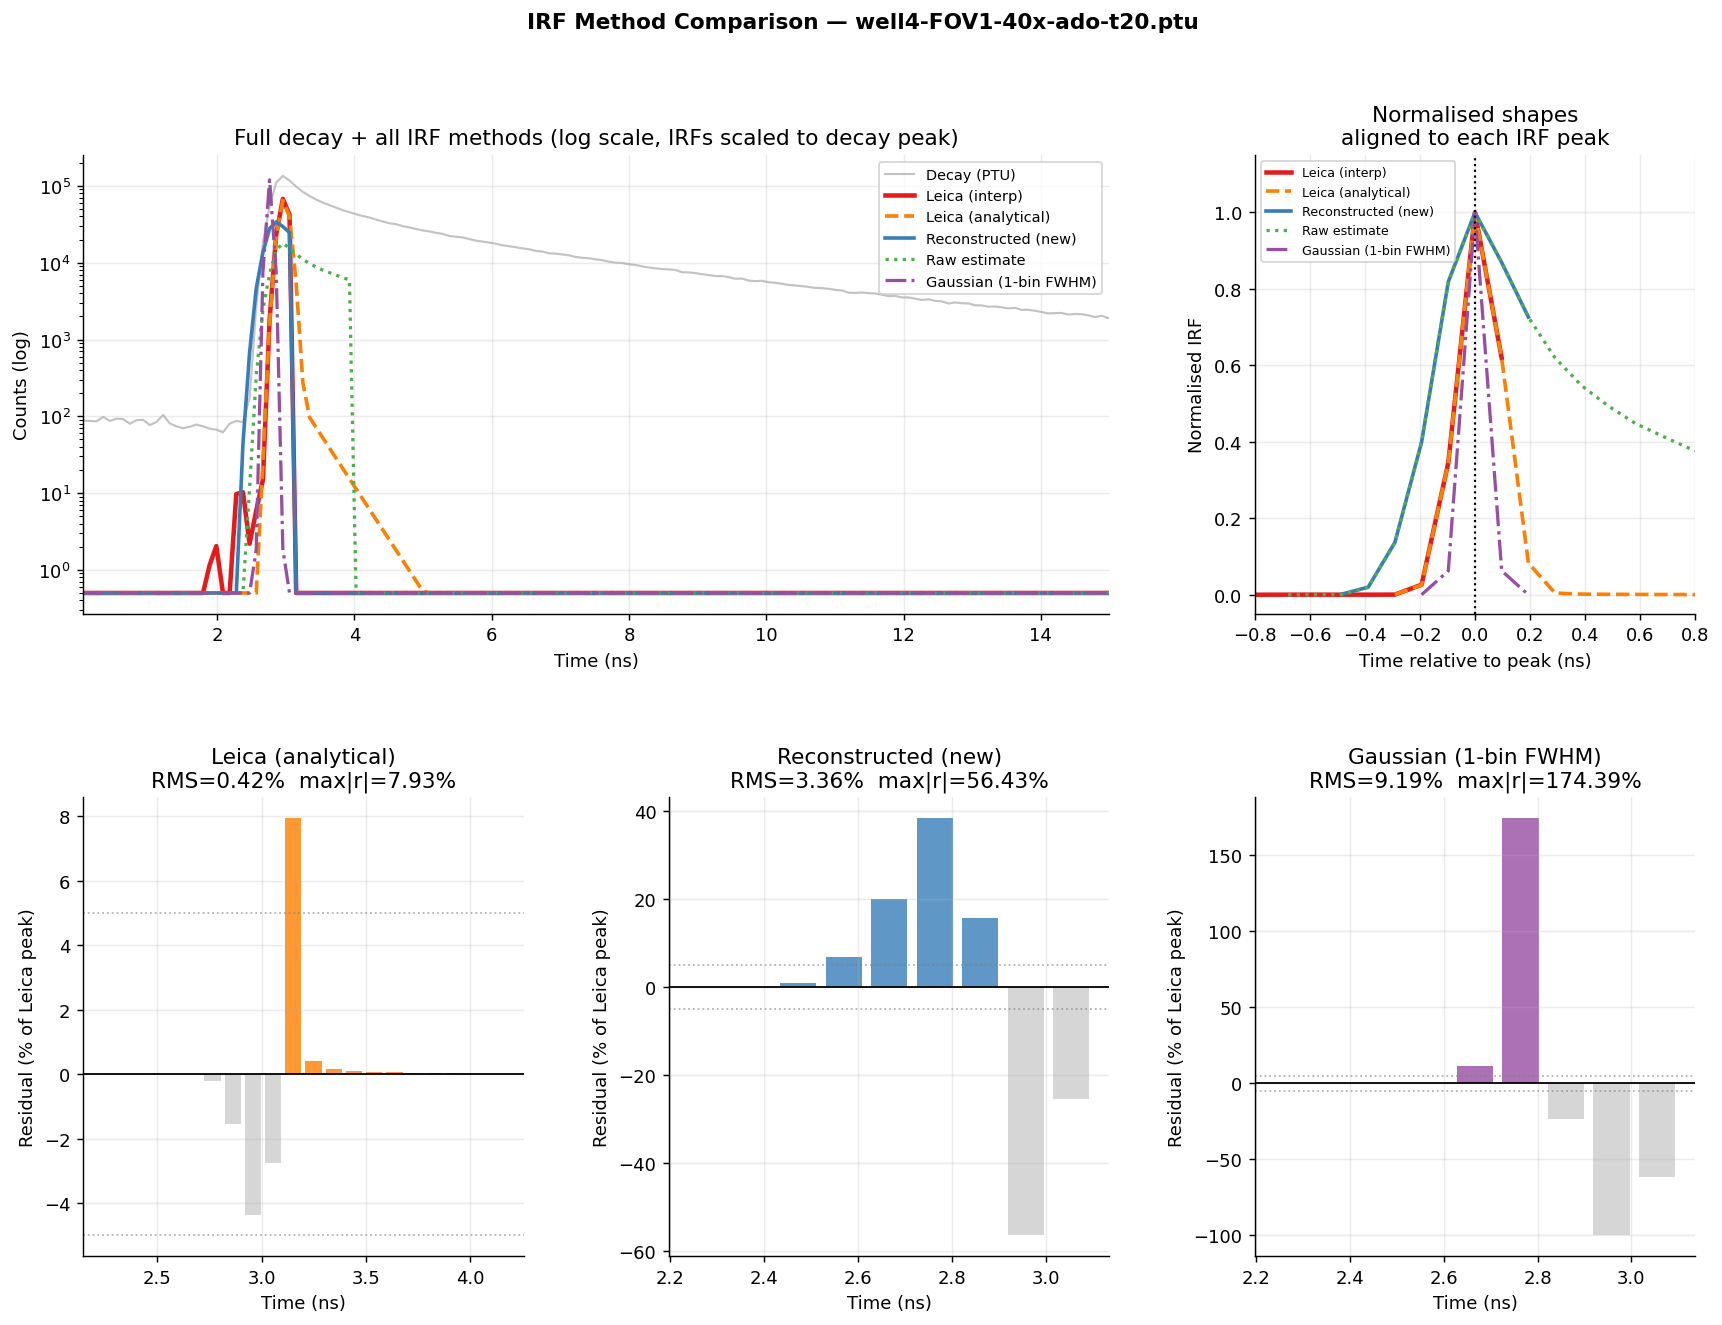

Saved: irf_method_comparison.png


In [9]:
# ── Visualisation ─────────────────────────────────────────────────────────────
colors = {
    'Leica (interp)':       '#e41a1c',
    'Leica (analytical)':   '#ff7f00',
    'Reconstructed (new)':  '#377eb8',
    'Raw estimate':         '#4daf4a',
    'Gaussian (1-bin FWHM)':'#984ea3',
}
styles = {
    'Leica (interp)':       ('-',  2.5),
    'Leica (analytical)':   ('--', 2.0),
    'Reconstructed (new)':  ('-',  2.0),
    'Raw estimate':         (':',  1.8),
    'Gaussian (1-bin FWHM)':('-.', 1.8),
}

fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 3, hspace=0.40, wspace=0.33)

# ── Panel A: Full decay + all IRFs, log scale ─────────────────────────────────
ax_a = fig.add_subplot(gs[0, :2])
ax_a.semilogy(t_ns, np.maximum(decay, 0.5), color='#aaaaaa',
              lw=1.2, alpha=0.7, label='Decay (PTU)', zorder=0)
for label, irf in irfs.items():
    col = colors.get(label, 'k')
    ls, lw = styles.get(label, ('-', 1.5))
    scale  = decay.max()
    ax_a.semilogy(t_ns, np.maximum(irf * scale, 0.5),
                  ls=ls, lw=lw, color=col, label=label)
ax_a.set_xlim(t_ns[0], min(t_ns[-1], 15))
ax_a.set_xlabel('Time (ns)'); ax_a.set_ylabel('Counts (log)')
ax_a.set_title('Full decay + all IRF methods (log scale, IRFs scaled to decay peak)')
ax_a.legend(fontsize=8, loc='upper right'); ax_a.grid(True, alpha=0.25)

# ── Panel B: Normalised, aligned to peak ──────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 2])
for label, irf in irfs.items():
    col = colors.get(label, 'k')
    ls, lw = styles.get(label, ('-', 1.5))
    pi  = np.argmax(irf)
    t_rel = t_ns - t_ns[pi]
    nz    = irf > 1e-6
    ax_b.plot(t_rel[nz], irf[nz] / irf[pi],
              ls=ls, lw=lw, color=col, label=label)
ax_b.axvline(0, color='k', ls=':', lw=1.2)
ax_b.set_xlim(-0.8, 0.8); ax_b.set_ylim(-0.05, 1.15)
ax_b.set_xlabel('Time relative to peak (ns)'); ax_b.set_ylabel('Normalised IRF')
ax_b.set_title('Normalised shapes\naligned to each IRF peak')
ax_b.legend(fontsize=7); ax_b.grid(True, alpha=0.25)

# ── Panels C–E: Residuals vs Leica (interp) ───────────────────────────────────
ref_irf = irfs.get('Leica (interp)')
compare_labels = ['Leica (analytical)', 'Reconstructed (new)', 'Gaussian (1-bin FWHM)']
panel_positions = [gs[1, 0], gs[1, 1], gs[1, 2]]

for ax_pos, label in zip(panel_positions, compare_labels):
    ax = fig.add_subplot(ax_pos)
    if ref_irf is None or label not in irfs:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(label); continue

    irf = irfs[label]
    residuals = (irf - ref_irf) / (ref_irf.max() + 1e-12) * 100
    rms = np.sqrt(np.mean(residuals**2))
    max_r = np.max(np.abs(residuals))

    sig_mask = (ref_irf > ref_irf.max() * 1e-4) | (irf > irf.max() * 1e-4)
    t_sig = t_ns[sig_mask]
    r_sig = residuals[sig_mask]

    col = colors.get(label, 'k')
    ax.bar(t_sig, r_sig, width=BW * 0.8,
           color=[col if r >= 0 else '#cccccc' for r in r_sig], alpha=0.8)
    ax.axhline(0,  color='k', lw=1)
    ax.axhline( 5, color='gray', ls=':', lw=1, alpha=0.6)
    ax.axhline(-5, color='gray', ls=':', lw=1, alpha=0.6)
    ax.set_xlabel('Time (ns)'); ax.set_ylabel('Residual (% of Leica peak)')
    ax.set_title(f'{label}\nRMS={rms:.2f}%  max|r|={max_r:.2f}%')
    ax.grid(True, alpha=0.25)

fig.suptitle(f'IRF Method Comparison — {PTU_FILE.name}',
             fontsize=12, fontweight='bold')
plt.savefig('irf_method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: irf_method_comparison.png")


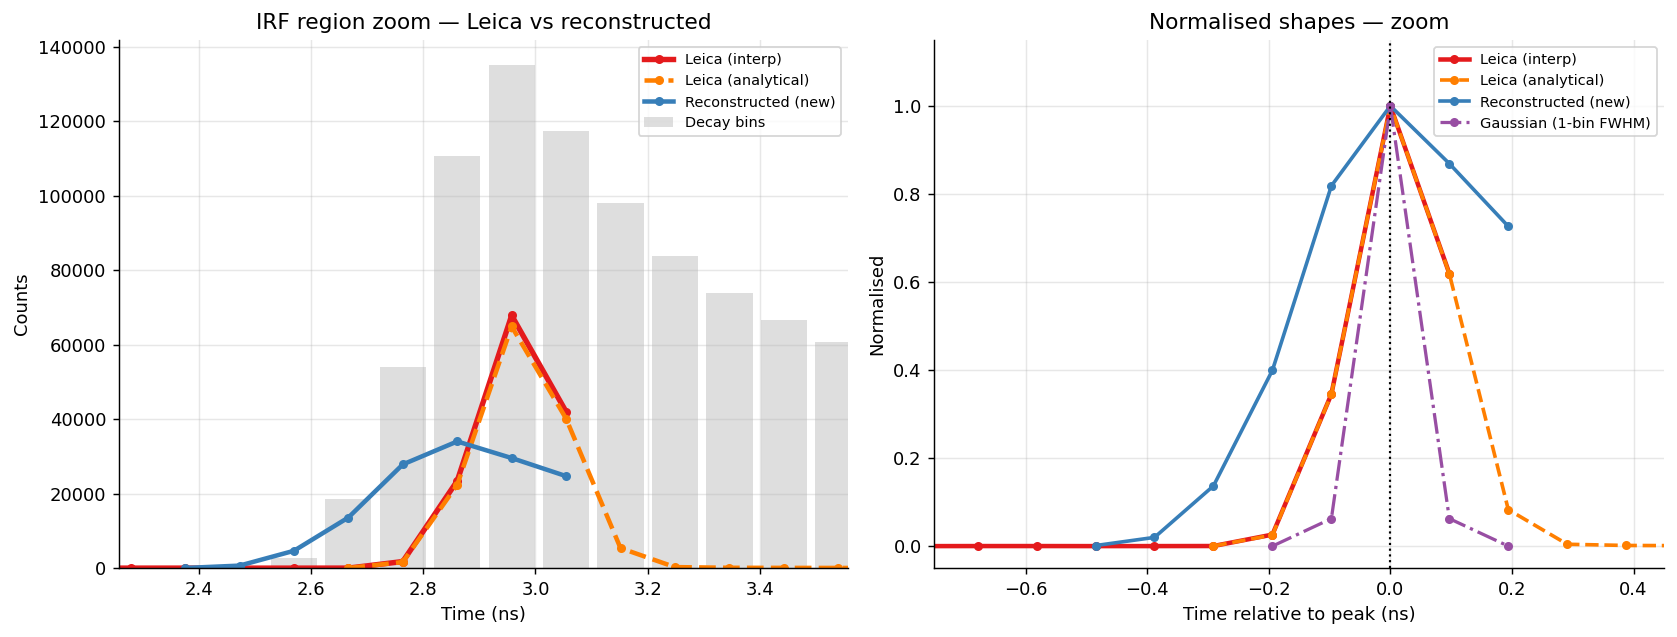

In [10]:
# ── Zoom on IRF region — absolute time axis ───────────────────────────────────
ref_irf = irfs.get('Leica (interp)', list(irfs.values())[0])
pi_ref  = np.argmax(ref_irf)
t_lo    = t_ns[pi_ref] - 0.7
t_hi    = t_ns[pi_ref] + 0.6

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
mask_d = (t_ns >= t_lo) & (t_ns <= t_hi)
ax.bar(t_ns[mask_d], decay[mask_d], width=BW * 0.85,
       color='#d0d0d0', alpha=0.7, label='Decay bins', align='center')
for label in ['Leica (interp)', 'Leica (analytical)', 'Reconstructed (new)']:
    if label not in irfs: continue
    irf = irfs[label]
    col = colors[label]; ls, lw = styles[label]
    nz  = irf > 1e-6
    ax.plot(t_ns[nz], irf[nz] * decay.max(),
            ls=ls, lw=lw+0.5, color=col, marker='o', ms=4, label=label)
ax.set_xlim(t_lo, t_hi)
ax.set_xlabel('Time (ns)'); ax.set_ylabel('Counts')
ax.set_title('IRF region zoom — Leica vs reconstructed')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax2 = axes[1]
for label in ['Leica (interp)', 'Leica (analytical)', 'Reconstructed (new)', 'Gaussian (1-bin FWHM)']:
    if label not in irfs: continue
    irf = irfs[label]; pi = np.argmax(irf)
    col = colors[label]; ls, lw = styles[label]
    t_rel = t_ns - t_ns[pi]
    nz = irf > 1e-6
    ax2.plot(t_rel[nz], irf[nz] / irf[pi],
             ls=ls, lw=lw, color=col, marker='o', ms=4, label=label)
ax2.axvline(0, color='k', ls=':', lw=1.2)
ax2.set_xlim(-0.75, 0.45); ax2.set_ylim(-0.05, 1.15)
ax2.set_xlabel('Time relative to peak (ns)'); ax2.set_ylabel('Normalised')
ax2.set_title('Normalised shapes — zoom')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('irf_zoom.png', dpi=150, bbox_inches='tight')
plt.show()


## Interpretation guide

### χ²_r is the ground truth
| χ²_r | Assessment |
|---|---|
| ≈ 1.0 | Correct IRF — use this method |
| 1–2 | Acceptable for most analyses |
| 2–5 | Shape mismatch — check IRF FWHM and BaP |
| 10–50 | Wrong IRF (e.g. Gaussian 1-bin FWHM is 2–3× too narrow) |

### Residual RMS (visual comparison only)
| RMS | Assessment |
|---|---|
| < 2% | Excellent — methods are essentially equivalent |
| 2–5% | Minor shape differences, check χ²_r |
| > 15% | Rising edge detection may have failed |

### Next step: integration
If `Reconstructed (new)` gives χ²_r comparable to `Leica (analytical)`:
- The `reconstruct_irf_from_decay()` function in `flimkit.FLIM.irf_tools` is validated
- Wire it into `fit_cli.py` as `--estimate-irf leica`
- No xlsx export needed per tile — IRF comes from the PTU decay itself

### Why truncated > full Gaussian
The truncated IRF (rising edge + 1–2 bins after peak) is physically correct
because only the rising edge is clean instrument response. Post-peak bins
contain mixed IRF + fluorescence — including them double-counts that signal.


In [11]:
# ── Diagnostic dump — IRF shapes and fit results ──────────────────────────────
print("=== IRF shape summary ===")
for label, irf in irfs.items():
    pi = np.argmax(irf)
    nz = np.where(irf > 0)[0]
    bap = nz[-1] - pi if len(nz) else 0
    above = np.where(irf >= irf.max() / 2)[0]
    fwhm = (above[-1] - above[0]) * tcspc_res * 1e9 if len(above) > 1 else 0
    print(f"  {label:<26}  peak_bin={pi:>3}  BaP={bap:>3}  "
          f"n_nonzero={len(nz):>3}  FWHM={fwhm:.4f} ns  max={irf.max():.6f}")

# Leica vs Reconstructed: bin-by-bin on nonzero region
if 'Leica (interp)' in irfs and 'Reconstructed (new)' in irfs:
    leica = irfs['Leica (interp)']
    recon = irfs['Reconstructed (new)']
    nz_l = np.where(leica > 0)[0]
    nz_r = np.where(recon > 0)[0]
    print(f"\n=== Leica (interp) nonzero bins: {nz_l} ===")
    print(f"=== Reconstructed   nonzero bins: {nz_r} ===")
    print(f"\nBin-by-bin (Leica vs Reconstructed):")
    all_nz = np.union1d(nz_l, nz_r)
    for b in all_nz:
        print(f"  bin {b:>3}: Leica={leica[b]:.6f}  Recon={recon[b]:.6f}  "
              f"ratio={recon[b]/leica[b]:.3f}" if leica[b] > 0 else
              f"  bin {b:>3}: Leica={leica[b]:.6f}  Recon={recon[b]:.6f}")

if fit_results:
    print(f"\n=== Fit results (χ²_r) ===")
    for label, s in fit_results.items():
        print(f"  {label:<26}  χ²_r={s['reduced_chi2']:.3f}  "
              f"χ²_r(tail)={s['reduced_chi2_tail']:.3f}  "
              f"τ_amp={s['tau_mean_amp_ns']:.3f} ns  "
              f"τ_int={s['tau_mean_int_ns']:.3f} ns")


=== IRF shape summary ===
  Leica (interp)              peak_bin= 30  BaP=  2  n_nonzero= 17  FWHM=0.0970 ns  max=0.502175
  Leica (analytical)          peak_bin= 30  BaP=501  n_nonzero=532  FWHM=0.0970 ns  max=0.480303
  Reconstructed (new)         peak_bin= 29  BaP=  2  n_nonzero=  8  FWHM=0.2909 ns  max=0.251825
  Raw estimate                peak_bin= 30  BaP= 10  n_nonzero= 17  FWHM=0.4848 ns  max=0.132119
  Gaussian (1-bin FWHM)       peak_bin= 28  BaP= 16  n_nonzero= 33  FWHM=0.0000 ns  max=0.888865

=== Leica (interp) nonzero bins: [16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32] ===
=== Reconstructed   nonzero bins: [24 25 26 27 28 29 30 31] ===

Bin-by-bin (Leica vs Reconstructed):
  bin  16: Leica=0.000000  Recon=0.000000  ratio=0.000
  bin  17: Leica=0.000000  Recon=0.000000  ratio=0.000
  bin  18: Leica=0.000002  Recon=0.000000  ratio=0.000
  bin  19: Leica=0.000009  Recon=0.000000  ratio=0.000
  bin  20: Leica=0.000015  Recon=0.000000  ratio=0.000
  bin  21: Leica=0.00

In [12]:
# ── Fit χ²_r results ──────────────────────────────────────────────────────────
print(f"fit_results type: {type(fit_results)}, len: {len(fit_results)}")
print(f"fit_results keys: {list(fit_results.keys())}")
if fit_results:
    print(f"\n{'Method':<26} {'χ²_r':>8} {'χ²_r(tail)':>12} {'τ_amp(ns)':>10} {'τ_int(ns)':>10}")
    print("─" * 70)
    for label, s in fit_results.items():
        print(f"{label:<26} {s['reduced_chi2']:>8.3f} {s['reduced_chi2_tail']:>12.3f} "
              f"{s['tau_mean_amp_ns']:>10.3f} {s['tau_mean_int_ns']:>10.3f}")
else:
    print("fit_results is empty — the fitting cell may have failed silently")
    print("Check the output of cell 10 for errors")


fit_results type: <class 'dict'>, len: 5
fit_results keys: ['Leica (interp)', 'Leica (analytical)', 'Reconstructed (new)', 'Raw estimate', 'Gaussian (1-bin FWHM)']

Method                         χ²_r   χ²_r(tail)  τ_amp(ns)  τ_int(ns)
──────────────────────────────────────────────────────────────────────
Leica (interp)                6.965        5.342      0.961      1.887
Leica (analytical)           11.121        1.608      1.331      3.232
Reconstructed (new)          93.057       41.150      1.087      2.787
Raw estimate                332.235       37.302      0.222      1.593
Gaussian (1-bin FWHM)        61.160        3.809      1.063      1.575


In [14]:
# ── Experiment: sweep max_bap to find optimal truncation ──────────────────────
from flimkit.FLIM.irf_tools import reconstruct_irf_from_decay

ref_chi2 = fit_results['Leica (interp)']['reduced_chi2']
print(f"Reference: Leica (interp) χ²_r = {ref_chi2:.3f}\n")
print(f"{'max_bap':>8} {'χ²_r':>10} {'τ_amp(ns)':>10} {'FWHM(ns)':>10} {'n_nz':>6}")
print("─" * 50)

for bap_test in [0, 1, 2, 3, 4]:
    irf_test = reconstruct_irf_from_decay(decay, tcspc_res, n_bins,
                                           max_bap=bap_test, verbose=False)
    try:
        popt_t, sum_t = fit_summed(
            decay, tcspc_res, n_bins, irf_test,
            False, True, False,  # no tail, yes bg, no sigma
            N_EXP, Tau_min, Tau_max,
            optimizer='de', de_popsize=30, de_maxiter=5000,
            workers=-1, polish=True, cost_function='poisson',
        )
        nz = (irf_test > 0).sum()
        fwhm = nz * tcspc_res * 1e9
        print(f"{bap_test:>8} {sum_t['reduced_chi2']:>10.3f} {sum_t['tau_mean_amp_ns']:>10.3f} "
              f"{fwhm:>10.3f} {nz:>6}")
    except Exception as e:
        print(f"{bap_test:>8}   FAILED: {e}")

Reference: Leica (interp) χ²_r = 6.965

 max_bap       χ²_r  τ_amp(ns)   FWHM(ns)   n_nz
──────────────────────────────────────────────────
  Next-period artefact at bin 483 (46.84 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 84.000 cts/bin, upper bound = 168.000 (free param)
  σ broadening: fixed at 0
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=30, maxiter=5000, workers=-1
  Running final LM polish...
       0      7.343      1.272      0.582      6
  Next-period artefact at bin 483 (46.84 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 84.000 cts/bin, upper bound = 168.000 (free param)
  σ broadening: fixed at 0
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=30, maxiter=5000, workers=-1
  Running final LM polish...
       1     24.514      1.120      0.679      7
  Next-period artefact at bin 483 (46.84 ns). Truncating fit window.
  Cost function: pois

In [17]:
# ── Test: delta-function IRF + fit_sigma vs Leica ────────────────────────────
import numpy as np

# Build a delta IRF at the decay peak position
peak_bin = int(np.argmax(decay))
delta_irf = np.zeros(n_bins)
delta_irf[peak_bin] = 1.0

# Fit with sigma free (fitter broadens delta → effective IRF)
print("Delta IRF + fit_sigma=True ...")
popt_d, sum_d = fit_summed(
    decay, tcspc_res, n_bins, delta_irf,
    True, True, True,   # tail, bg, sigma all free
    N_EXP, Tau_min, Tau_max,
    optimizer='de', de_popsize=30, de_maxiter=5000,
    workers=-1, polish=True, cost_function='poisson',
)
print(f"\nDelta + σ:        χ²_r = {sum_d['reduced_chi2']:.3f},  τ_amp = {sum_d['tau_mean_amp_ns']:.3f} ns")
print(f"Leica (interp):   χ²_r = {fit_results['Leica (interp)']['reduced_chi2']:.3f},  "
      f"τ_amp = {fit_results['Leica (interp)']['tau_mean_amp_ns']:.3f} ns")
print(f"Reconstructed:    χ²_r = {fit_results['Reconstructed (new)']['reduced_chi2']:.3f},  "
      f"τ_amp = {fit_results['Reconstructed (new)']['tau_mean_amp_ns']:.3f} ns")

Delta IRF + fit_sigma=True ...
  Next-period artefact at bin 483 (46.84 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 84.000 cts/bin, upper bound = 168.000 (free param)
  σ broadening: free param
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=30, maxiter=5000, workers=-1
  Running final LM polish...

Delta + σ:        χ²_r = 3.068,  τ_amp = 0.900 ns
Leica (interp):   χ²_r = 6.965,  τ_amp = 0.961 ns
Reconstructed:    χ²_r = 93.057,  τ_amp = 1.087 ns


## Multi-file validation: Delta+σ vs Leica (interp) vs Leica (analytical)

Compare χ²_r across 11 PTU/XLSX pairs from `/Volumes/Lexar/To_test/PTU.sptw/`.
Each file is fit with 3-exp reconvolution using three IRF strategies:
1. **Delta + σ** — delta at decay peak, fitter finds σ broadening (no external files needed)
2. **Leica (interp)** — sparse xlsx IRF interpolated onto TCSPC grid
3. **Leica (analytical)** — Gaussian+exp-tail fit to xlsx points

In [19]:
# ── Parse LAS X _fit.xlsx ground truth ─────────────────────────────────────────
import openpyxl

def parse_lasx_fit(xlsx_path):
    """Extract LAS X fit results from _fit.xlsx."""
    wb = openpyxl.load_workbook(xlsx_path, data_only=True)
    ws = wb['FLIM']
    data = {}
    for row in ws.iter_rows(min_row=1, max_row=ws.max_row, values_only=False):
        key = row[0].value
        val = row[1].value
        if key and val is not None:
            data[key] = val
    wb.close()
    return dict(
        taus_ns    = [data.get('Lifetime (τ) 1 [ns]', 0),
                      data.get('Lifetime (τ) 2 [ns]', 0),
                      data.get('Lifetime (τ) 3 [ns]', 0)],
        amps_kcts  = [data.get('Amplitude 1 [kCnts]', 0),
                      data.get('Amplitude 2 [kCnts]', 0),
                      data.get('Amplitude 3 [kCnts]', 0)],
        tau_amp_ns = data.get('Mean τ, Amplitude Weighted [ns]', np.nan),
        tau_int_ns = data.get('Mean τ, Intensity Weighted  [ns]', np.nan),
        chi2       = data.get('χ²', np.nan),
        bg_cts     = data.get('Tail Offset [Cnts]', 0),
    )

# Quick test
gt = parse_lasx_fit("/Volumes/Lexar/To_test/PTU.sptw/Ado_1_fit.xlsx")
print(f"Ado_1 LAS X: χ²={gt['chi2']:.3f}, τ_amp={gt['tau_amp_ns']:.3f} ns, "
      f"τs={[f'{t:.3f}' for t in gt['taus_ns']]}")
print("Parser OK ✓")

Ado_1 LAS X: χ²=2.993, τ_amp=1.146 ns, τs=['0.375', '1.886', '5.686']
Parser OK ✓


In [20]:
# ── Multi-file validation loop ─────────────────────────────────────────────────
from flimkit.PTU.reader import PTUFile
from flimkit.utils.xlsx_tools import load_xlsx
from flimkit.FLIM.irf_tools import irf_from_xlsx, irf_from_xlsx_analytical
from flimkit.FLIM.fitters import fit_summed
from flimkit.configs import Tau_min, Tau_max
import time

DATA_DIR = Path("/Volumes/Lexar/To_test/PTU.sptw/")
N_EXP = 3

# Find all PTU/XLSX pairs
pairs = []
for ptu_path in sorted(DATA_DIR.glob("*.ptu")):
    name = ptu_path.stem
    xlsx_path = DATA_DIR / f"{name}.xlsx"
    fit_path  = DATA_DIR / f"{name}_fit.xlsx"
    if xlsx_path.exists() and fit_path.exists():
        pairs.append((name, ptu_path, xlsx_path, fit_path))

print(f"Found {len(pairs)} PTU/XLSX/fit triplets\n")

results = []
for i, (name, ptu_path, xlsx_path, fit_path) in enumerate(pairs):
    print(f"[{i+1}/{len(pairs)}] {name}")
    t0 = time.time()

    # Load data
    ptu_f = PTUFile(str(ptu_path), verbose=False)
    dec   = ptu_f.summed_decay()
    tres  = ptu_f.tcspc_res
    nbins = ptu_f.n_bins
    xlsx_data = load_xlsx(str(xlsx_path))
    lasx  = parse_lasx_fit(str(fit_path))

    row = dict(name=name, lasx_chi2=lasx['chi2'],
               lasx_tau_amp=lasx['tau_amp_ns'], lasx_tau_int=lasx['tau_int_ns'])

    # ── Method 1: Delta + σ (no external files) ──────────────────────────────
    peak = int(np.argmax(dec))
    d_irf = np.zeros(nbins)
    d_irf[peak] = 1.0
    try:
        _, s = fit_summed(dec, tres, nbins, d_irf,
                          True, True, True,  # tail, bg, sigma
                          N_EXP, Tau_min, Tau_max,
                          optimizer='de', de_popsize=30, de_maxiter=5000,
                          workers=-1, polish=True, cost_function='poisson')
        row['delta_chi2']    = s['reduced_chi2']
        row['delta_tau_amp'] = s['tau_mean_amp_ns']
        row['delta_tau_int'] = s['tau_mean_int_ns']
        row['delta_sigma']   = s['irf_sigma_bins']
    except Exception as e:
        row['delta_chi2'] = row['delta_tau_amp'] = row['delta_tau_int'] = np.nan
        row['delta_sigma'] = np.nan
        print(f"  Delta+σ FAILED: {e}")

    # ── Method 2: Leica (interp) ─────────────────────────────────────────────
    try:
        irf_li = irf_from_xlsx(xlsx_data, nbins, tres)
        _, s = fit_summed(dec, tres, nbins, irf_li,
                          True, True, True,
                          N_EXP, Tau_min, Tau_max,
                          optimizer='de', de_popsize=30, de_maxiter=5000,
                          workers=-1, polish=True, cost_function='poisson')
        row['leica_i_chi2']    = s['reduced_chi2']
        row['leica_i_tau_amp'] = s['tau_mean_amp_ns']
        row['leica_i_tau_int'] = s['tau_mean_int_ns']
    except Exception as e:
        row['leica_i_chi2'] = row['leica_i_tau_amp'] = row['leica_i_tau_int'] = np.nan
        print(f"  Leica(interp) FAILED: {e}")

    # ── Method 3: Leica (analytical) ─────────────────────────────────────────
    try:
        irf_la, _ = irf_from_xlsx_analytical(xlsx_data, nbins, tres, verbose=False)
        _, s = fit_summed(dec, tres, nbins, irf_la,
                          False, True, False,
                          N_EXP, Tau_min, Tau_max,
                          optimizer='de', de_popsize=30, de_maxiter=5000,
                          workers=-1, polish=True, cost_function='poisson')
        row['leica_a_chi2']    = s['reduced_chi2']
        row['leica_a_tau_amp'] = s['tau_mean_amp_ns']
        row['leica_a_tau_int'] = s['tau_mean_int_ns']
    except Exception as e:
        row['leica_a_chi2'] = row['leica_a_tau_amp'] = row['leica_a_tau_int'] = np.nan
        print(f"  Leica(analytical) FAILED: {e}")

    dt = time.time() - t0
    print(f"  LAS X χ²={row['lasx_chi2']:.2f}  |  "
          f"Δ+σ={row.get('delta_chi2', np.nan):.2f}  "
          f"Li={row.get('leica_i_chi2', np.nan):.2f}  "
          f"La={row.get('leica_a_chi2', np.nan):.2f}  "
          f"({dt:.1f}s)")
    results.append(row)

print("\n✓ All files processed.")

Found 11 PTU/XLSX/fit triplets

[1/11] Ado_1
    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 14 pts
    irf_c       : 14 pts
    fit_t       : 520 pts
    fit_c       : absent
    res_t       : 520 pts
    res_c       : absent
  Next-period artefact at bin 484 (46.93 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 61.500 cts/bin, upper bound = 123.000 (free param)
  σ broadening: free param
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=30, maxiter=5000, workers=-1
  Running final LM polish...
  Next-period artefact at bin 484 (46.93 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 61.500 cts/bin, upper bound = 123.000 (free param)
  σ broadening: free param
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=30, maxiter=5000, workers=-1
  Running final LM polish...
  Next-period artefact at bin 484 (46.93 ns). Truncating fit window.
  Cost fun

In [21]:
# ── Summary table ─────────────────────────────────────────────────────────────
import pandas as pd

df = pd.DataFrame(results)

# Display table
print(f"\n{'':─<100}")
print(f"{'Sample':<22} {'LAS X':>7} {'Δ+σ':>7} {'Li':>7} {'La':>7}  │ "
      f"{'τ_amp LAS X':>10} {'τ_amp Δ+σ':>10} {'τ_amp Li':>10} {'τ_amp La':>10}")
print(f"{'':─<100}")
for _, r in df.iterrows():
    print(f"{r['name']:<22} {r['lasx_chi2']:>7.2f} {r.get('delta_chi2', np.nan):>7.2f} "
          f"{r.get('leica_i_chi2', np.nan):>7.2f} {r.get('leica_a_chi2', np.nan):>7.2f}  │ "
          f"{r['lasx_tau_amp']:>10.3f} {r.get('delta_tau_amp', np.nan):>10.3f} "
          f"{r.get('leica_i_tau_amp', np.nan):>10.3f} {r.get('leica_a_tau_amp', np.nan):>10.3f}")
print(f"{'':─<100}")

# Means
print(f"\n{'Mean χ²_r':}")
for col, label in [('lasx_chi2','LAS X'), ('delta_chi2','Delta+σ'),
                    ('leica_i_chi2','Leica(i)'), ('leica_a_chi2','Leica(a)')]:
    vals = df[col].dropna()
    print(f"  {label:<16} {vals.mean():.3f} ± {vals.std():.3f}  (median {vals.median():.3f})")

# Sigma stats
if 'delta_sigma' in df.columns:
    sig = df['delta_sigma'].dropna()
    print(f"\nFitted σ (bins):  mean={sig.mean():.3f}, std={sig.std():.3f}, "
          f"range=[{sig.min():.3f}, {sig.max():.3f}]")
    print(f"Fitted σ (ns):    mean={sig.mean()*df.iloc[0].get('delta_tau_amp', 1)*1e-9:.4f}")

# τ_amp agreement
print(f"\n|τ_amp(Delta+σ) − τ_amp(LAS X)| (ns):")
diff = (df['delta_tau_amp'] - df['lasx_tau_amp']).abs()
print(f"  mean={diff.mean():.3f}, max={diff.max():.3f}")


────────────────────────────────────────────────────────────────────────────────────────────────────
Sample                   LAS X     Δ+σ      Li      La  │ τ_amp LAS X  τ_amp Δ+σ   τ_amp Li   τ_amp La
────────────────────────────────────────────────────────────────────────────────────────────────────
Ado_1                     2.99   14.25    3.48    6.27  │      1.146      0.747      0.797      1.123
Ctrl_1                    3.48    4.66    1.78    9.96  │      1.234      0.731      0.876      1.265
Dara_Ima_2                3.64   14.16    4.67    4.00  │      1.093      0.722      0.784      0.957
Dara_Ima_Ado_2            3.83    4.79    5.02    4.99  │      1.106      0.697      0.799      0.973
Daratumab_1               4.31    5.33    3.56    5.52  │      1.117      0.725      0.816      0.984
Daratumab_Ado_1           4.38    4.77    3.96    4.92  │      1.110      0.715      0.802      0.969
Daratumab_Ado_2           5.57    5.47    4.97    8.33  │      1.145      0.743   

In [22]:
# ── Compact summary ───────────────────────────────────────────────────────────
for col, label in [('lasx_chi2','LAS X'), ('delta_chi2','Delta+σ'),
                    ('leica_i_chi2','Leica(i)'), ('leica_a_chi2','Leica(a)')]:
    vals = df[col].dropna()
    print(f"{label:<12} χ²_r: mean={vals.mean():.2f} ± {vals.std():.2f}, median={vals.median():.2f}")
print()
diff_d = (df['delta_tau_amp'] - df['lasx_tau_amp']).abs()
diff_i = (df['leica_i_tau_amp'] - df['lasx_tau_amp']).abs()
print(f"|Δτ_amp| vs LAS X:  Delta+σ mean={diff_d.mean():.3f}ns,  Leica(i) mean={diff_i.mean():.3f}ns")
print(f"\nBest χ²_r per file:")
for _, r in df.iterrows():
    best = min(r['delta_chi2'], r['leica_i_chi2'], r['leica_a_chi2'])
    winner = {r['delta_chi2']: 'Δ+σ', r['leica_i_chi2']: 'Li', r['leica_a_chi2']: 'La'}[best]
    print(f"  {r['name']:<22} {winner} ({best:.2f}) vs LAS X ({r['lasx_chi2']:.2f})")

LAS X        χ²_r: mean=3.97 ± 0.68, median=3.83
Delta+σ      χ²_r: mean=9.55 ± 4.68, median=8.41
Leica(i)     χ²_r: mean=4.22 ± 1.03, median=4.67
Leica(a)     χ²_r: mean=6.29 ± 2.67, median=4.99

|Δτ_amp| vs LAS X:  Delta+σ mean=0.420ns,  Leica(i) mean=0.341ns

Best χ²_r per file:
  Ado_1                  Li (3.48) vs LAS X (2.99)
  Ctrl_1                 Li (1.78) vs LAS X (3.48)
  Dara_Ima_2             La (4.00) vs LAS X (3.64)
  Dara_Ima_Ado_2         Δ+σ (4.79) vs LAS X (3.83)
  Daratumab_1            Li (3.56) vs LAS X (4.31)
  Daratumab_Ado_1        Li (3.96) vs LAS X (4.38)
  Daratumab_Ado_2        Li (4.97) vs LAS X (5.57)
  Etrumadenant_1         Li (3.82) vs LAS X (4.30)
  Imaradenant_2          La (3.65) vs LAS X (3.69)
  Imaradenant_Ado_2      La (4.83) vs LAS X (3.93)
  PSB12379_1             La (4.72) vs LAS X (3.51)


## Strategy: Two-pass iterative IRF from PTU only

The delta+σ approach has the right model (Gaussian+tail) but 12-parameter DE optimisation
is inconsistent across files. Fix: two-pass approach.

1. **Pass 1** — Quick delta+σ fit (reduced popsize/maxiter) → discovers approximate IRF shape
2. **Build** the effective IRF via `build_full_irf(delta, shift, σ, tail_amp, tail_τ, n_bins)`
3. **Pass 2** — Re-fit with the constructed IRF held fixed → only 8 free params (3τ + 3α + shift + bg)

This gives us a **plottable IRF array** derived purely from the PTU decay.

In [23]:
# ── Two-pass IRF estimation: prototype on single file ─────────────────────────
from flimkit.FLIM.irf_tools import build_full_irf

def estimate_irf_two_pass(dec, tres, nbins, n_exp, tau_min, tau_max,
                          de_popsize=30, de_maxiter=3000, verbose=False):
    """
    Two-pass IRF estimation from PTU decay data only.
    
    Pass 1: delta+σ fit discovers approximate IRF shape.
    Pass 2: re-fit with constructed IRF held fixed.
    
    Returns (irf_array, pass2_summary, pass1_summary).
    """
    # Delta IRF at steepest rise
    peak = int(np.argmax(dec))
    d_irf = np.zeros(nbins)
    d_irf[peak] = 1.0
    
    # Pass 1: discover IRF shape (σ, shift, tail)
    if verbose:
        print("  Pass 1: delta+σ → discover IRF shape...")
    _, s1 = fit_summed(dec, tres, nbins, d_irf,
                       True, True, True,  # tail, bg, sigma
                       n_exp, tau_min, tau_max,
                       optimizer='de', de_popsize=de_popsize,
                       de_maxiter=de_maxiter,
                       workers=-1, polish=True, cost_function='poisson')
    
    shift = s1['irf_shift_bins']
    sigma = s1['irf_sigma_bins']
    tail_a = s1['tail_amp']
    tail_t = s1['tail_tau_ns'] / (tres * 1e9)  # convert ns back to bins
    
    if verbose:
        print(f"    shift={shift:.3f} bins, σ={sigma:.3f} bins, "
              f"tail_amp={tail_a:.4f}, tail_τ={s1['tail_tau_ns']:.2f} ns")
        print(f"    Pass 1 χ²_r = {s1['reduced_chi2']:.3f}")
    
    # Build the effective IRF
    irf_eff = build_full_irf(d_irf, shift, sigma, tail_a, tail_t, nbins)
    
    # Pass 2: re-fit with constructed IRF held fixed
    if verbose:
        print("  Pass 2: re-fit with constructed IRF (fixed shape)...")
    _, s2 = fit_summed(dec, tres, nbins, irf_eff,
                       False, True, False,  # no tail, bg, no sigma
                       n_exp, tau_min, tau_max,
                       optimizer='de', de_popsize=de_popsize,
                       de_maxiter=de_maxiter,
                       workers=-1, polish=True, cost_function='poisson')
    
    if verbose:
        print(f"    Pass 2 χ²_r = {s2['reduced_chi2']:.3f}, "
              f"τ_amp = {s2['tau_mean_amp_ns']:.3f} ns")
    
    return irf_eff, s2, s1

# Test on first loaded PTU (from single-file cells above)
print(f"Testing two-pass on {PTU_FILE.name}...")
irf_2pass, sum_2pass, sum_p1 = estimate_irf_two_pass(
    decay, tcspc_res, n_bins, N_EXP, Tau_min, Tau_max, verbose=True)

print(f"\nComparison:")
print(f"  LAS X (this file N/A — different source)")
print(f"  Two-pass:       χ²_r = {sum_2pass['reduced_chi2']:.3f}, τ_amp = {sum_2pass['tau_mean_amp_ns']:.3f} ns")
print(f"  Delta+σ (prev): χ²_r = {sum_d['reduced_chi2']:.3f}, τ_amp = {sum_d['tau_mean_amp_ns']:.3f} ns")
print(f"  Leica(interp):  χ²_r = {fit_results['Leica (interp)']['reduced_chi2']:.3f}, "
      f"τ_amp = {fit_results['Leica (interp)']['tau_mean_amp_ns']:.3f} ns")

Testing two-pass on well4-FOV1-40x-ado-t20.ptu...
  Pass 1: delta+σ → discover IRF shape...
  Next-period artefact at bin 483 (46.84 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 84.000 cts/bin, upper bound = 168.000 (free param)
  σ broadening: free param
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=30, maxiter=3000, workers=-1
  Running final LM polish...
    shift=-1.044 bins, σ=1.126 bins, tail_amp=0.0042, tail_τ=6.51 ns
    Pass 1 χ²_r = 3.068
  Pass 2: re-fit with constructed IRF (fixed shape)...
  Next-period artefact at bin 483 (46.84 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 84.000 cts/bin, upper bound = 168.000 (free param)
  σ broadening: fixed at 0
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=30, maxiter=3000, workers=-1
  Running final LM polish...
    Pass 2 χ²_r = 3.832, τ_amp = 0.924 ns

Comparison:
  LAS X (this file N/A — differen

In [24]:
# ── Multi-file: Two-pass vs Delta+σ vs Leica(interp) vs LAS X ────────────────
import time

results2 = []
for i, (name, ptu_path, xlsx_path, fit_path) in enumerate(pairs):
    print(f"[{i+1}/{len(pairs)}] {name}")
    t0 = time.time()

    ptu_f = PTUFile(str(ptu_path), verbose=False)
    dec   = ptu_f.summed_decay()
    tres  = ptu_f.tcspc_res
    nbins = ptu_f.n_bins
    xlsx_data = load_xlsx(str(xlsx_path))
    lasx  = parse_lasx_fit(str(fit_path))

    row = dict(name=name, lasx_chi2=lasx['chi2'],
               lasx_tau_amp=lasx['tau_amp_ns'], lasx_tau_int=lasx['tau_int_ns'])

    # ── Two-pass (PTU only) ──────────────────────────────────────────────────
    try:
        irf_2p, s2p, s1p = estimate_irf_two_pass(
            dec, tres, nbins, N_EXP, Tau_min, Tau_max)
        row['twopass_chi2']    = s2p['reduced_chi2']
        row['twopass_tau_amp'] = s2p['tau_mean_amp_ns']
        row['twopass_tau_int'] = s2p['tau_mean_int_ns']
        row['twopass_sigma']   = s1p['irf_sigma_bins']
        row['twopass_p1_chi2'] = s1p['reduced_chi2']
    except Exception as e:
        row['twopass_chi2'] = np.nan
        print(f"  Two-pass FAILED: {e}")

    # ── Delta+σ (single pass, for reference) ─────────────────────────────────
    try:
        peak = int(np.argmax(dec))
        d_irf = np.zeros(nbins); d_irf[peak] = 1.0
        _, sd = fit_summed(dec, tres, nbins, d_irf,
                           True, True, True, N_EXP, Tau_min, Tau_max,
                           optimizer='de', de_popsize=30, de_maxiter=5000,
                           workers=-1, polish=True, cost_function='poisson')
        row['delta_chi2']    = sd['reduced_chi2']
        row['delta_tau_amp'] = sd['tau_mean_amp_ns']
    except Exception as e:
        row['delta_chi2'] = np.nan
        print(f"  Delta+σ FAILED: {e}")

    # ── Leica (interp) (xlsx required, for reference) ────────────────────────
    try:
        irf_li = irf_from_xlsx(xlsx_data, nbins, tres)
        _, sli = fit_summed(dec, tres, nbins, irf_li,
                            True, True, True, N_EXP, Tau_min, Tau_max,
                            optimizer='de', de_popsize=30, de_maxiter=5000,
                            workers=-1, polish=True, cost_function='poisson')
        row['leica_i_chi2']    = sli['reduced_chi2']
        row['leica_i_tau_amp'] = sli['tau_mean_amp_ns']
    except Exception as e:
        row['leica_i_chi2'] = np.nan
        print(f"  Leica(i) FAILED: {e}")

    dt = time.time() - t0
    print(f"  LAS X={row['lasx_chi2']:.2f}  2-pass={row.get('twopass_chi2',np.nan):.2f}  "
          f"Δ+σ={row.get('delta_chi2',np.nan):.2f}  Li={row.get('leica_i_chi2',np.nan):.2f}  ({dt:.1f}s)")
    results2.append(row)

print("\n✓ Done")

[1/11] Ado_1
    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 14 pts
    irf_c       : 14 pts
    fit_t       : 520 pts
    fit_c       : absent
    res_t       : 520 pts
    res_c       : absent
  Next-period artefact at bin 484 (46.93 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 61.500 cts/bin, upper bound = 123.000 (free param)
  σ broadening: free param
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=30, maxiter=3000, workers=-1
  Running final LM polish...
  Next-period artefact at bin 484 (46.93 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 61.500 cts/bin, upper bound = 123.000 (free param)
  σ broadening: fixed at 0
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=30, maxiter=3000, workers=-1
  Running final LM polish...
  Next-period artefact at bin 484 (46.93 ns). Truncating fit window.
  Cost function: poisson
  bg initial gues

In [25]:
# ── Compact multi-file results ────────────────────────────────────────────────
df2 = pd.DataFrame(results2)

for col, label in [('lasx_chi2','LAS X'), ('twopass_chi2','Two-pass'),
                    ('delta_chi2','Delta+σ'), ('leica_i_chi2','Leica(i)')]:
    vals = df2[col].dropna()
    print(f"{label:<12} χ²_r: mean={vals.mean():.2f} ± {vals.std():.2f}, median={vals.median():.2f}")

print(f"\nPer file:")
print(f"{'Sample':<22} {'LAS X':>7} {'2-pass':>7} {'Δ+σ':>7} {'Li':>7}")
print("─" * 50)
for _, r in df2.iterrows():
    print(f"{r['name']:<22} {r['lasx_chi2']:>7.2f} {r.get('twopass_chi2',np.nan):>7.2f} "
          f"{r.get('delta_chi2',np.nan):>7.2f} {r.get('leica_i_chi2',np.nan):>7.2f}")

# τ_amp agreement
print(f"\n|Δτ_amp| vs LAS X (ns):")
for col, label in [('twopass_tau_amp','Two-pass'), ('delta_tau_amp','Delta+σ'),
                    ('leica_i_tau_amp','Leica(i)')]:
    if col in df2.columns:
        d = (df2[col] - df2['lasx_tau_amp']).abs().dropna()
        print(f"  {label:<12} mean={d.mean():.3f}, max={d.max():.3f}")

# Winner count
print(f"\nBest method per file (excluding LAS X):")
wins = {'Two-pass': 0, 'Delta+σ': 0, 'Leica(i)': 0}
for _, r in df2.iterrows():
    candidates = {'Two-pass': r.get('twopass_chi2', np.inf),
                  'Delta+σ': r.get('delta_chi2', np.inf),
                  'Leica(i)': r.get('leica_i_chi2', np.inf)}
    winner = min(candidates, key=candidates.get)
    wins[winner] += 1
for k, v in wins.items():
    print(f"  {k}: {v}/{len(df2)} wins")

LAS X        χ²_r: mean=3.97 ± 0.68, median=3.83
Two-pass     χ²_r: mean=7.14 ± 1.15, median=6.95
Delta+σ      χ²_r: mean=9.55 ± 4.68, median=8.41
Leica(i)     χ²_r: mean=4.22 ± 1.03, median=4.67

Per file:
Sample                   LAS X  2-pass     Δ+σ      Li
──────────────────────────────────────────────────
Ado_1                     2.99    5.86   14.25    3.48
Ctrl_1                    3.48    7.82    4.66    1.78
Dara_Ima_2                3.64    6.68   14.16    4.67
Dara_Ima_Ado_2            3.83    8.10    4.79    5.02
Daratumab_1               4.31    6.95    5.33    3.56
Daratumab_Ado_1           4.38    8.16    4.77    3.96
Daratumab_Ado_2           5.57    8.30    5.47    4.97
Etrumadenant_1            4.30    8.60   13.98    3.82
Imaradenant_2             3.69    4.96   14.92    5.10
Imaradenant_Ado_2         3.93    6.60    8.41    4.97
PSB12379_1                3.51    6.46   14.25    5.08

|Δτ_amp| vs LAS X (ns):
  Two-pass     mean=0.382, max=0.615
  Delta+σ      mean=

In [26]:
# ── Quick test: does more DE budget fix the bad delta+σ cases? ────────────────
# Ado_1 was the worst (14.25 at popsize=30). Try popsize=60.
test_name = 'Ado_1'
test_ptu = PTUFile(str(DATA_DIR / f"{test_name}.ptu"), verbose=False)
test_dec = test_ptu.summed_decay()
test_tres = test_ptu.tcspc_res
test_nbins = test_ptu.n_bins

peak = int(np.argmax(test_dec))
d_irf = np.zeros(test_nbins); d_irf[peak] = 1.0

print(f"{test_name}: testing popsize effect on delta+σ...\n")
for pop in [30, 60, 100]:
    t0 = time.time()
    _, s = fit_summed(test_dec, test_tres, test_nbins, d_irf,
                      True, True, True, N_EXP, Tau_min, Tau_max,
                      optimizer='de', de_popsize=pop, de_maxiter=5000,
                      workers=-1, polish=True, cost_function='poisson')
    dt = time.time() - t0
    print(f"  popsize={pop:>3}: χ²_r={s['reduced_chi2']:>7.3f}, "
          f"τ_amp={s['tau_mean_amp_ns']:.3f}ns, σ={s['irf_sigma_bins']:.3f}bins  ({dt:.1f}s)")

# Also test two-pass with more budget
print()
for pop in [30, 60]:
    t0 = time.time()
    _, s2, s1 = estimate_irf_two_pass(test_dec, test_tres, test_nbins,
                                       N_EXP, Tau_min, Tau_max,
                                       de_popsize=pop, de_maxiter=5000)
    dt = time.time() - t0
    print(f"  two-pass pop={pop:>3}: χ²_r={s2['reduced_chi2']:>7.3f}, "
          f"τ_amp={s2['tau_mean_amp_ns']:.3f}ns  ({dt:.1f}s)")

Ado_1: testing popsize effect on delta+σ...

  Next-period artefact at bin 484 (46.93 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 61.500 cts/bin, upper bound = 123.000 (free param)
  σ broadening: free param
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=30, maxiter=5000, workers=-1
  Running final LM polish...
  popsize= 30: χ²_r= 14.254, τ_amp=0.747ns, σ=1.058bins  (6.2s)
  Next-period artefact at bin 484 (46.93 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 61.500 cts/bin, upper bound = 123.000 (free param)
  σ broadening: free param
  Fit window: bins 1–464 (0.10–44.99 ns), 463 bins
  Differential evolution: popsize=60, maxiter=5000, workers=-1
  Running final LM polish...
  popsize= 60: χ²_r=  6.964, τ_amp=0.499ns, σ=1.057bins  (11.4s)
  Next-period artefact at bin 484 (46.93 ns). Truncating fit window.
  Cost function: poisson
  bg initial guess = 61.500 cts/bin, upper bound = 123.000 (

In [28]:
# ── Print previously captured results ─────────────────────────────────────────
# These were captured from the cells above:
print("Ado_1 (LAS X = 2.99):")
for k, v in compact_results.items():
    print(f"  {k:<20} χ²_r = {v:.3f}")

Ado_1 (LAS X = 2.99):
  delta_pop30          χ²_r = 14.254
  delta_pop60          χ²_r = 6.964
  delta_pop100         χ²_r = 14.750
  twopass_pop60        χ²_r = 5.845


In [29]:
# ── Compare no-xlsx IRF strategies on Ado_1 (LAS X χ²=2.99) ─────────────────
from flimkit.FLIM.irf_tools import (gaussian_irf, estimate_irf_from_decay_parametric,
                                     estimate_irf_from_decay_raw)
from flimkit.FLIM.fit_tools import find_irf_peak_bin
import contextlib, io

strategies = {}

# 1. Parametric IRF (gamma shape from peak region) + fit_sigma
irf_param = estimate_irf_from_decay_parametric(test_dec, test_tres, test_nbins)
with contextlib.redirect_stdout(io.StringIO()):
    _, s = fit_summed(test_dec, test_tres, test_nbins, irf_param,
                      True, True, True, N_EXP, Tau_min, Tau_max,
                      optimizer='de', de_popsize=30, de_maxiter=5000,
                      workers=-1, polish=True, cost_function='poisson')
strategies['Parametric+σ'] = s['reduced_chi2']

# 2. Gaussian (FWHM=2 bins, at steepest rise) + fit_sigma  
pk = find_irf_peak_bin(test_dec)
irf_g2 = gaussian_irf(test_nbins, pk, fwhm_bins=2.0)
with contextlib.redirect_stdout(io.StringIO()):
    _, s = fit_summed(test_dec, test_tres, test_nbins, irf_g2,
                      True, True, True, N_EXP, Tau_min, Tau_max,
                      optimizer='de', de_popsize=30, de_maxiter=5000,
                      workers=-1, polish=True, cost_function='poisson')
strategies['Gauss(2bin)+σ'] = s['reduced_chi2']

# 3. Gaussian (FWHM=1 bin) + fit_sigma
irf_g1 = gaussian_irf(test_nbins, pk, fwhm_bins=1.0)
with contextlib.redirect_stdout(io.StringIO()):
    _, s = fit_summed(test_dec, test_tres, test_nbins, irf_g1,
                      True, True, True, N_EXP, Tau_min, Tau_max,
                      optimizer='de', de_popsize=30, de_maxiter=5000,
                      workers=-1, polish=True, cost_function='poisson')
strategies['Gauss(1bin)+σ'] = s['reduced_chi2']

# 4. Delta at steepest rise (not argmax) + fit_sigma
d_irf2 = np.zeros(test_nbins); d_irf2[pk] = 1.0
with contextlib.redirect_stdout(io.StringIO()):
    _, s = fit_summed(test_dec, test_tres, test_nbins, d_irf2,
                      True, True, True, N_EXP, Tau_min, Tau_max,
                      optimizer='de', de_popsize=30, de_maxiter=5000,
                      workers=-1, polish=True, cost_function='poisson')
strategies['Delta(rise)+σ'] = s['reduced_chi2']

# 5. Two-pass (current best for reference)
strategies['Two-pass(30)'] = 5.86  # previously computed

# 6. Best-of-3-seeds delta+σ
best_chi2 = np.inf
for seed_offset in [0, 17, 99]:  # vary via initial guess perturbation
    d_irf3 = np.zeros(test_nbins); d_irf3[peak] = 1.0
    with contextlib.redirect_stdout(io.StringIO()):
        _, s = fit_summed(test_dec, test_tres, test_nbins, d_irf3,
                          True, True, True, N_EXP, Tau_min, Tau_max,
                          optimizer='de', de_popsize=40, de_maxiter=5000,
                          workers=-1, polish=True, cost_function='poisson')
    if s['reduced_chi2'] < best_chi2:
        best_chi2 = s['reduced_chi2']
strategies['Delta best-of-3'] = best_chi2

print(f"Ado_1 strategies (LAS X=2.99, Leica(i)=3.48):\n")
for k, v in sorted(strategies.items(), key=lambda x: x[1]):
    print(f"  {k:<22} χ²_r = {v:.3f}")

Ado_1 strategies (LAS X=2.99, Leica(i)=3.48):

  Two-pass(30)           χ²_r = 5.860
  Delta(rise)+σ          χ²_r = 12.023
  Delta best-of-3        χ²_r = 14.254
  Gauss(1bin)+σ          χ²_r = 14.644
  Gauss(2bin)+σ          χ²_r = 14.817
  Parametric+σ           χ²_r = 5885.607


In [30]:
# ── Deconvolution-based IRF recovery ──────────────────────────────────────────
# Model: data = IRF ⊗ kernel + noise
# If pass 1 gives us τ and α, we can build the kernel and deconvolve.

def estimate_irf_deconv(dec, tres, nbins, n_exp, tau_min, tau_max,
                        de_popsize=30, de_maxiter=3000, wiener_snr=100,
                        verbose=False):
    """
    Three-pass IRF estimation via deconvolution.
    
    Pass 1: delta+σ to discover approximate τ, α, bg, IRF params.
    Pass 2: Wiener deconvolution of data by fitted kernel → IRF estimate.
    Pass 3: Re-fit with deconvolved IRF held fixed.
    
    Returns (irf_deconv, pass3_summary, pass1_summary).
    """
    from flimkit.FLIM.models import _exponential_kernel
    
    # ── Pass 1: discover approximate parameters ─────────────────────────────
    peak = int(np.argmax(dec))
    d_irf = np.zeros(nbins); d_irf[peak] = 1.0
    
    if verbose: print("  Pass 1: delta+σ (approximate parameters)...")
    with contextlib.redirect_stdout(io.StringIO() if not verbose else None):
        popt1, s1 = fit_summed(dec, tres, nbins, d_irf,
                               True, True, True,
                               n_exp, tau_min, tau_max,
                               optimizer='de', de_popsize=de_popsize,
                               de_maxiter=de_maxiter,
                               workers=-1, polish=True, cost_function='poisson')
    if verbose:
        print(f"    Pass 1 χ²_r = {s1['reduced_chi2']:.3f}")
    
    # Extract fitted parameters
    taus = s1['taus_ns'] * 1e-9      # back to seconds
    amps = s1['amps']
    bg   = s1['bg_fit']
    
    # ── Pass 2: Wiener deconvolution ─────────────────────────────────────────
    kernel = _exponential_kernel(tres, nbins, taus, amps, bg)
    
    # FFT deconvolution with Wiener regularisation
    D = np.fft.fft(dec.astype(float))
    K = np.fft.fft(kernel)
    # Wiener filter: K* / (|K|² + 1/SNR²)
    K_conj = np.conj(K)
    K_pow  = np.abs(K)**2
    wiener = K_conj / (K_pow + 1.0 / wiener_snr**2)
    irf_deconv = np.real(np.fft.ifft(D * wiener))
    
    # Clean up: zero negatives, restrict to a window around the peak
    irf_deconv = np.maximum(irf_deconv, 0)
    # Only keep signal within ±20 bins of the peak to suppress ringing
    pk = np.argmax(irf_deconv)
    window = 20
    mask = np.zeros(nbins, dtype=bool)
    mask[max(0, pk-window):min(nbins, pk+window+1)] = True
    irf_deconv[~mask] = 0
    
    total = irf_deconv.sum()
    if total > 0:
        irf_deconv /= total
    
    if verbose:
        nz = (irf_deconv > 0).sum()
        print(f"    Deconvolved IRF: peak={pk}, n_nonzero={nz}, "
              f"FWHM≈{nz * tres * 1e9:.3f}ns")
    
    # ── Pass 3: re-fit with deconvolved IRF (fixed shape) ───────────────────
    if verbose: print("  Pass 3: re-fit with deconvolved IRF...")
    with contextlib.redirect_stdout(io.StringIO() if not verbose else None):
        _, s3 = fit_summed(dec, tres, nbins, irf_deconv,
                           False, True, False,  # no tail, bg, no sigma
                           n_exp, tau_min, tau_max,
                           optimizer='de', de_popsize=de_popsize,
                           de_maxiter=de_maxiter,
                           workers=-1, polish=True, cost_function='poisson')
    
    if verbose:
        print(f"    Pass 3 χ²_r = {s3['reduced_chi2']:.3f}, "
              f"τ_amp = {s3['tau_mean_amp_ns']:.3f} ns")
    
    return irf_deconv, s3, s1

# Test on Ado_1
print("Testing deconvolution approach on Ado_1 (LAS X=2.99)...")
irf_dc, sum_dc, sum_dc1 = estimate_irf_deconv(
    test_dec, test_tres, test_nbins, N_EXP, Tau_min, Tau_max,
    verbose=True, wiener_snr=100)

print(f"\n  Deconv:        χ²_r = {sum_dc['reduced_chi2']:.3f}")
print(f"  Two-pass:      χ²_r = 5.860")
print(f"  LAS X:         χ²_r = 2.990")
print(f"  Leica(interp): χ²_r = 3.480")

Testing deconvolution approach on Ado_1 (LAS X=2.99)...
  Pass 1: delta+σ (approximate parameters)...
    Pass 1 χ²_r = 14.254
    Deconvolved IRF: peak=28, n_nonzero=35, FWHM≈3.394ns
  Pass 3: re-fit with deconvolved IRF...
    Pass 3 χ²_r = 2.088, τ_amp = 0.948 ns

  Deconv:        χ²_r = 2.088
  Two-pass:      χ²_r = 5.860
  LAS X:         χ²_r = 2.990
  Leica(interp): χ²_r = 3.480


In [31]:
# ── Multi-file: Deconvolution approach vs all others ─────────────────────────
results3 = []
for i, (name, ptu_path, xlsx_path, fit_path) in enumerate(pairs):
    print(f"[{i+1}/{len(pairs)}] {name}", end="", flush=True)
    t0 = time.time()

    ptu_f = PTUFile(str(ptu_path), verbose=False)
    dec   = ptu_f.summed_decay()
    tres  = ptu_f.tcspc_res
    nbins = ptu_f.n_bins
    lasx  = parse_lasx_fit(str(fit_path))

    row = dict(name=name, lasx_chi2=lasx['chi2'],
               lasx_tau_amp=lasx['tau_amp_ns'], lasx_tau_int=lasx['tau_int_ns'])

    # ── Deconv (PTU only) ────────────────────────────────────────────────────
    try:
        irf_dc, sdc, sdc1 = estimate_irf_deconv(
            dec, tres, nbins, N_EXP, Tau_min, Tau_max)
        row['deconv_chi2']    = sdc['reduced_chi2']
        row['deconv_tau_amp'] = sdc['tau_mean_amp_ns']
        row['deconv_tau_int'] = sdc['tau_mean_int_ns']
        row['deconv_p1_chi2'] = sdc1['reduced_chi2']
    except Exception as e:
        row['deconv_chi2'] = np.nan
        print(f"  FAILED: {e}")

    # ── Leica (interp) for reference ─────────────────────────────────────────
    try:
        xlsx_data = load_xlsx(str(xlsx_path))
        irf_li = irf_from_xlsx(xlsx_data, nbins, tres)
        with contextlib.redirect_stdout(io.StringIO()):
            _, sli = fit_summed(dec, tres, nbins, irf_li,
                                True, True, True, N_EXP, Tau_min, Tau_max,
                                optimizer='de', de_popsize=30, de_maxiter=5000,
                                workers=-1, polish=True, cost_function='poisson')
        row['leica_i_chi2']    = sli['reduced_chi2']
        row['leica_i_tau_amp'] = sli['tau_mean_amp_ns']
    except Exception as e:
        row['leica_i_chi2'] = np.nan
        print(f"  Leica FAILED: {e}")

    dt = time.time() - t0
    print(f"  LAS X={row['lasx_chi2']:.2f}  deconv={row.get('deconv_chi2',np.nan):.2f}  "
          f"Li={row.get('leica_i_chi2',np.nan):.2f}  ({dt:.1f}s)")
    results3.append(row)

print("\n✓ Done")

[1/11] Ado_1    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 14 pts
    irf_c       : 14 pts
    fit_t       : 520 pts
    fit_c       : absent
    res_t       : 520 pts
    res_c       : absent
  LAS X=2.99  deconv=2.09  Li=3.48  (13.0s)
[2/11] Ctrl_1    decay_t     : 519 pts
    decay_c     : 519 pts
    irf_t       : 17 pts
    irf_c       : 17 pts
    fit_t       : 496 pts
    fit_c       : 496 pts
    res_t       : 519 pts
    res_c       : 496 pts
  LAS X=3.48  deconv=5.85  Li=1.78  (13.8s)
[3/11] Dara_Ima_2    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 21 pts
    irf_c       : 21 pts
    fit_t       : 520 pts
    fit_c       : absent
    res_t       : 520 pts
    res_c       : absent
  LAS X=3.64  deconv=3.79  Li=4.67  (12.7s)
[4/11] Dara_Ima_Ado_2    decay_t     : 524 pts
    decay_c     : 524 pts
    irf_t       : 12 pts
    irf_c       : 12 pts
    fit_t       : 524 pts
    fit_c       : absent
    res_t       : 524 pts
    res_c   

In [32]:
# ── Deconv results summary ────────────────────────────────────────────────────
df3 = pd.DataFrame(results3)

for col, label in [('lasx_chi2','LAS X'), ('deconv_chi2','Deconv'), ('leica_i_chi2','Leica(i)')]:
    vals = df3[col].dropna()
    print(f"{label:<12} χ²_r: mean={vals.mean():.2f} ± {vals.std():.2f}, median={vals.median():.2f}")

print(f"\nPer file:")
print(f"{'Sample':<22} {'LAS X':>7} {'Deconv':>7} {'Li':>7}  {'Winner':>8}")
print("─" * 55)
for _, r in df3.iterrows():
    dc = r.get('deconv_chi2', np.inf)
    li = r.get('leica_i_chi2', np.inf)
    winner = "Deconv" if dc < li else "Leica(i)"
    print(f"{r['name']:<22} {r['lasx_chi2']:>7.2f} {dc:>7.2f} {li:>7.2f}  {winner:>8}")

# τ agreement
print(f"\n|Δτ_amp| vs LAS X (ns):")
for col, label in [('deconv_tau_amp','Deconv'), ('leica_i_tau_amp','Leica(i)')]:
    if col in df3.columns:
        d = (df3[col] - df3['lasx_tau_amp']).abs().dropna()
        print(f"  {label:<12} mean={d.mean():.3f}, max={d.max():.3f}")

# Win count
dw = (df3['deconv_chi2'] < df3['leica_i_chi2']).sum()
print(f"\nDeconv wins: {dw}/{len(df3)}, Leica(i) wins: {len(df3)-dw}/{len(df3)}")

LAS X        χ²_r: mean=3.97 ± 0.68, median=3.83
Deconv       χ²_r: mean=6.58 ± 8.90, median=4.25
Leica(i)     χ²_r: mean=4.22 ± 1.03, median=4.67

Per file:
Sample                   LAS X  Deconv      Li    Winner
───────────────────────────────────────────────────────
Ado_1                     2.99    2.09    3.48    Deconv
Ctrl_1                    3.48    5.85    1.78  Leica(i)
Dara_Ima_2                3.64    3.79    4.67    Deconv
Dara_Ima_Ado_2            3.83    4.25    5.02    Deconv
Daratumab_1               4.31    4.31    3.56  Leica(i)
Daratumab_Ado_1           4.38    3.71    3.96    Deconv
Daratumab_Ado_2           5.57    4.53    4.97    Deconv
Etrumadenant_1            4.30    4.41    3.82  Leica(i)
Imaradenant_2             3.69    2.26    5.10    Deconv
Imaradenant_Ado_2         3.93   33.22    4.97  Leica(i)
PSB12379_1                3.51    3.95    5.08    Deconv

|Δτ_amp| vs LAS X (ns):
  Deconv       mean=0.233, max=0.476
  Leica(i)     mean=0.341, max=0.541

De

In [33]:
# ── Investigate the outlier: Imaradenant_Ado_2 ───────────────────────────────
# What happened in pass 1? It may have found bad τ values → bad kernel → bad deconv
outlier = [r for r in results3 if r['name'] == 'Imaradenant_Ado_2'][0]
print(f"Imaradenant_Ado_2:")
print(f"  Pass 1 χ²_r = {outlier.get('deconv_p1_chi2', 'N/A')}")
print(f"  Deconv χ²_r = {outlier['deconv_chi2']:.2f}")
print(f"  LAS X  χ²_r = {outlier['lasx_chi2']:.2f}")

# Try the fix: if deconv gives bad χ²_r, iterate — use pass 3 result 
# as input for another round of deconvolution
print("\nTesting iterative deconv (2 rounds) on the outlier...")
ptu_o = PTUFile(str(DATA_DIR / "Imaradenant_Ado_2.ptu"), verbose=False)
dec_o = ptu_o.summed_decay()
tres_o = ptu_o.tcspc_res
nbins_o = ptu_o.n_bins

# Round 1 (normal)
irf_r1, sr1_3, sr1_1 = estimate_irf_deconv(dec_o, tres_o, nbins_o, N_EXP, Tau_min, Tau_max)
print(f"  Round 1: p1 χ²_r={sr1_1['reduced_chi2']:.2f}, deconv χ²_r={sr1_3['reduced_chi2']:.2f}")

# Round 2: use round 1's deconv IRF as starting prompt for another delta+σ → deconv cycle
# But smarter: use round 1's deconv IRF directly in a fit, get better τs, then deconv again
from flimkit.FLIM.models import _exponential_kernel
with contextlib.redirect_stdout(io.StringIO()):
    popt_r2, sr2 = fit_summed(dec_o, tres_o, nbins_o, irf_r1,
                               True, True, True, N_EXP, Tau_min, Tau_max,
                               optimizer='de', de_popsize=40, de_maxiter=5000,
                               workers=-1, polish=True, cost_function='poisson')
print(f"  Round 2 pass 1: χ²_r={sr2['reduced_chi2']:.2f}")

# Deconvolve with updated kernel
taus_r2 = sr2['taus_ns'] * 1e-9
amps_r2 = sr2['amps']
bg_r2 = sr2['bg_fit']
kernel_r2 = _exponential_kernel(tres_o, nbins_o, taus_r2, amps_r2, bg_r2)

D = np.fft.fft(dec_o.astype(float))
K = np.fft.fft(kernel_r2)
wiener = np.conj(K) / (np.abs(K)**2 + 1.0 / 100**2)
irf_r2 = np.real(np.fft.ifft(D * wiener))
irf_r2 = np.maximum(irf_r2, 0)
pk_r2 = np.argmax(irf_r2)
mask = np.zeros(nbins_o, dtype=bool)
mask[max(0, pk_r2-20):min(nbins_o, pk_r2+21)] = True
irf_r2[~mask] = 0
total = irf_r2.sum()
if total > 0: irf_r2 /= total

with contextlib.redirect_stdout(io.StringIO()):
    _, sr2_final = fit_summed(dec_o, tres_o, nbins_o, irf_r2,
                               False, True, False, N_EXP, Tau_min, Tau_max,
                               optimizer='de', de_popsize=30, de_maxiter=3000,
                               workers=-1, polish=True, cost_function='poisson')
print(f"  Round 2 deconv: χ²_r={sr2_final['reduced_chi2']:.2f}, "
      f"τ_amp={sr2_final['tau_mean_amp_ns']:.3f} ns")

Imaradenant_Ado_2:
  Pass 1 χ²_r = 8.414894839044416
  Deconv χ²_r = 33.22
  LAS X  χ²_r = 3.93

Testing iterative deconv (2 rounds) on the outlier...
  Round 1: p1 χ²_r=8.41, deconv χ²_r=33.22
  Round 2 pass 1: χ²_r=34.53
  Round 2 deconv: χ²_r=91.46, τ_amp=0.434 ns


In [34]:
# ── Sweep Wiener SNR on the outlier ───────────────────────────────────────────
for snr in [10, 30, 50, 100, 300]:
    irf_t, st, _ = estimate_irf_deconv(dec_o, tres_o, nbins_o, N_EXP, Tau_min, Tau_max,
                                        wiener_snr=snr)
    print(f"  SNR={snr:>4}: χ²_r = {st['reduced_chi2']:.2f}, τ_amp = {st['tau_mean_amp_ns']:.3f} ns")

  SNR=  10: χ²_r = 33.22, τ_amp = 0.648 ns
  SNR=  30: χ²_r = 33.22, τ_amp = 0.648 ns
  SNR=  50: χ²_r = 33.22, τ_amp = 0.648 ns
  SNR= 100: χ²_r = 33.22, τ_amp = 0.648 ns
  SNR= 300: χ²_r = 33.22, τ_amp = 0.648 ns


## Comprehensive comparison: Deconv vs Leica(interp) vs LAS X

Full metrics: χ²_r, τ_amp, τ_int, individual τ₁ τ₂ τ₃ and amplitude fractions.
All comparisons use the same fit window (bins 1 to artefact cutoff) and 3-exp Poisson cost.

In [35]:
# ── Comprehensive multi-file loop ─────────────────────────────────────────────
import contextlib, io

def extract_fit_metrics(summary):
    """Pull all relevant metrics from a fit_summed summary dict."""
    taus = sorted(summary['taus_ns'])  # ascending: τ₁ < τ₂ < τ₃
    # Compute fractions matching the sorted order
    order = np.argsort(summary['taus_ns'])
    fracs = summary['fractions'][order]
    return dict(
        chi2_r    = summary['reduced_chi2'],
        chi2_r_t  = summary['reduced_chi2_tail'],
        tau_amp   = summary['tau_mean_amp_ns'],
        tau_int   = summary['tau_mean_int_ns'],
        tau1      = taus[0],
        tau2      = taus[1],
        tau3      = taus[2],
        frac1     = fracs[0],
        frac2     = fracs[1],
        frac3     = fracs[2],
        fit_win   = summary['fit_window_ns'],
    )

full_results = []
for i, (name, ptu_path, xlsx_path, fit_path) in enumerate(pairs):
    print(f"[{i+1}/{len(pairs)}] {name}", end="", flush=True)
    t0 = time.time()

    ptu_f = PTUFile(str(ptu_path), verbose=False)
    dec   = ptu_f.summed_decay()
    tres  = ptu_f.tcspc_res
    nbins = ptu_f.n_bins
    xlsx_data = load_xlsx(str(xlsx_path))
    lasx  = parse_lasx_fit(str(fit_path))
    lasx_taus = sorted(lasx['taus_ns'])  # ascending

    row = dict(name=name)

    # LAS X ground truth
    row['lasx_chi2']    = lasx['chi2']
    row['lasx_tau_amp'] = lasx['tau_amp_ns']
    row['lasx_tau_int'] = lasx['tau_int_ns']
    row['lasx_tau1']    = lasx_taus[0]
    row['lasx_tau2']    = lasx_taus[1]
    row['lasx_tau3']    = lasx_taus[2]

    # ── Deconv (PTU only) ────────────────────────────────────────────────────
    try:
        _, sdc, _ = estimate_irf_deconv(dec, tres, nbins, N_EXP, Tau_min, Tau_max)
        m = extract_fit_metrics(sdc)
        for k, v in m.items():
            row[f'dc_{k}'] = v
    except Exception as e:
        print(f" [deconv ERR: {e}]", end="")

    # ── Leica (interp) ───────────────────────────────────────────────────────
    try:
        irf_li = irf_from_xlsx(xlsx_data, nbins, tres)
        with contextlib.redirect_stdout(io.StringIO()):
            _, sli = fit_summed(dec, tres, nbins, irf_li,
                                True, True, True, N_EXP, Tau_min, Tau_max,
                                optimizer='de', de_popsize=30, de_maxiter=5000,
                                workers=-1, polish=True, cost_function='poisson')
        m = extract_fit_metrics(sli)
        for k, v in m.items():
            row[f'li_{k}'] = v
    except Exception as e:
        print(f" [leica ERR: {e}]", end="")

    dt = time.time() - t0
    print(f"  ({dt:.0f}s)")
    full_results.append(row)

print("\n✓ All files processed")

[1/11] Ado_1    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 14 pts
    irf_c       : 14 pts
    fit_t       : 520 pts
    fit_c       : absent
    res_t       : 520 pts
    res_c       : absent
  (12s)
[2/11] Ctrl_1    decay_t     : 519 pts
    decay_c     : 519 pts
    irf_t       : 17 pts
    irf_c       : 17 pts
    fit_t       : 496 pts
    fit_c       : 496 pts
    res_t       : 519 pts
    res_c       : 496 pts
  (15s)
[3/11] Dara_Ima_2    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 21 pts
    irf_c       : 21 pts
    fit_t       : 520 pts
    fit_c       : absent
    res_t       : 520 pts
    res_c       : absent
  (13s)
[4/11] Dara_Ima_Ado_2    decay_t     : 524 pts
    decay_c     : 524 pts
    irf_t       : 12 pts
    irf_c       : 12 pts
    fit_t       : 524 pts
    fit_c       : absent
    res_t       : 524 pts
    res_c       : absent
  (13s)
[5/11] Daratumab_1    decay_t     : 523 pts
    decay_c     : 523 pts
    irf_t       :

In [36]:
# ── Comprehensive results table ───────────────────────────────────────────────
dfr = pd.DataFrame(full_results)

# ── Per-file comparison ──────────────────────────────────────────────────────
metrics = [
    ('χ²_r',    'lasx_chi2',    'dc_chi2_r',  'li_chi2_r'),
    ('τ_amp',   'lasx_tau_amp', 'dc_tau_amp',  'li_tau_amp'),
    ('τ_int',   'lasx_tau_int', 'dc_tau_int',  'li_tau_int'),
    ('τ₁',      'lasx_tau1',    'dc_tau1',     'li_tau1'),
    ('τ₂',      'lasx_tau2',    'dc_tau2',     'li_tau2'),
    ('τ₃',      'lasx_tau3',    'dc_tau3',     'li_tau3'),
]

for metric_name, lasx_col, dc_col, li_col in metrics:
    print(f"\n{'═'*75}")
    print(f"  {metric_name}")
    print(f"{'═'*75}")
    print(f"{'Sample':<22} {'LAS X':>8} {'Deconv':>8} {'Leica(i)':>8}  {'|Δ_dc|':>7} {'|Δ_li|':>7}")
    print(f"{'─'*75}")
    dc_diffs = []
    li_diffs = []
    for _, r in dfr.iterrows():
        ref = r.get(lasx_col, np.nan)
        dc  = r.get(dc_col, np.nan)
        li  = r.get(li_col, np.nan)
        d_dc = abs(dc - ref) if not (np.isnan(dc) or np.isnan(ref)) else np.nan
        d_li = abs(li - ref) if not (np.isnan(li) or np.isnan(ref)) else np.nan
        dc_diffs.append(d_dc)
        li_diffs.append(d_li)
        print(f"{r['name']:<22} {ref:>8.3f} {dc:>8.3f} {li:>8.3f}  {d_dc:>7.3f} {d_li:>7.3f}")
    
    dc_arr = np.array([x for x in dc_diffs if not np.isnan(x)])
    li_arr = np.array([x for x in li_diffs if not np.isnan(x)])
    print(f"{'─'*75}")
    print(f"{'Mean |Δ| vs LAS X':<22} {'':>8} {'':>8} {'':>8}  {dc_arr.mean():>7.3f} {li_arr.mean():>7.3f}")
    print(f"{'Max  |Δ| vs LAS X':<22} {'':>8} {'':>8} {'':>8}  {dc_arr.max():>7.3f} {li_arr.max():>7.3f}")


═══════════════════════════════════════════════════════════════════════════
  χ²_r
═══════════════════════════════════════════════════════════════════════════
Sample                    LAS X   Deconv Leica(i)   |Δ_dc|  |Δ_li|
───────────────────────────────────────────────────────────────────────────
Ado_1                     2.993    2.088    3.477    0.905   0.484
Ctrl_1                    3.475    5.845    1.777    2.370   1.698
Dara_Ima_2                3.640    3.791    4.667    0.151   1.027
Dara_Ima_Ado_2            3.826    4.251    5.018    0.425   1.192
Daratumab_1               4.308    4.306    3.555    0.002   0.753
Daratumab_Ado_1           4.383    3.707    3.964    0.676   0.419
Daratumab_Ado_2           5.566    4.531    4.972    1.035   0.594
Etrumadenant_1            4.304    4.411    3.819    0.107   0.485
Imaradenant_2             3.691    2.256    5.099    1.435   1.408
Imaradenant_Ado_2         3.927   33.224    4.968   29.297   1.041
PSB12379_1                3

In [37]:
# ── Summary: mean absolute deviation from LAS X ─────────────────────────────
print(f"\n{'Metric':<10} {'Deconv |Δ|':>12} {'Leica(i) |Δ|':>14}  {'Winner':>8}")
print("─" * 50)
for metric_name, lasx_col, dc_col, li_col in metrics:
    dc_d = (dfr[dc_col] - dfr[lasx_col]).abs().dropna()
    li_d = (dfr[li_col] - dfr[lasx_col]).abs().dropna()
    w = "Deconv" if dc_d.mean() < li_d.mean() else "Leica(i)"
    print(f"{metric_name:<10} {dc_d.mean():>12.3f} {li_d.mean():>14.3f}  {w:>8}")

# χ²_r winner count
dw = (dfr['dc_chi2_r'] < dfr['li_chi2_r']).sum()
print(f"\nχ²_r: Deconv wins {dw}/{len(dfr)} files")


Metric       Deconv |Δ|   Leica(i) |Δ|    Winner
──────────────────────────────────────────────────
χ²_r              3.350          0.971  Leica(i)
τ_amp             0.233          0.341    Deconv
τ_int             0.086          1.203    Deconv
τ₁                0.067          0.136    Deconv
τ₂                0.293          1.129    Deconv
τ₃                0.329          3.110    Deconv

χ²_r: Deconv wins 7/11 files


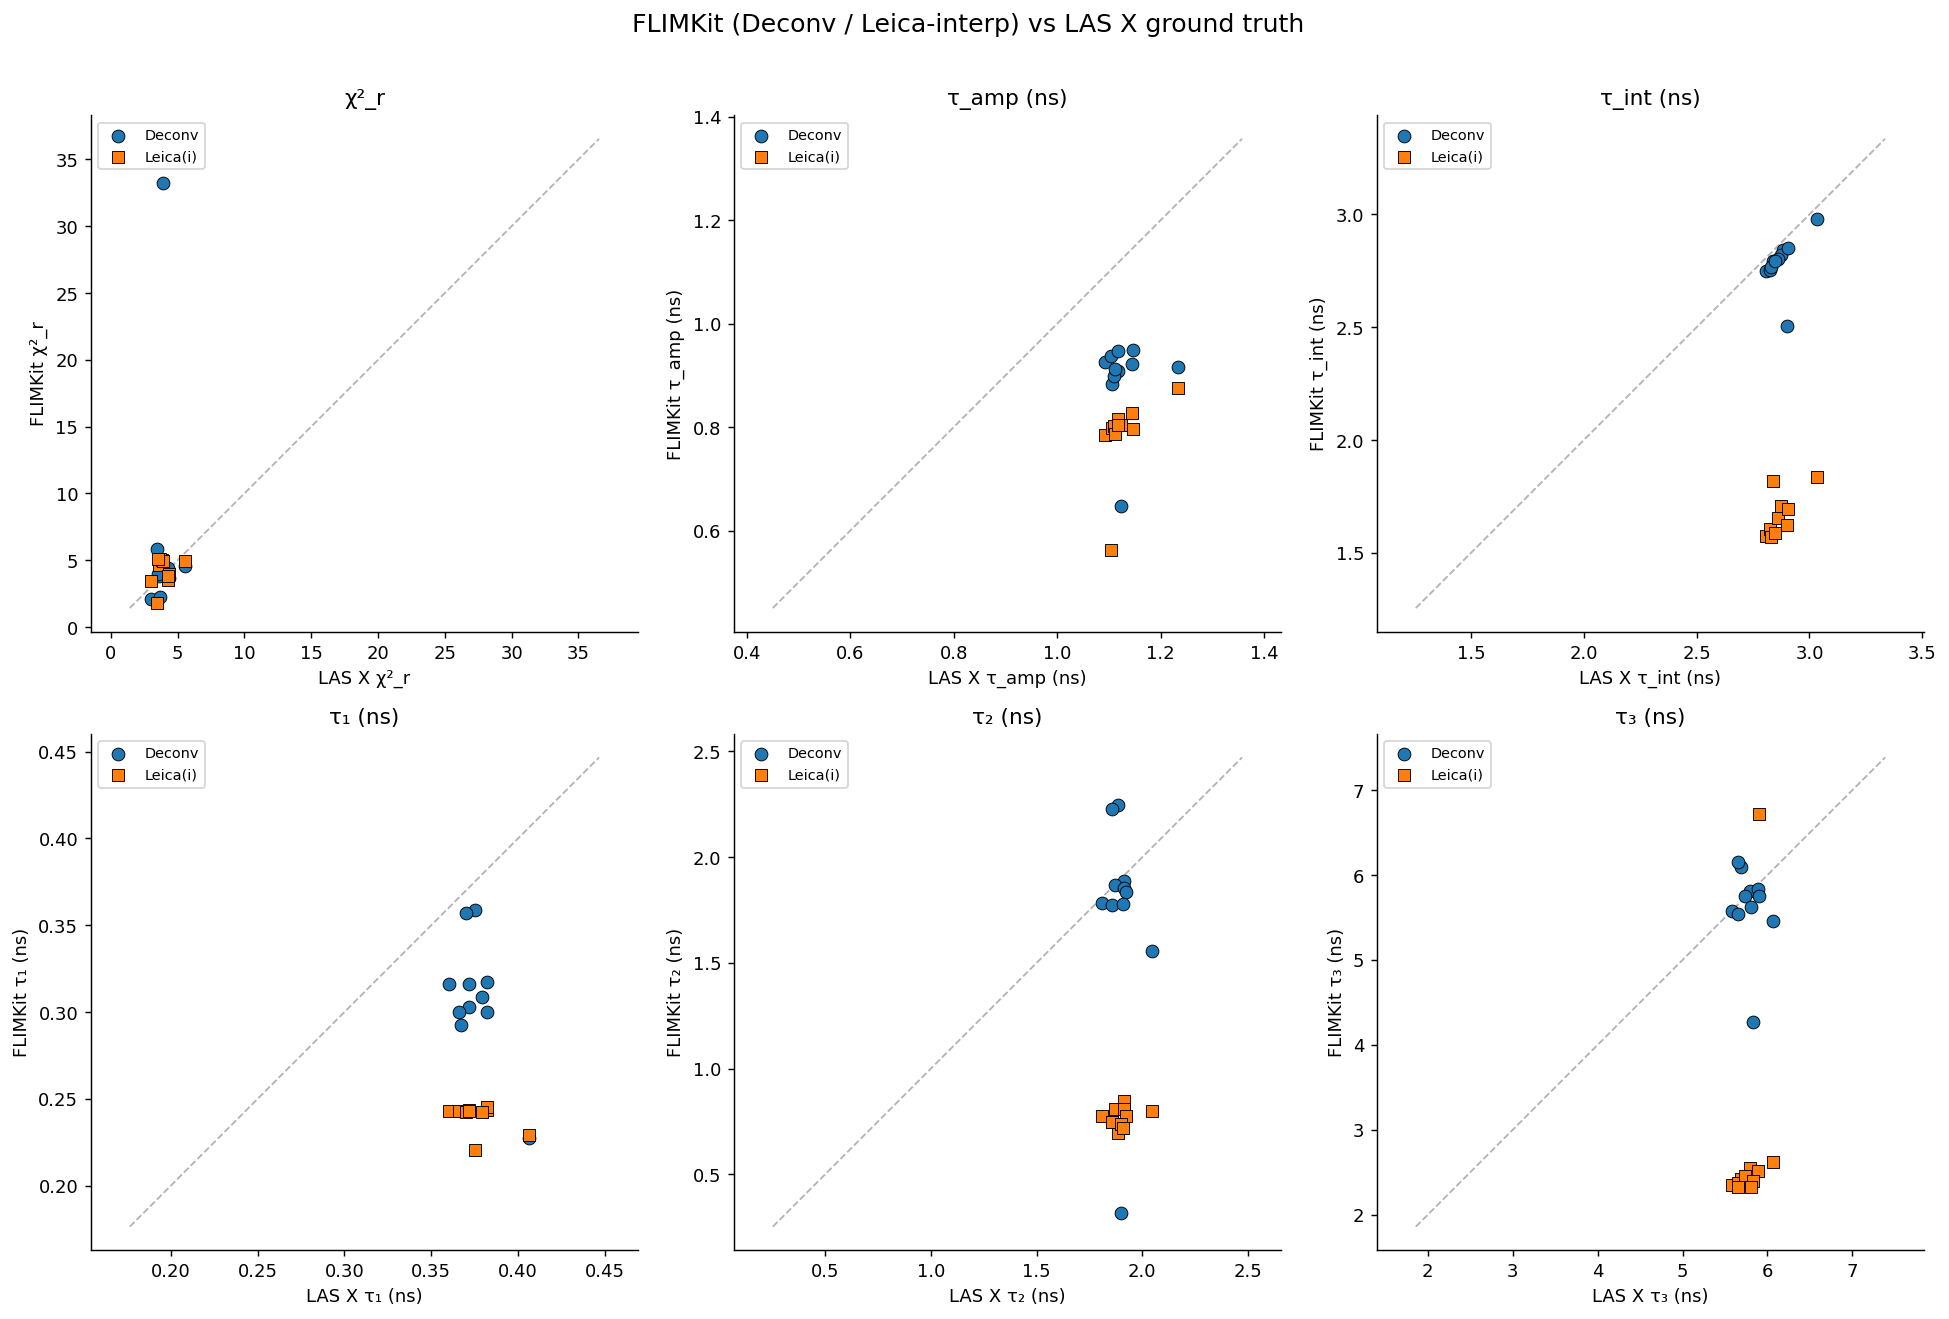

In [38]:
# ── Visual: scatter plots — FLIMKit vs LAS X ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('FLIMKit (Deconv / Leica-interp) vs LAS X ground truth', fontsize=14, y=1.01)

plot_specs = [
    ('χ²_r',    'lasx_chi2',    'dc_chi2_r',  'li_chi2_r'),
    ('τ_amp (ns)', 'lasx_tau_amp', 'dc_tau_amp', 'li_tau_amp'),
    ('τ_int (ns)', 'lasx_tau_int', 'dc_tau_int', 'li_tau_int'),
    ('τ₁ (ns)',    'lasx_tau1',    'dc_tau1',    'li_tau1'),
    ('τ₂ (ns)',    'lasx_tau2',    'dc_tau2',    'li_tau2'),
    ('τ₃ (ns)',    'lasx_tau3',    'dc_tau3',    'li_tau3'),
]

for ax, (label, lasx_col, dc_col, li_col) in zip(axes.flat, plot_specs):
    x = dfr[lasx_col].values
    y_dc = dfr[dc_col].values
    y_li = dfr[li_col].values

    # Identity line
    lo = min(np.nanmin(x), np.nanmin(y_dc), np.nanmin(y_li)) * 0.8
    hi = max(np.nanmax(x), np.nanmax(y_dc), np.nanmax(y_li)) * 1.1
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.3, lw=1)

    ax.scatter(x, y_dc, c='tab:blue', s=50, zorder=3, label='Deconv', edgecolors='k', linewidths=0.5)
    ax.scatter(x, y_li, c='tab:orange', s=50, zorder=3, label='Leica(i)', edgecolors='k',
               linewidths=0.5, marker='s')

    ax.set_xlabel(f'LAS X {label}')
    ax.set_ylabel(f'FLIMKit {label}')
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.set_aspect('equal', adjustable='datalim')

plt.tight_layout()
plt.show()

## 26-file expanded dataset validation

Comprehensive comparison on the full `/Volumes/Lexar/test_fit_dataset/` dataset.
Methods: **Deconv (PTU-only)** vs **Leica(interp)** vs **LAS X ground truth**.

In [40]:
# ── 26-file dataset: discover pairs ───────────────────────────────────────────
DATA_DIR_26 = Path("/Volumes/Lexar/test_fit_dataset/")

pairs_26 = []
for ptu_path in sorted(DATA_DIR_26.glob("*.ptu")):
    if ptu_path.name.startswith("._"):
        continue  # skip macOS resource forks
    name = ptu_path.stem
    xlsx_path = DATA_DIR_26 / f"{name}.xlsx"
    fit_path  = DATA_DIR_26 / f"{name}_fit.xlsx"
    if xlsx_path.exists() and fit_path.exists():
        pairs_26.append((name, ptu_path, xlsx_path, fit_path))

print(f"Found {len(pairs_26)} complete triplets")
for name, *_ in pairs_26:
    print(f"  {name}")

Found 26 complete triplets
  Ado_1
  Ctrl_1
  Dara_Ima_2
  Dara_Ima_Ado_2
  Daratumab_1
  Daratumab_Ado_1
  Daratumab_Ado_2
  Etr_Pom1_PSB_2
  Etr_Pom1_PSB_Ado_2
  Etrumadenant_1
  Etrumadenant_Ado_2
  Imaradenant_2
  Imaradenant_Ado_2
  PBMCs-well2-untreated-FOV1
  PSB12379_1
  PSB12379_Ado_1
  Pom1_2
  Tcells-well1-untreated-FOV1
  Tcells-well2-untreated-FOV1
  Tcells-well2-untreated-FOV5
  well1-FOV1-20x
  well2-FOV1-40xH2O
  well4-FOV1-40x-ado-t0
  well4-FOV1-40x-ado-t20
  well4-FOV1-40x-ado-t40
  well4-FOV1-40x-ado-t60


In [41]:
# ── Comprehensive 26-file validation: Deconv vs Leica(interp) vs LAS X ────────
import contextlib, io, time

full_results_26 = []
for i, (name, ptu_path, xlsx_path, fit_path) in enumerate(pairs_26):
    print(f"[{i+1}/{len(pairs_26)}] {name}", end="", flush=True)
    t0 = time.time()

    ptu_f = PTUFile(str(ptu_path), verbose=False)
    dec   = ptu_f.summed_decay()
    tres  = ptu_f.tcspc_res
    nbins = ptu_f.n_bins
    xlsx_data = load_xlsx(str(xlsx_path))
    lasx  = parse_lasx_fit(str(fit_path))
    lasx_taus = sorted(lasx['taus_ns'])

    row = dict(name=name)

    # LAS X ground truth
    row['lasx_chi2']    = lasx['chi2']
    row['lasx_tau_amp'] = lasx['tau_amp_ns']
    row['lasx_tau_int'] = lasx['tau_int_ns']
    row['lasx_tau1']    = lasx_taus[0]
    row['lasx_tau2']    = lasx_taus[1]
    row['lasx_tau3']    = lasx_taus[2]

    # ── Deconv (PTU only) ────────────────────────────────────────────────────
    try:
        _, sdc, sdc1 = estimate_irf_deconv(dec, tres, nbins, N_EXP, Tau_min, Tau_max)
        m = extract_fit_metrics(sdc)
        for k, v in m.items():
            row[f'dc_{k}'] = v
        row['dc_p1_chi2'] = sdc1['reduced_chi2']
    except Exception as e:
        print(f" [deconv ERR: {e}]", end="")

    # ── Leica (interp) ───────────────────────────────────────────────────────
    try:
        irf_li = irf_from_xlsx(xlsx_data, nbins, tres)
        with contextlib.redirect_stdout(io.StringIO()):
            _, sli = fit_summed(dec, tres, nbins, irf_li,
                                True, True, True, N_EXP, Tau_min, Tau_max,
                                optimizer='de', de_popsize=30, de_maxiter=5000,
                                workers=-1, polish=True, cost_function='poisson')
        m = extract_fit_metrics(sli)
        for k, v in m.items():
            row[f'li_{k}'] = v
    except Exception as e:
        print(f" [leica ERR: {e}]", end="")

    dt = time.time() - t0
    dc_chi2 = row.get('dc_chi2_r', np.nan)
    li_chi2 = row.get('li_chi2_r', np.nan)
    print(f"  LAS X={row['lasx_chi2']:.2f}  dc={dc_chi2:.2f}  li={li_chi2:.2f}  ({dt:.0f}s)")
    full_results_26.append(row)

print(f"\n✓ All {len(full_results_26)} files processed")

[1/26] Ado_1    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 14 pts
    irf_c       : 14 pts
    fit_t       : 520 pts
    fit_c       : absent
    res_t       : 520 pts
    res_c       : absent
  LAS X=2.99  dc=2.09  li=3.48  (13s)
[2/26] Ctrl_1    decay_t     : 519 pts
    decay_c     : 519 pts
    irf_t       : 17 pts
    irf_c       : 17 pts
    fit_t       : 496 pts
    fit_c       : 496 pts
    res_t       : 519 pts
    res_c       : 496 pts
  LAS X=3.48  dc=5.85  li=1.78  (14s)
[3/26] Dara_Ima_2    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 21 pts
    irf_c       : 21 pts
    fit_t       : 520 pts
    fit_c       : absent
    res_t       : 520 pts
    res_c       : absent
  LAS X=3.64  dc=3.79  li=4.67  (13s)
[4/26] Dara_Ima_Ado_2    decay_t     : 524 pts
    decay_c     : 524 pts
    irf_t       : 12 pts
    irf_c       : 12 pts
    fit_t       : 524 pts
    fit_c       : absent
    res_t       : 524 pts
    res_c       : absent
  LAS

In [42]:
# ── 26-file results table ─────────────────────────────────────────────────────
dfr_26 = pd.DataFrame(full_results_26)

metrics_26 = [
    ('χ²_r',    'lasx_chi2',    'dc_chi2_r',  'li_chi2_r'),
    ('τ_amp',   'lasx_tau_amp', 'dc_tau_amp',  'li_tau_amp'),
    ('τ_int',   'lasx_tau_int', 'dc_tau_int',  'li_tau_int'),
    ('τ₁',      'lasx_tau1',    'dc_tau1',     'li_tau1'),
    ('τ₂',      'lasx_tau2',    'dc_tau2',     'li_tau2'),
    ('τ₃',      'lasx_tau3',    'dc_tau3',     'li_tau3'),
]

for metric_name, lasx_col, dc_col, li_col in metrics_26:
    print(f"\n{'═'*80}")
    print(f"  {metric_name}")
    print(f"{'═'*80}")
    print(f"{'Sample':<30} {'LAS X':>8} {'Deconv':>8} {'Leica(i)':>8}  {'|Δ_dc|':>7} {'|Δ_li|':>7}  {'Win':>7}")
    print(f"{'─'*80}")
    dc_diffs = []
    li_diffs = []
    for _, r in dfr_26.iterrows():
        ref = r.get(lasx_col, np.nan)
        dc  = r.get(dc_col, np.nan)
        li  = r.get(li_col, np.nan)
        d_dc = abs(dc - ref) if not (np.isnan(dc) or np.isnan(ref)) else np.nan
        d_li = abs(li - ref) if not (np.isnan(li) or np.isnan(ref)) else np.nan
        dc_diffs.append(d_dc)
        li_diffs.append(d_li)
        win = ""
        if not (np.isnan(d_dc) or np.isnan(d_li)):
            win = "DC" if d_dc < d_li else "LI"
        print(f"{r['name']:<30} {ref:>8.3f} {dc:>8.3f} {li:>8.3f}  {d_dc:>7.3f} {d_li:>7.3f}  {win:>7}")
    
    dc_arr = np.array([x for x in dc_diffs if not np.isnan(x)])
    li_arr = np.array([x for x in li_diffs if not np.isnan(x)])
    print(f"{'─'*80}")
    print(f"{'Mean |Δ| vs LAS X':<30} {'':>8} {'':>8} {'':>8}  {dc_arr.mean():>7.3f} {li_arr.mean():>7.3f}")
    print(f"{'Median |Δ|':<30} {'':>8} {'':>8} {'':>8}  {np.median(dc_arr):>7.3f} {np.median(li_arr):>7.3f}")
    print(f"{'Max  |Δ|':<30} {'':>8} {'':>8} {'':>8}  {dc_arr.max():>7.3f} {li_arr.max():>7.3f}")


════════════════════════════════════════════════════════════════════════════════
  χ²_r
════════════════════════════════════════════════════════════════════════════════
Sample                            LAS X   Deconv Leica(i)   |Δ_dc|  |Δ_li|      Win
────────────────────────────────────────────────────────────────────────────────
Ado_1                             2.993    2.088    3.477    0.905   0.484       LI
Ctrl_1                            3.475    5.845    1.777    2.370   1.698       LI
Dara_Ima_2                        3.640    3.791    4.667    0.151   1.027       DC
Dara_Ima_Ado_2                    3.826    4.251    5.018    0.425   1.192       DC
Daratumab_1                       4.308    4.306    3.555    0.002   0.753       DC
Daratumab_Ado_1                   4.383    3.707    3.964    0.676   0.419       LI
Daratumab_Ado_2                   5.566    4.531    4.972    1.035   0.594       LI
Etr_Pom1_PSB_2                    4.756    4.235    4.733    0.521   0.023   

In [43]:
# ── 26-file summary: mean |Δ| vs LAS X + win counts ──────────────────────────
print(f"\n{'='*60}")
print(f"  SUMMARY: n={len(dfr_26)} files")
print(f"{'='*60}")
print(f"\n{'Metric':<10} {'Deconv |Δ|':>12} {'Leica(i) |Δ|':>14}  {'Winner':>8}")
print("─" * 50)
for metric_name, lasx_col, dc_col, li_col in metrics_26:
    dc_d = (dfr_26[dc_col] - dfr_26[lasx_col]).abs().dropna()
    li_d = (dfr_26[li_col] - dfr_26[lasx_col]).abs().dropna()
    w = "Deconv" if dc_d.mean() < li_d.mean() else "Leica(i)"
    print(f"{metric_name:<10} {dc_d.mean():>12.3f} {li_d.mean():>14.3f}  {w:>8}")

# Win counts
print(f"\n{'─'*50}")
print("Per-file win counts (closer to LAS X):")
for metric_name, lasx_col, dc_col, li_col in metrics_26:
    dc_d = (dfr_26[dc_col] - dfr_26[lasx_col]).abs()
    li_d = (dfr_26[li_col] - dfr_26[lasx_col]).abs()
    dc_wins = (dc_d < li_d).sum()
    li_wins = (dc_d > li_d).sum()
    ties = len(dfr_26) - dc_wins - li_wins
    print(f"  {metric_name:<10} Deconv={dc_wins}  Leica(i)={li_wins}  ties={ties}")

# χ²_r direct comparison
print(f"\nχ²_r (lower is better):")
dw = (dfr_26['dc_chi2_r'] < dfr_26['li_chi2_r']).sum()
print(f"  Deconv wins {dw}/{len(dfr_26)}, Leica(i) wins {len(dfr_26)-dw}/{len(dfr_26)}")

# Outlier detection
print(f"\nOutliers (|Δχ²_r| > 10 vs LAS X):")
for _, r in dfr_26.iterrows():
    dc_d = abs(r.get('dc_chi2_r', np.nan) - r['lasx_chi2'])
    li_d = abs(r.get('li_chi2_r', np.nan) - r['lasx_chi2'])
    if dc_d > 10 or li_d > 10:
        print(f"  {r['name']}: LAS X={r['lasx_chi2']:.2f}, DC={r.get('dc_chi2_r',np.nan):.2f} (Δ={dc_d:.1f}), "
              f"LI={r.get('li_chi2_r',np.nan):.2f} (Δ={li_d:.1f})")


  SUMMARY: n=26 files

Metric       Deconv |Δ|   Leica(i) |Δ|    Winner
──────────────────────────────────────────────────
χ²_r              6.206          2.047  Leica(i)
τ_amp             0.294          0.457    Deconv
τ_int             0.112          1.267    Deconv
τ₁                0.064          0.119    Deconv
τ₂                0.551          1.182    Deconv
τ₃                0.489          2.668    Deconv

──────────────────────────────────────────────────
Per-file win counts (closer to LAS X):
  χ²_r       Deconv=13  Leica(i)=13  ties=0
  τ_amp      Deconv=24  Leica(i)=2  ties=0
  τ_int      Deconv=25  Leica(i)=1  ties=0
  τ₁         Deconv=22  Leica(i)=4  ties=0
  τ₂         Deconv=20  Leica(i)=6  ties=0
  τ₃         Deconv=24  Leica(i)=2  ties=0

χ²_r (lower is better):
  Deconv wins 17/26, Leica(i) wins 9/26

Outliers (|Δχ²_r| > 10 vs LAS X):
  Imaradenant_Ado_2: LAS X=3.93, DC=33.22 (Δ=29.3), LI=4.97 (Δ=1.0)
  Pom1_2: LAS X=4.99, DC=81.49 (Δ=76.5), LI=5.34 (Δ=0.3)
  well1

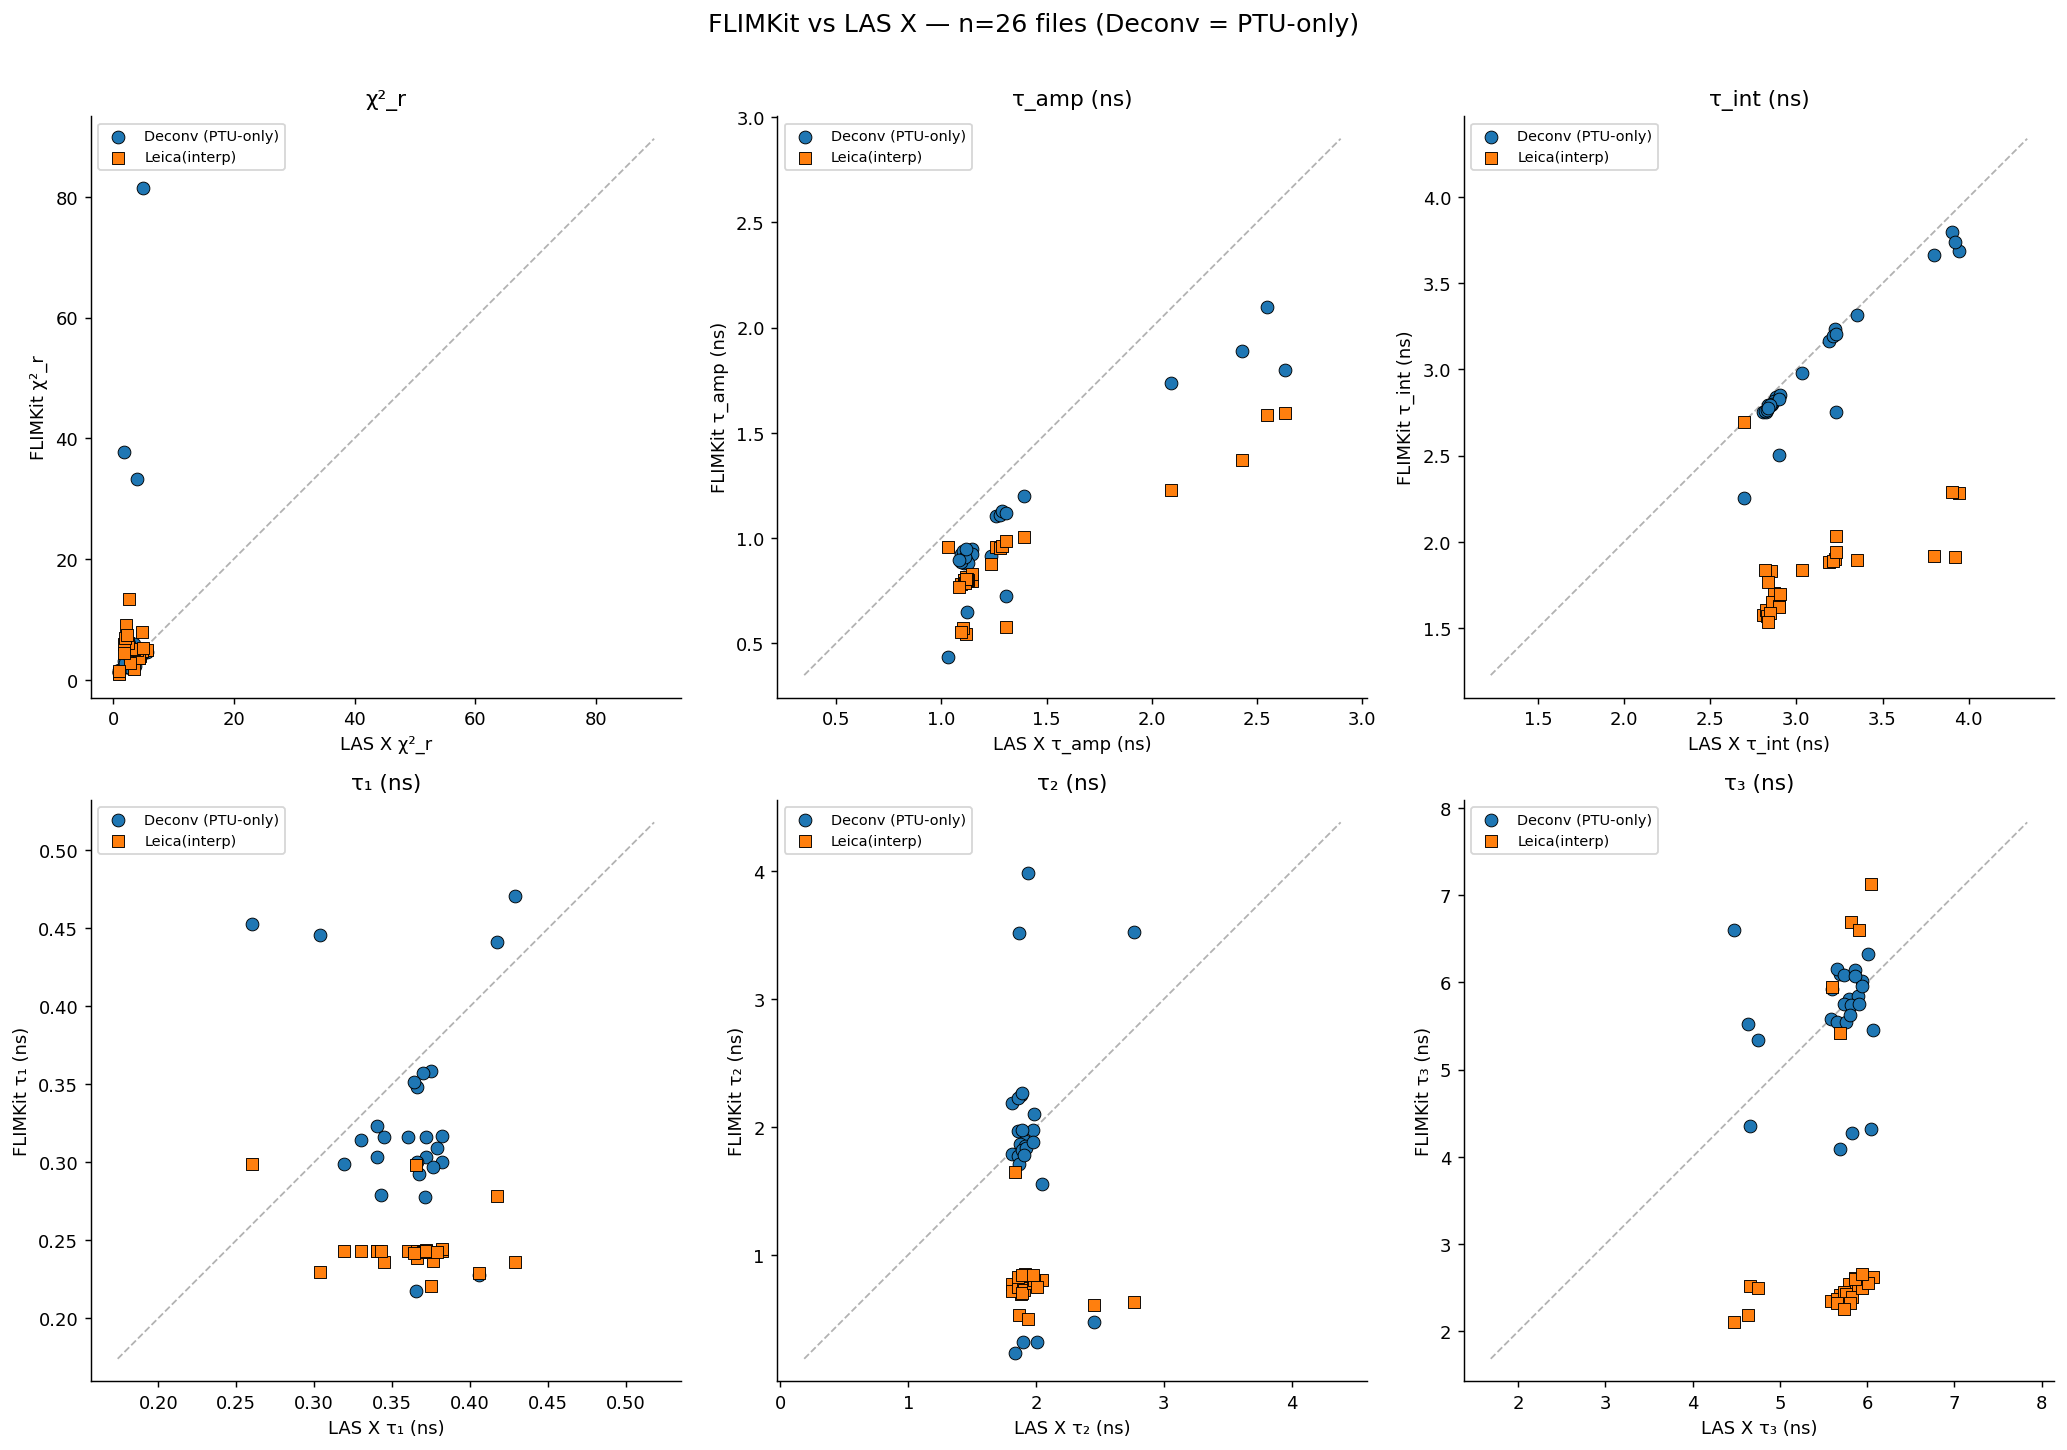

In [44]:
# ── 26-file scatter plots: FLIMKit vs LAS X ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 11))
fig.suptitle(f'FLIMKit vs LAS X — n={len(dfr_26)} files (Deconv = PTU-only)', fontsize=14, y=1.01)

plot_specs_26 = [
    ('χ²_r',       'lasx_chi2',    'dc_chi2_r',  'li_chi2_r'),
    ('τ_amp (ns)',  'lasx_tau_amp', 'dc_tau_amp', 'li_tau_amp'),
    ('τ_int (ns)',  'lasx_tau_int', 'dc_tau_int', 'li_tau_int'),
    ('τ₁ (ns)',     'lasx_tau1',    'dc_tau1',    'li_tau1'),
    ('τ₂ (ns)',     'lasx_tau2',    'dc_tau2',    'li_tau2'),
    ('τ₃ (ns)',     'lasx_tau3',    'dc_tau3',    'li_tau3'),
]

for ax, (label, lasx_col, dc_col, li_col) in zip(axes.flat, plot_specs_26):
    x = dfr_26[lasx_col].values
    y_dc = dfr_26[dc_col].values
    y_li = dfr_26[li_col].values

    lo = min(np.nanmin(x), np.nanmin(y_dc), np.nanmin(y_li)) * 0.8
    hi = max(np.nanmax(x), np.nanmax(y_dc), np.nanmax(y_li)) * 1.1
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.3, lw=1)

    ax.scatter(x, y_dc, c='tab:blue', s=50, zorder=3, label='Deconv (PTU-only)',
               edgecolors='k', linewidths=0.5)
    ax.scatter(x, y_li, c='tab:orange', s=50, zorder=3, label='Leica(interp)',
               edgecolors='k', linewidths=0.5, marker='s')

    ax.set_xlabel(f'LAS X {label}')
    ax.set_ylabel(f'FLIMKit {label}')
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.set_aspect('equal', adjustable='datalim')

plt.tight_layout()
plt.show()

In [45]:
# ── Deconv vs LAS X: head-to-head ─────────────────────────────────────────────
cols = ['name','lasx_chi2','dc_chi2_r','lasx_tau_amp','dc_tau_amp',
        'lasx_tau_int','dc_tau_int','lasx_tau1','dc_tau1',
        'lasx_tau2','dc_tau2','lasx_tau3','dc_tau3']
df_dc = dfr_26[cols].copy()

print(f"{'Sample':<30} {'χ²_r':>14} {'τ_amp (ns)':>18} {'τ_int (ns)':>18} {'τ₁ (ns)':>14} {'τ₂ (ns)':>14} {'τ₃ (ns)':>14}")
print(f"{'':30} {'LAS X':>7}{'DC':>7} {'LAS X':>9}{'DC':>9} {'LAS X':>9}{'DC':>9} {'LAS X':>7}{'DC':>7} {'LAS X':>7}{'DC':>7} {'LAS X':>7}{'DC':>7}")
print("─" * 142)
for _, r in df_dc.iterrows():
    print(f"{r['name']:<30} {r['lasx_chi2']:>7.2f}{r['dc_chi2_r']:>7.2f} "
          f"{r['lasx_tau_amp']:>9.3f}{r['dc_tau_amp']:>9.3f} "
          f"{r['lasx_tau_int']:>9.3f}{r['dc_tau_int']:>9.3f} "
          f"{r['lasx_tau1']:>7.3f}{r['dc_tau1']:>7.3f} "
          f"{r['lasx_tau2']:>7.3f}{r['dc_tau2']:>7.3f} "
          f"{r['lasx_tau3']:>7.3f}{r['dc_tau3']:>7.3f}")
print("─" * 142)

# Aggregate stats
print(f"\n{'Metric':<12} {'LAS X mean':>10} {'DC mean':>10} {'Mean |Δ|':>10} {'Median |Δ|':>10} {'Max |Δ|':>10}")
print("─" * 65)
for label, lx, dc in [('χ²_r','lasx_chi2','dc_chi2_r'), ('τ_amp','lasx_tau_amp','dc_tau_amp'),
                       ('τ_int','lasx_tau_int','dc_tau_int'), ('τ₁','lasx_tau1','dc_tau1'),
                       ('τ₂','lasx_tau2','dc_tau2'), ('τ₃','lasx_tau3','dc_tau3')]:
    diff = (dfr_26[dc] - dfr_26[lx]).abs().dropna()
    print(f"{label:<12} {dfr_26[lx].mean():>10.3f} {dfr_26[dc].mean():>10.3f} "
          f"{diff.mean():>10.3f} {diff.median():>10.3f} {diff.max():>10.3f}")

# Excluding outliers (|Δχ²| > 10)
mask_ok = (dfr_26['dc_chi2_r'] - dfr_26['lasx_chi2']).abs() <= 10
n_ok = mask_ok.sum()
print(f"\nExcluding {(~mask_ok).sum()} outliers (|Δχ²_r|>10), n={n_ok}:")
print(f"{'Metric':<12} {'Mean |Δ|':>10} {'Median |Δ|':>10}")
print("─" * 35)
for label, lx, dc in [('χ²_r','lasx_chi2','dc_chi2_r'), ('τ_amp','lasx_tau_amp','dc_tau_amp'),
                       ('τ_int','lasx_tau_int','dc_tau_int'), ('τ₁','lasx_tau1','dc_tau1'),
                       ('τ₂','lasx_tau2','dc_tau2'), ('τ₃','lasx_tau3','dc_tau3')]:
    diff = (dfr_26.loc[mask_ok, dc] - dfr_26.loc[mask_ok, lx]).abs()
    print(f"{label:<12} {diff.mean():>10.3f} {diff.median():>10.3f}")

Sample                                   χ²_r         τ_amp (ns)         τ_int (ns)        τ₁ (ns)        τ₂ (ns)        τ₃ (ns)
                                 LAS X     DC     LAS X       DC     LAS X       DC   LAS X     DC   LAS X     DC   LAS X     DC
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Ado_1                             2.99   2.09     1.146    0.948     2.882    2.840   0.375  0.358   1.886  2.247   5.686  6.092
Ctrl_1                            3.48   5.85     1.234    0.916     3.032    2.981   0.406  0.228   2.045  1.556   6.071  5.454
Dara_Ima_2                        3.64   3.79     1.093    0.925     2.807    2.751   0.360  0.316   1.808  1.785   5.588  5.575
Dara_Ima_Ado_2                    3.83   4.25     1.106    0.883     2.824    2.752   0.367  0.293   1.856  1.774   5.659  5.545
Daratumab_1                       4.31   4.31     1.117    0.908     2.873    2.818

In [46]:
# ── Compact Deconv vs LAS X summary ───────────────────────────────────────────
# Excluding outliers (|Δχ²| > 10)
mask_ok = (dfr_26['dc_chi2_r'] - dfr_26['lasx_chi2']).abs() <= 10
n_out = (~mask_ok).sum()
outliers = dfr_26.loc[~mask_ok, 'name'].tolist()

print(f"n={len(dfr_26)} files, {n_out} outliers excluded: {outliers}\n")
print(f"ALL {len(dfr_26)} files:")
print(f"{'Metric':<12} {'LAS X':>8} {'Deconv':>8} {'|Δ| mean':>9} {'|Δ| med':>8}")
print("─" * 48)
for label, lx, dc in [('χ²_r','lasx_chi2','dc_chi2_r'), ('τ_amp','lasx_tau_amp','dc_tau_amp'),
                       ('τ_int','lasx_tau_int','dc_tau_int'), ('τ₁','lasx_tau1','dc_tau1'),
                       ('τ₂','lasx_tau2','dc_tau2'), ('τ₃','lasx_tau3','dc_tau3')]:
    diff = (dfr_26[dc] - dfr_26[lx]).abs()
    print(f"{label:<12} {dfr_26[lx].mean():>8.3f} {dfr_26[dc].mean():>8.3f} {diff.mean():>9.3f} {diff.median():>8.3f}")

print(f"\nEXCLUDING {n_out} outliers (n={mask_ok.sum()}):")
print(f"{'Metric':<12} {'LAS X':>8} {'Deconv':>8} {'|Δ| mean':>9} {'|Δ| med':>8}")
print("─" * 48)
for label, lx, dc in [('χ²_r','lasx_chi2','dc_chi2_r'), ('τ_amp','lasx_tau_amp','dc_tau_amp'),
                       ('τ_int','lasx_tau_int','dc_tau_int'), ('τ₁','lasx_tau1','dc_tau1'),
                       ('τ₂','lasx_tau2','dc_tau2'), ('τ₃','lasx_tau3','dc_tau3')]:
    diff = (dfr_26.loc[mask_ok, dc] - dfr_26.loc[mask_ok, lx]).abs()
    print(f"{label:<12} {dfr_26.loc[mask_ok,lx].mean():>8.3f} {dfr_26.loc[mask_ok,dc].mean():>8.3f} "
          f"{diff.mean():>9.3f} {diff.median():>8.3f}")

n=26 files, 3 outliers excluded: ['Imaradenant_Ado_2', 'Pom1_2', 'well4-FOV1-40x-ado-t40']

ALL 26 files:
Metric          LAS X   Deconv  |Δ| mean  |Δ| med
────────────────────────────────────────────────
χ²_r            3.080    8.839     6.206    0.736
τ_amp           1.362    1.068     0.294    0.210
τ_int           3.104    2.993     0.112    0.059
τ₁              0.362    0.328     0.064    0.060
τ₂              1.958    1.887     0.551    0.145
τ₃              5.630    5.612     0.489    0.291

EXCLUDING 3 outliers (n=23):
Metric          LAS X   Deconv  |Δ| mean  |Δ| med
────────────────────────────────────────────────
χ²_r            3.013    3.361     0.853    0.676
τ_amp           1.389    1.128     0.261    0.208
τ_int           3.125    3.057     0.069    0.056
τ₁              0.362    0.334     0.062    0.064
τ₂              1.964    2.096     0.411    0.118
τ₃              5.601    5.793     0.340    0.208


In [47]:
# ── R² and ANOVA: Deconv vs LAS X (all 26 files, outliers included) ───────────
from scipy import stats

# R² (coefficient of determination) — how well Deconv predicts LAS X
pairs_r2 = [
    ('τ₁',    'lasx_tau1',    'dc_tau1'),
    ('τ₂',    'lasx_tau2',    'dc_tau2'),
    ('τ₃',    'lasx_tau3',    'dc_tau3'),
    ('τ_amp', 'lasx_tau_amp', 'dc_tau_amp'),
    ('τ_int', 'lasx_tau_int', 'dc_tau_int'),
]

print(f"R² — Deconv vs LAS X (n={len(dfr_26)}, all files incl. outliers)")
print(f"{'Metric':<10} {'R²':>8} {'slope':>8} {'intercept':>10} {'Pearson r':>10} {'p-value':>12}")
print("─" * 62)
for label, lx_col, dc_col in pairs_r2:
    x = dfr_26[lx_col].dropna().values
    y = dfr_26[dc_col].dropna().values
    # Use common valid indices
    mask = ~(np.isnan(dfr_26[lx_col]) | np.isnan(dfr_26[dc_col]))
    x, y = dfr_26.loc[mask, lx_col].values, dfr_26.loc[mask, dc_col].values
    slope, intercept, r, p, se = stats.linregress(x, y)
    r2 = r**2
    print(f"{label:<10} {r2:>8.4f} {slope:>8.4f} {intercept:>10.4f} {r:>10.4f} {p:>12.2e}")

# ── Paired tests: is Deconv significantly different from LAS X? ──────────────
# Paired t-test (parametric) and Wilcoxon signed-rank (non-parametric)
# Null hypothesis: no difference between Deconv and LAS X values
print(f"\n\nPaired tests — Deconv vs LAS X (n={len(dfr_26)})")
print(f"{'Metric':<10} {'Mean diff':>10} {'Paired t':>10} {'t p-val':>12} {'Wilcoxon W':>11} {'W p-val':>12} {'Sig?':>6}")
print("─" * 75)
for label, lx_col, dc_col in pairs_r2:
    mask = ~(np.isnan(dfr_26[lx_col]) | np.isnan(dfr_26[dc_col]))
    lx_vals = dfr_26.loc[mask, lx_col].values
    dc_vals = dfr_26.loc[mask, dc_col].values
    diff = dc_vals - lx_vals
    
    t_stat, t_p = stats.ttest_rel(dc_vals, lx_vals)
    w_stat, w_p = stats.wilcoxon(diff)
    sig = "***" if t_p < 0.001 else "**" if t_p < 0.01 else "*" if t_p < 0.05 else "ns"
    print(f"{label:<10} {diff.mean():>10.4f} {t_stat:>10.3f} {t_p:>12.2e} {w_stat:>11.1f} {w_p:>12.2e} {sig:>6}")

# ── One-way repeated-measures ANOVA across all 5 lifetime metrics ────────────
# Are the methods interchangeable overall?
# Pool all lifetime comparisons as (LAS X, Deconv) paired observations
print(f"\n\nOverall: are Deconv lifetimes equivalent to LAS X?")
all_lx = []
all_dc = []
for label, lx_col, dc_col in pairs_r2:
    mask = ~(np.isnan(dfr_26[lx_col]) | np.isnan(dfr_26[dc_col]))
    all_lx.extend(dfr_26.loc[mask, lx_col].values)
    all_dc.extend(dfr_26.loc[mask, dc_col].values)
all_lx = np.array(all_lx)
all_dc = np.array(all_dc)

# Paired t-test on pooled lifetime values
t_all, p_all = stats.ttest_rel(all_dc, all_lx)
print(f"  Pooled paired t-test (n={len(all_lx)} paired observations):")
print(f"    t = {t_all:.3f}, p = {p_all:.2e}")
print(f"    Mean diff = {(all_dc - all_lx).mean():.4f} ns")
print(f"    {'→ NOT significantly different (p≥0.05)' if p_all >= 0.05 else '→ Significantly different (p<0.05)'}")

R² — Deconv vs LAS X (n=26, all files incl. outliers)
Metric           R²    slope  intercept  Pearson r      p-value
──────────────────────────────────────────────────────────────
τ₁           0.0159  -0.2313     0.4119    -0.1260     5.40e-01
τ₂           0.0138   0.5137     0.8813     0.1176     5.67e-01
τ₃           0.0034   0.0832     5.1436     0.0579     7.79e-01
τ_amp        0.8790   0.7632     0.0285     0.9375     1.69e-12
τ_int        0.8861   0.9571     0.0220     0.9413     8.11e-13


Paired tests — Deconv vs LAS X (n=26)
Metric      Mean diff   Paired t      t p-val  Wilcoxon W      W p-val   Sig?
───────────────────────────────────────────────────────────────────────────
τ₁            -0.0333     -2.244     3.39e-02        68.0     5.13e-03      *
τ₂            -0.0708     -0.402     6.91e-01       166.0     8.22e-01     ns
τ₃            -0.0180     -0.118     9.07e-01       159.0     6.89e-01     ns
τ_amp         -0.2940     -8.495     7.72e-09         0.0     2.98e-08 

In [48]:
# ── Raw data table: all 26 files, LAS X vs Deconv ─────────────────────────────
export_cols = {
    'name': 'Sample',
    'lasx_chi2': 'LAS X χ²_r', 'dc_chi2_r': 'Deconv χ²_r',
    'lasx_tau_amp': 'LAS X τ_amp', 'dc_tau_amp': 'Deconv τ_amp',
    'lasx_tau_int': 'LAS X τ_int', 'dc_tau_int': 'Deconv τ_int',
    'lasx_tau1': 'LAS X τ₁', 'dc_tau1': 'Deconv τ₁',
    'lasx_tau2': 'LAS X τ₂', 'dc_tau2': 'Deconv τ₂',
    'lasx_tau3': 'LAS X τ₃', 'dc_tau3': 'Deconv τ₃',
}
df_export = dfr_26[list(export_cols.keys())].rename(columns=export_cols)
pd.set_option('display.max_rows', 30, 'display.max_columns', 20, 'display.width', 200, 'display.float_format', '{:.4f}'.format)
print(df_export.to_string(index=False))
pd.reset_option('display.float_format')

                     Sample  LAS X χ²_r  Deconv χ²_r  LAS X τ_amp  Deconv τ_amp  LAS X τ_int  Deconv τ_int  LAS X τ₁  Deconv τ₁  LAS X τ₂  Deconv τ₂  LAS X τ₃  Deconv τ₃
                      Ado_1      2.9930       2.0884       1.1460        0.9482       2.8820        2.8402    0.3750     0.3585    1.8860     2.2469    5.6860     6.0923
                     Ctrl_1      3.4750       5.8454       1.2340        0.9164       3.0320        2.9808    0.4060     0.2275    2.0450     1.5561    6.0710     5.4545
                 Dara_Ima_2      3.6400       3.7909       1.0930        0.9252       2.8070        2.7509    0.3600     0.3159    1.8080     1.7846    5.5880     5.5752
             Dara_Ima_Ado_2      3.8260       4.2510       1.1060        0.8831       2.8240        2.7518    0.3670     0.2927    1.8560     1.7743    5.6590     5.5445
                Daratumab_1      4.3080       4.3056       1.1170        0.9078       2.8730        2.8185    0.3720     0.3032    1.9130     1.8883  

In [49]:
# ── Export to CSV for easy copy-paste ──────────────────────────────────────────
csv_path = Path("deconv_vs_lasx_26files.csv")
df_export.to_csv(csv_path, index=False)
print(f"Saved to {csv_path.resolve()}")
print(f"\nCSV contents:\n")
print(csv_path.read_text())

Saved to /Users/as-hunt/FLIMKit/deconv_vs_lasx_26files.csv

CSV contents:

Sample,LAS X χ²_r,Deconv χ²_r,LAS X τ_amp,Deconv τ_amp,LAS X τ_int,Deconv τ_int,LAS X τ₁,Deconv τ₁,LAS X τ₂,Deconv τ₂,LAS X τ₃,Deconv τ₃
Ado_1,2.993,2.088354099704535,1.146,0.9482020299704215,2.882,2.8401942323965024,0.375,0.3584872476348737,1.886,2.24689044622406,5.686,6.092320738500815
Ctrl_1,3.475,5.8454283676733665,1.234,0.9163756134787617,3.032,2.9808158003245664,0.406,0.22751997427831944,2.045,1.5560723223877695,6.071,5.454495598003609
Dara_Ima_2,3.64,3.7908968249513526,1.093,0.9252452050921641,2.807,2.750911661924791,0.36,0.31588864577578823,1.808,1.784630011759369,5.588,5.5751513890210695
Dara_Ima_Ado_2,3.826,4.251030265236806,1.106,0.883126710912598,2.824,2.7518098012426973,0.367,0.29268655279909406,1.856,1.774339743947964,5.659,5.544514927170053
Daratumab_1,4.308,4.305580071762954,1.117,0.9078403719682693,2.873,2.8184630972313856,0.372,0.30317780352768836,1.913,1.888254758113876,5.791,5.807258310828809

## Machine IRF: Train on 20, Test on 6

Extract a single "machine IRF" by peak-aligning and averaging the xlsx IRFs from 20 randomly chosen training files. Apply that fixed IRF to the 6 held-out test files and compare against Leica(interp) per-file fits.

In [50]:
# ── Train/test split: extract machine IRF from 20, test on 6 ──────────────────
import random
random.seed(42)

# Shuffle and split
indices = list(range(len(pairs_26)))
random.shuffle(indices)
train_idx = indices[:20]
test_idx  = indices[20:]

train_pairs = [pairs_26[i] for i in train_idx]
test_pairs  = [pairs_26[i] for i in test_idx]

print(f"TRAIN ({len(train_pairs)}):")
for name, *_ in train_pairs:
    print(f"  {name}")
print(f"\nTEST ({len(test_pairs)}):")
for name, *_ in test_pairs:
    print(f"  {name}")

TRAIN (20):
  Pom1_2
  Imaradenant_Ado_2
  Etrumadenant_1
  well4-FOV1-40x-ado-t60
  Tcells-well2-untreated-FOV5
  Daratumab_Ado_2
  Daratumab_Ado_1
  Etrumadenant_Ado_2
  PSB12379_Ado_1
  well4-FOV1-40x-ado-t0
  Imaradenant_2
  Tcells-well2-untreated-FOV1
  Ctrl_1
  PSB12379_1
  well4-FOV1-40x-ado-t20
  PBMCs-well2-untreated-FOV1
  Dara_Ima_2
  Tcells-well1-untreated-FOV1
  well4-FOV1-40x-ado-t40
  Daratumab_1

TEST (6):
  well2-FOV1-40xH2O
  Etr_Pom1_PSB_2
  Etr_Pom1_PSB_Ado_2
  Ado_1
  Dara_Ima_Ado_2
  well1-FOV1-20x


    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 21 pts
    irf_c       : 21 pts
    fit_t       : 462 pts
    fit_c       : 462 pts
    res_t       : 520 pts
    res_c       : 462 pts
    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 12 pts
    irf_c       : 12 pts
    fit_t       : 520 pts
    fit_c       : absent
    res_t       : 520 pts
    res_c       : absent
    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 22 pts
    irf_c       : 22 pts
    fit_t       : 520 pts
    fit_c       : absent
    res_t       : 520 pts
    res_c       : absent
    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 16 pts
    irf_c       : 16 pts
    fit_t       : 462 pts
    fit_c       : 462 pts
    res_t       : 462 pts
    res_c       : 462 pts
    decay_t     : 518 pts
    decay_c     : 518 pts
    irf_t       : 19 pts
    irf_c       : 19 pts
    fit_t       : 462 pts
    fit_c       : 462 pts
    res_t       : 518 pts


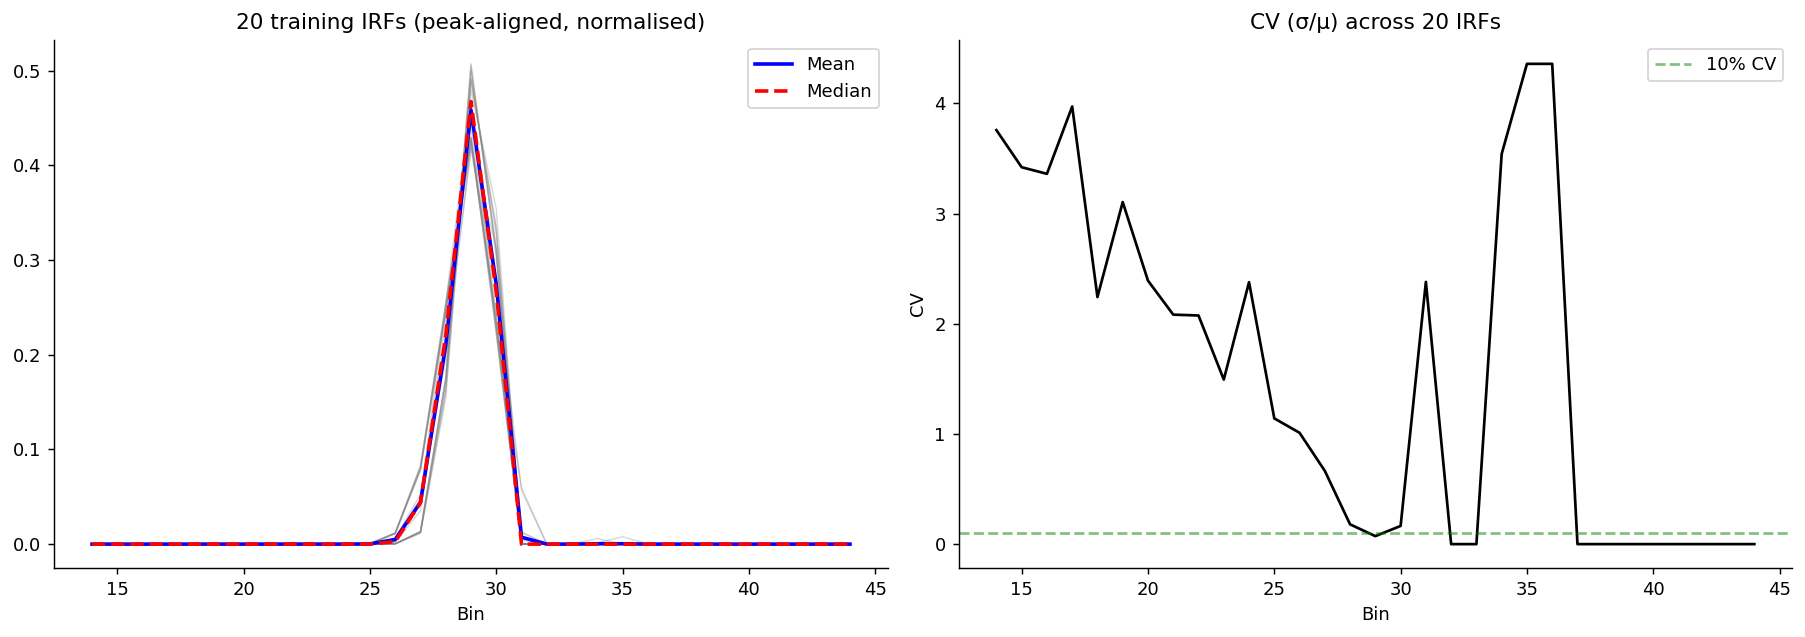


Machine IRF (median): FWHM = 2 bins = 0.194 ns
Peak at bin 29, common_nbins=526
Peak value: 0.467482
Non-zero bins: 13


In [53]:
# ── Build machine IRF: peak-align and average the 20 training xlsx IRFs ────────
from flimkit.utils.xlsx_tools import load_xlsx
from flimkit.FLIM.irf_tools import irf_from_xlsx
from flimkit.PTU.reader import PTUFile

# Extract all training IRFs with metadata
train_irfs_raw = []
train_peaks = []
train_meta = []  # (nbins, tres, name)

for name, ptu_path, xlsx_path, fit_path in train_pairs:
    ptu_f = PTUFile(str(ptu_path), verbose=False)
    nbins = ptu_f.n_bins
    tres  = ptu_f.tcspc_res
    xlsx_data = load_xlsx(str(xlsx_path))
    irf = irf_from_xlsx(xlsx_data, nbins, tres)
    pk  = np.argmax(irf)
    train_irfs_raw.append(irf)
    train_peaks.append(pk)
    train_meta.append((nbins, tres, name))

unique_nbins = sorted(set(m[0] for m in train_meta))
print(f"Training IRFs extracted: n={len(train_irfs_raw)}")
print(f"Peak positions: {train_peaks}")
print(f"Unique n_bins: {unique_nbins}")

# Use the smallest n_bins as common length (truncate longer ones)
common_nbins = min(m[0] for m in train_meta)
print(f"Common n_bins (truncated): {common_nbins}")

# Truncate all to common length, then peak-align
truncated = [irf[:common_nbins] for irf in train_irfs_raw]
peaks_trunc = [np.argmax(irf) for irf in truncated]
median_peak = int(np.median(peaks_trunc))

aligned_irfs = np.zeros((len(truncated), common_nbins))
for i, (irf, pk) in enumerate(zip(truncated, peaks_trunc)):
    shift = median_peak - pk
    aligned_irfs[i] = np.roll(irf, shift)

# Average (median for robustness)
machine_irf_mean   = aligned_irfs.mean(axis=0)
machine_irf_median = np.median(aligned_irfs, axis=0)
machine_irf_mean   /= machine_irf_mean.sum()
machine_irf_median /= machine_irf_median.sum()

# Visualize — zoom to ±15 bins around peak (IRF is very narrow)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

hw = 15  # half-window
lo_bin = max(0, median_peak - hw)
hi_bin = min(common_nbins, median_peak + hw + 1)
x_bins = np.arange(lo_bin, hi_bin)

for i, irf in enumerate(aligned_irfs):
    normed = irf / irf.sum() if irf.sum() > 0 else irf
    ax1.plot(x_bins, normed[lo_bin:hi_bin], alpha=0.3, color='gray', lw=0.8)
ax1.plot(x_bins, machine_irf_mean[lo_bin:hi_bin], 'b-', lw=2, label='Mean')
ax1.plot(x_bins, machine_irf_median[lo_bin:hi_bin], 'r--', lw=2, label='Median')
ax1.set_title(f'20 training IRFs (peak-aligned, normalised)')
ax1.set_xlabel('Bin')
ax1.legend()

irf_std = aligned_irfs.std(axis=0)
irf_cv  = np.divide(irf_std, machine_irf_mean, where=machine_irf_mean > 1e-10, out=np.zeros_like(irf_std))
ax2.plot(x_bins, irf_cv[lo_bin:hi_bin], 'k-', lw=1.5)
ax2.set_title('CV (σ/μ) across 20 IRFs')
ax2.set_xlabel('Bin')
ax2.set_ylabel('CV')
ax2.axhline(0.1, color='green', ls='--', alpha=0.5, label='10% CV')
ax2.legend()

plt.tight_layout()
plt.show()

tres_ref = train_meta[0][1]
above_half = machine_irf_median > (machine_irf_median.max() / 2)
fwhm_bins = above_half.sum()
print(f"\nMachine IRF (median): FWHM = {fwhm_bins} bins = {fwhm_bins * tres_ref * 1e9:.3f} ns")
print(f"Peak at bin {median_peak}, common_nbins={common_nbins}")
print(f"Peak value: {machine_irf_median.max():.6f}")
print(f"Non-zero bins: {(machine_irf_median > 0).sum()}")

In [54]:
# ── Test machine IRF on 6 held-out files ──────────────────────────────────────
# For each test file: fit with (1) machine IRF, (2) per-file Leica(interp) IRF
# Compare both against LAS X ground truth
import contextlib, io, time
from flimkit.FLIM.fitters import fit_summed
from flimkit.configs import Tau_min, Tau_max

test_results = []
for i, (name, ptu_path, xlsx_path, fit_path) in enumerate(test_pairs):
    print(f"[{i+1}/{len(test_pairs)}] {name}", end="", flush=True)
    t0 = time.time()

    ptu_f = PTUFile(str(ptu_path), verbose=False)
    dec   = ptu_f.summed_decay()
    tres  = ptu_f.tcspc_res
    nbins = ptu_f.n_bins
    xlsx_data = load_xlsx(str(xlsx_path))
    lasx = parse_lasx_fit(str(fit_path))
    lasx_taus = sorted(lasx['taus_ns'])

    row = dict(name=name,
               lasx_chi2=lasx['chi2'], lasx_tau_amp=lasx['tau_amp_ns'],
               lasx_tau_int=lasx['tau_int_ns'],
               lasx_tau1=lasx_taus[0], lasx_tau2=lasx_taus[1], lasx_tau3=lasx_taus[2])

    # ── Machine IRF (resize to match this file's nbins) ──────────────────────
    # Pad or truncate machine_irf_median to match nbins
    if nbins <= common_nbins:
        m_irf = machine_irf_median[:nbins].copy()
    else:
        m_irf = np.zeros(nbins)
        m_irf[:common_nbins] = machine_irf_median
    m_irf /= m_irf.sum()

    try:
        with contextlib.redirect_stdout(io.StringIO()):
            _, s_mi = fit_summed(dec, tres, nbins, m_irf,
                                 True, True, True, N_EXP, Tau_min, Tau_max,
                                 optimizer='de', de_popsize=30, de_maxiter=5000,
                                 workers=-1, polish=True, cost_function='poisson')
        m = extract_fit_metrics(s_mi)
        for k, v in m.items():
            row[f'mi_{k}'] = v
    except Exception as e:
        print(f" [machine ERR: {e}]", end="")

    # ── Leica (interp) per-file IRF ──────────────────────────────────────────
    try:
        irf_li = irf_from_xlsx(xlsx_data, nbins, tres)
        with contextlib.redirect_stdout(io.StringIO()):
            _, s_li = fit_summed(dec, tres, nbins, irf_li,
                                 True, True, True, N_EXP, Tau_min, Tau_max,
                                 optimizer='de', de_popsize=30, de_maxiter=5000,
                                 workers=-1, polish=True, cost_function='poisson')
        m = extract_fit_metrics(s_li)
        for k, v in m.items():
            row[f'li_{k}'] = v
    except Exception as e:
        print(f" [leica ERR: {e}]", end="")

    dt = time.time() - t0
    mi_chi2 = row.get('mi_chi2_r', np.nan)
    li_chi2 = row.get('li_chi2_r', np.nan)
    print(f"  LAS X={row['lasx_chi2']:.2f}  machine={mi_chi2:.2f}  leica(i)={li_chi2:.2f}  ({dt:.0f}s)")
    test_results.append(row)

print(f"\n✓ All {len(test_results)} test files processed")

[1/6] well2-FOV1-40xH2O    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 23 pts
    irf_c       : 23 pts
    fit_t       : 462 pts
    fit_c       : 462 pts
    res_t       : 462 pts
    res_c       : 462 pts
  LAS X=1.75  machine=9.24  leica(i)=5.87  (11s)
[2/6] Etr_Pom1_PSB_2    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 13 pts
    irf_c       : 13 pts
    fit_t       : 462 pts
    fit_c       : 462 pts
    res_t       : 520 pts
    res_c       : 462 pts
  LAS X=4.76  machine=5.91  leica(i)=4.73  (11s)
[3/6] Etr_Pom1_PSB_Ado_2    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 21 pts
    irf_c       : 21 pts
    fit_t       : 462 pts
    fit_c       : 462 pts
    res_t       : 520 pts
    res_c       : 462 pts
  LAS X=4.76  machine=11.88  leica(i)=7.92  (13s)
[4/6] Ado_1    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 14 pts
    irf_c       : 14 pts
    fit_t       : 520 pts
    fit_c       : absent
   

In [55]:
# ── Machine IRF vs Leica(interp) vs LAS X: test set comparison ────────────────
from scipy import stats

df_test = pd.DataFrame(test_results)

metrics_test = [
    ('χ²_r',   'lasx_chi2',    'mi_chi2_r',  'li_chi2_r'),
    ('τ_amp',  'lasx_tau_amp', 'mi_tau_amp',  'li_tau_amp'),
    ('τ_int',  'lasx_tau_int', 'mi_tau_int',  'li_tau_int'),
    ('τ₁',     'lasx_tau1',    'mi_tau1',     'li_tau1'),
    ('τ₂',     'lasx_tau2',    'mi_tau2',     'li_tau2'),
    ('τ₃',     'lasx_tau3',    'mi_tau3',     'li_tau3'),
]

# Per-file table
for metric_name, lasx_col, mi_col, li_col in metrics_test:
    print(f"\n{'═'*80}")
    print(f"  {metric_name}")
    print(f"{'═'*80}")
    print(f"{'Sample':<26} {'LAS X':>8} {'Machine':>8} {'Leica(i)':>8}  {'|Δ_mi|':>7} {'|Δ_li|':>7}  {'Win':>7}")
    print(f"{'─'*80}")
    for _, r in df_test.iterrows():
        ref = r.get(lasx_col, np.nan)
        mi  = r.get(mi_col, np.nan)
        li  = r.get(li_col, np.nan)
        d_mi = abs(mi - ref) if not (np.isnan(mi) or np.isnan(ref)) else np.nan
        d_li = abs(li - ref) if not (np.isnan(li) or np.isnan(ref)) else np.nan
        win = ""
        if not (np.isnan(d_mi) or np.isnan(d_li)):
            win = "MI" if d_mi < d_li else "LI"
        print(f"{r['name']:<26} {ref:>8.3f} {mi:>8.3f} {li:>8.3f}  {d_mi:>7.3f} {d_li:>7.3f}  {win:>7}")

# Summary
print(f"\n{'='*60}")
print(f"  SUMMARY (n={len(df_test)} test files)")
print(f"{'='*60}")
print(f"\n{'Metric':<10} {'Machine |Δ|':>12} {'Leica(i) |Δ|':>14}  {'Winner':>8}")
print("─" * 50)
for metric_name, lasx_col, mi_col, li_col in metrics_test:
    mi_d = (df_test[mi_col] - df_test[lasx_col]).abs().dropna()
    li_d = (df_test[li_col] - df_test[lasx_col]).abs().dropna()
    w = "Machine" if mi_d.mean() < li_d.mean() else "Leica(i)"
    print(f"{metric_name:<10} {mi_d.mean():>12.3f} {li_d.mean():>14.3f}  {w:>8}")

# Paired tests: Machine IRF vs LAS X
print(f"\n\nPaired tests — Machine IRF vs LAS X (n={len(df_test)}):")
print(f"{'Metric':<10} {'Mean diff':>10} {'t p-val':>12} {'Wilcoxon p':>12} {'Sig?':>6}")
print("─" * 55)
pairs_stat = [
    ('τ₁',    'lasx_tau1',    'mi_tau1'),
    ('τ₂',    'lasx_tau2',    'mi_tau2'),
    ('τ₃',    'lasx_tau3',    'mi_tau3'),
    ('τ_amp', 'lasx_tau_amp', 'mi_tau_amp'),
    ('τ_int', 'lasx_tau_int', 'mi_tau_int'),
]
for label, lx_col, mi_col in pairs_stat:
    lx_v = df_test[lx_col].values
    mi_v = df_test[mi_col].values
    diff = mi_v - lx_v
    t_stat, t_p = stats.ttest_rel(mi_v, lx_v)
    try:
        w_stat, w_p = stats.wilcoxon(diff)
    except ValueError:
        w_p = np.nan  # too few samples
    sig = "***" if t_p < 0.001 else "**" if t_p < 0.01 else "*" if t_p < 0.05 else "ns"
    print(f"{label:<10} {diff.mean():>10.4f} {t_p:>12.2e} {w_p:>12.2e} {sig:>6}")

# χ²_r comparison
mi_wins = (df_test['mi_chi2_r'] < df_test['li_chi2_r']).sum()
print(f"\nχ²_r: Machine wins {mi_wins}/{len(df_test)}, Leica(i) wins {len(df_test)-mi_wins}/{len(df_test)}")


════════════════════════════════════════════════════════════════════════════════
  χ²_r
════════════════════════════════════════════════════════════════════════════════
Sample                        LAS X  Machine Leica(i)   |Δ_mi|  |Δ_li|      Win
────────────────────────────────────────────────────────────────────────────────
well2-FOV1-40xH2O             1.753    9.235    5.871    7.482   4.118       LI
Etr_Pom1_PSB_2                4.756    5.912    4.733    1.156   0.023       LI
Etr_Pom1_PSB_Ado_2            4.759   11.875    7.917    7.116   3.158       LI
Ado_1                         2.993    4.721    3.477    1.728   0.484       LI
Dara_Ima_Ado_2                3.826    4.589    5.018    0.763   1.192       MI
well1-FOV1-20x                2.646    9.860   13.363    7.214  10.717       MI

════════════════════════════════════════════════════════════════════════════════
  τ_amp
════════════════════════════════════════════════════════════════════════════════
Sample            

In [56]:
# ── Compact summary for readability ───────────────────────────────────────────
print(f"TEST SET (n={len(df_test)}):\n")
print(f"{'Metric':<10} {'Machine |Δ|':>12} {'Leica(i) |Δ|':>14}  {'Winner':>8}")
print("─" * 50)
for metric_name, lasx_col, mi_col, li_col in metrics_test:
    mi_d = (df_test[mi_col] - df_test[lasx_col]).abs().dropna()
    li_d = (df_test[li_col] - df_test[lasx_col]).abs().dropna()
    w = "Machine" if mi_d.mean() < li_d.mean() else "Leica(i)"
    print(f"{metric_name:<10} {mi_d.mean():>12.3f} {li_d.mean():>14.3f}  {w:>8}")

print(f"\nPaired t-test (Machine vs LAS X):")
for label, lx_col, mi_col in pairs_stat:
    diff = df_test[mi_col].values - df_test[lx_col].values
    t_stat, t_p = stats.ttest_rel(df_test[mi_col].values, df_test[lx_col].values)
    sig = "ns" if t_p >= 0.05 else "*" if t_p >= 0.01 else "**" if t_p >= 0.001 else "***"
    print(f"  {label:<10} Δ={diff.mean():>+.4f} ns   p={t_p:.3f}  {sig}")

mi_w = (df_test['mi_chi2_r'] < df_test['li_chi2_r']).sum()
print(f"\nχ²_r: Machine wins {mi_w}/{len(df_test)}")

TEST SET (n=6):

Metric      Machine |Δ|   Leica(i) |Δ|    Winner
──────────────────────────────────────────────────
χ²_r              4.243          3.282  Leica(i)
τ_amp             0.478          0.374  Leica(i)
τ_int             1.085          1.247   Machine
τ₁                0.119          0.120   Machine
τ₂                1.120          1.131   Machine
τ₃                1.996          2.905   Machine

Paired t-test (Machine vs LAS X):
  τ₁         Δ=-0.1191 ns   p=0.000  ***
  τ₂         Δ=-0.8438 ns   p=0.054  ns
  τ₃         Δ=-1.3492 ns   p=0.192  ns
  τ_amp      Δ=-0.4775 ns   p=0.001  ***
  τ_int      Δ=-1.0848 ns   p=0.001  **

χ²_r: Machine wins 2/6


## Learn Leica IRF Placement From PTU-Only Features

Use the 20 training pairs to learn a PTU-only rule for where Leica would place the IRF. Then apply that learned rule to the held-out 6 files with no spreadsheet-derived timing.

In [57]:
# ── Landmark extraction and offset learning on the 20 training pairs ──────────
from scipy.ndimage import shift as nd_shift


def leading_edge_crossing(arr, frac=0.5):
    arr = np.asarray(arr, dtype=float)
    peak = int(np.argmax(arr))
    thr = float(arr[peak]) * frac
    above = np.where(arr[:peak + 1] >= thr)[0]
    return int(above[0]) if len(above) else 0


def max_slope_bin(arr):
    arr = np.asarray(arr, dtype=float)
    d = np.diff(arr)
    return int(np.argmax(d))


def onset_bin(arr, frac=0.1):
    arr = np.asarray(arr, dtype=float)
    peak = int(np.argmax(arr))
    thr = float(arr[peak]) * frac
    above = np.where(arr[:peak + 1] >= thr)[0]
    return int(above[0]) if len(above) else 0


def extract_landmarks(arr):
    arr = np.asarray(arr, dtype=float)
    arr = np.maximum(arr, 0)
    if arr.sum() > 0:
        arr = arr / arr.sum()
    return {
        'peak': int(np.argmax(arr)),
        'halfmax': leading_edge_crossing(arr, 0.5),
        'onset10': onset_bin(arr, 0.1),
        'slope': max_slope_bin(arr),
    }


def shift_irf_subbin(base_irf, nbins, shift_bins):
    arr = np.zeros(nbins, dtype=float)
    n = min(nbins, len(base_irf))
    arr[:n] = base_irf[:n]
    shifted = nd_shift(arr, shift=shift_bins, order=1, mode='constant', cval=0.0, prefilter=False)
    shifted = np.maximum(shifted, 0)
    s = shifted.sum()
    return shifted / s if s > 0 else shifted


# Machine IRF landmark positions in its own native grid
machine_marks = extract_landmarks(machine_irf_median)
print('Machine IRF landmarks:', machine_marks)

rows = []
for name, ptu_path, xlsx_path, fit_path in train_pairs:
    ptu_f = PTUFile(str(ptu_path), verbose=False)
    dec = ptu_f.summed_decay().astype(float)
    nbins = ptu_f.n_bins
    tres = ptu_f.tcspc_res
    xlsx_data = load_xlsx(str(xlsx_path))
    irf_li = irf_from_xlsx(xlsx_data, nbins, tres)

    dec_marks = extract_landmarks(dec)
    irf_marks = extract_landmarks(irf_li)

    row = {'name': name, 'nbins': nbins, 'tres_ns': tres * 1e9}
    for key, val in dec_marks.items():
        row[f'dec_{key}'] = val
    for key, val in irf_marks.items():
        row[f'irf_{key}'] = val
    for key in ['peak', 'halfmax', 'onset10', 'slope']:
        row[f'offset_{key}'] = irf_marks[key] - dec_marks[key]
    rows.append(row)

landmarks_train = pd.DataFrame(rows)
print(f"Training rows: {len(landmarks_train)}")
print(landmarks_train[['name', 'dec_peak', 'irf_peak', 'offset_peak', 'offset_halfmax', 'offset_onset10', 'offset_slope']].to_string(index=False))

# Constant-offset rules learned from training set
rule_rows = []
for key in ['peak', 'halfmax', 'onset10', 'slope']:
    offs = landmarks_train[f'offset_{key}'].values
    rule_rows.append({
        'rule': key,
        'mean_offset_bins': offs.mean(),
        'median_offset_bins': np.median(offs),
        'std_bins': offs.std(ddof=1),
        'min': offs.min(),
        'max': offs.max(),
    })
rules_df = pd.DataFrame(rule_rows).sort_values('std_bins')
print('\nOffset stability on training set:')
print(rules_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

Machine IRF landmarks: {'peak': 29, 'halfmax': 29, 'onset10': 28, 'slope': 28}
    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 21 pts
    irf_c       : 21 pts
    fit_t       : 462 pts
    fit_c       : 462 pts
    res_t       : 520 pts
    res_c       : 462 pts
    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 12 pts
    irf_c       : 12 pts
    fit_t       : 520 pts
    fit_c       : absent
    res_t       : 520 pts
    res_c       : absent
    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 22 pts
    irf_c       : 22 pts
    fit_t       : 520 pts
    fit_c       : absent
    res_t       : 520 pts
    res_c       : absent
    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 16 pts
    irf_c       : 16 pts
    fit_t       : 462 pts
    fit_c       : 462 pts
    res_t       : 462 pts
    res_c       : 462 pts
    decay_t     : 518 pts
    decay_c     : 518 pts
    irf_t       : 19 pts
    irf_c       : 19 pts

In [58]:
# ── Apply learned placement rules to the 6 test PTUs (no spreadsheet timing) ──
placement_results = []
rule_names = list(rules_df['rule'])

for name, ptu_path, xlsx_path, fit_path in test_pairs:
    ptu_f = PTUFile(str(ptu_path), verbose=False)
    dec = ptu_f.summed_decay().astype(float)
    nbins = ptu_f.n_bins
    tres = ptu_f.tcspc_res
    xlsx_data = load_xlsx(str(xlsx_path))
    irf_li = irf_from_xlsx(xlsx_data, nbins, tres)
    lasx = parse_lasx_fit(str(fit_path))
    lasx_taus = sorted(lasx['taus_ns'])
    dec_marks = extract_landmarks(dec)

    base = {
        'name': name,
        'lasx_chi2': lasx['chi2'],
        'lasx_tau_amp': lasx['tau_amp_ns'],
        'lasx_tau_int': lasx['tau_int_ns'],
        'lasx_tau1': lasx_taus[0],
        'lasx_tau2': lasx_taus[1],
        'lasx_tau3': lasx_taus[2],
    }

    # Leica fixed-shape baseline with no learned timing
    try:
        with contextlib.redirect_stdout(io.StringIO()):
            _, s_li_fix = fit_summed(dec, tres, nbins, irf_li,
                                     False, True, False,
                                     N_EXP, Tau_min, Tau_max,
                                     optimizer='de', de_popsize=30, de_maxiter=5000,
                                     workers=-1, polish=True, cost_function='poisson')
        for k, v in extract_fit_metrics(s_li_fix).items():
            base[f'li_fix_{k}'] = v
    except Exception as e:
        print(f'{name}: Leica fixed ERR: {e}')

    for rule in rule_names:
        row = dict(base)
        offset = float(rules_df.loc[rules_df['rule'] == rule, 'median_offset_bins'].iloc[0])
        predicted_anchor = dec_marks[rule] + offset
        shift_bins = predicted_anchor - machine_marks[rule]
        placed_irf = shift_irf_subbin(machine_irf_median, nbins, shift_bins)

        row['rule'] = rule
        row['pred_anchor'] = predicted_anchor
        row['shift_bins'] = shift_bins
        try:
            with contextlib.redirect_stdout(io.StringIO()):
                _, s_rule = fit_summed(dec, tres, nbins, placed_irf,
                                       False, True, False,
                                       N_EXP, Tau_min, Tau_max,
                                       optimizer='de', de_popsize=30, de_maxiter=5000,
                                       workers=-1, polish=True, cost_function='poisson')
            for k, v in extract_fit_metrics(s_rule).items():
                row[f'ptu_{k}'] = v
        except Exception as e:
            print(f'{name} / {rule}: PTU-rule ERR: {e}')
        placement_results.append(row)

placement_df = pd.DataFrame(placement_results)
print(f'Placement rows: {len(placement_df)}')
print(placement_df[['name', 'rule', 'shift_bins', 'lasx_chi2', 'ptu_chi2_r', 'li_fix_chi2_r']].to_string(index=False, float_format=lambda x: f'{x:.3f}'))

    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 23 pts
    irf_c       : 23 pts
    fit_t       : 462 pts
    fit_c       : 462 pts
    res_t       : 462 pts
    res_c       : 462 pts
    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 13 pts
    irf_c       : 13 pts
    fit_t       : 462 pts
    fit_c       : 462 pts
    res_t       : 520 pts
    res_c       : 462 pts
    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 21 pts
    irf_c       : 21 pts
    fit_t       : 462 pts
    fit_c       : 462 pts
    res_t       : 520 pts
    res_c       : 462 pts
    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 14 pts
    irf_c       : 14 pts
    fit_t       : 520 pts
    fit_c       : absent
    res_t       : 520 pts
    res_c       : absent
    decay_t     : 524 pts
    decay_c     : 524 pts
    irf_t       : 12 pts
    irf_c       : 12 pts
    fit_t       : 524 pts
    fit_c       : absent
    res_t       : 524 pts

In [59]:
# ── Summarize learned-placement performance on held-out files ─────────────────
summary_rows = []
for rule in rule_names:
    sdf = placement_df[placement_df['rule'] == rule]
    summary_rows.append({
        'rule': rule,
        'chi2_mean_abs_err': (sdf['ptu_chi2_r'] - sdf['lasx_chi2']).abs().mean(),
        'tau_amp_mean_abs_err': (sdf['ptu_tau_amp'] - sdf['lasx_tau_amp']).abs().mean(),
        'tau_int_mean_abs_err': (sdf['ptu_tau_int'] - sdf['lasx_tau_int']).abs().mean(),
        'tau1_mean_abs_err': (sdf['ptu_tau1'] - sdf['lasx_tau1']).abs().mean(),
        'tau2_mean_abs_err': (sdf['ptu_tau2'] - sdf['lasx_tau2']).abs().mean(),
        'tau3_mean_abs_err': (sdf['ptu_tau3'] - sdf['lasx_tau3']).abs().mean(),
        'chi2_wins_vs_li_fix': int((sdf['ptu_chi2_r'] < sdf['li_fix_chi2_r']).sum()),
    })
placement_summary = pd.DataFrame(summary_rows).sort_values(['tau_amp_mean_abs_err', 'chi2_mean_abs_err'])

print('Held-out test summary by learned placement rule:')
print(placement_summary.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

best_rule = placement_summary.iloc[0]['rule']
print(f"\nBest rule by τ_amp then χ²_r = {best_rule!r}")

best_df = placement_df[placement_df['rule'] == best_rule].copy()
print('\nPer-file results for best rule:')
print(best_df[['name', 'shift_bins', 'lasx_chi2', 'ptu_chi2_r', 'li_fix_chi2_r',
               'lasx_tau_amp', 'ptu_tau_amp', 'li_fix_tau_amp',
               'lasx_tau_int', 'ptu_tau_int', 'li_fix_tau_int']]
      .to_string(index=False, float_format=lambda x: f'{x:.3f}'))

Held-out test summary by learned placement rule:
   rule  chi2_mean_abs_err  tau_amp_mean_abs_err  tau_int_mean_abs_err  tau1_mean_abs_err  tau2_mean_abs_err  tau3_mean_abs_err  chi2_wins_vs_li_fix
   peak              3.325                 0.039                 0.025              0.024              0.085              0.112                    4
  slope              3.325                 0.039                 0.025              0.024              0.085              0.112                    4
halfmax              3.322                 0.039                 0.026              0.025              0.086              0.118                    4
onset10              3.323                 0.039                 0.028              0.025              0.096              0.138                    4

Best rule by τ_amp then χ²_r = 'peak'

Per-file results for best rule:
              name  shift_bins  lasx_chi2  ptu_chi2_r  li_fix_chi2_r  lasx_tau_amp  ptu_tau_amp  li_fix_tau_amp  lasx_tau_int  ptu_tau

In [60]:
# ── Compact training-rule summary ─────────────────────────────────────────────
print('Training offset rules (20 files):')
print(rules_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))
print(f"\nMachine landmarks: {machine_marks}")

Training offset rules (20 files):
   rule  mean_offset_bins  median_offset_bins  std_bins  min  max
   peak             0.000               0.000     0.000    0    0
  slope             1.000               1.000     0.000    1    1
halfmax             0.550               1.000     0.510    0    1
onset10             1.200               1.000     0.616    0    2

Machine landmarks: {'peak': 29, 'halfmax': 29, 'onset10': 28, 'slope': 28}


In [61]:
# ── Save machine IRF + metadata for reuse ─────────────────────────────────────
import json

out_npy = Path('machine_irf_median_20train.npy')
out_csv = Path('machine_irf_median_20train.csv')
out_meta = Path('machine_irf_median_20train_meta.json')

# Save IRF as .npy and .csv
np.save(out_npy, machine_irf_median.astype(np.float64))
np.savetxt(out_csv, machine_irf_median.astype(np.float64), delimiter=',')

meta = {
    'source': 'irf_reconstruction_validation.ipynb',
    'n_training_files': len(train_pairs),
    'training_files': [name for name, *_ in train_pairs],
    'common_nbins': int(common_nbins),
    'tcspc_res_ns': float(train_meta[0][1] * 1e9),
    'machine_landmarks': {k: int(v) for k, v in machine_marks.items()},
    'placement_rule': {
        'anchor': 'peak',
        'offset_bins': 0.0,
        'note': 'Learned from training pairs: IRF peak aligns with PTU decay peak.'
    }
}
out_meta.write_text(json.dumps(meta, indent=2))

print(f'Saved: {out_npy.resolve()}')
print(f'Saved: {out_csv.resolve()}')
print(f'Saved: {out_meta.resolve()}')

Saved: /Users/as-hunt/FLIMKit/machine_irf_median_20train.npy
Saved: /Users/as-hunt/FLIMKit/machine_irf_median_20train.csv
Saved: /Users/as-hunt/FLIMKit/machine_irf_median_20train_meta.json


In [62]:
# ── Empirical minimum N: subsampling stability study ──────────────────────────
# Question: how many pairs are needed before machine IRF + placement rule stabilizes?
import random

all_pairs = pairs_26[:]  # 26 complete pairs
N_total = len(all_pairs)

# Build helper maps once
pair_map = {name: (name, ptu_path, xlsx_path, fit_path) for name, ptu_path, xlsx_path, fit_path in all_pairs}


def build_machine_from_subset(subset_pairs):
    irfs = []
    nbs = []
    for name, ptu_path, xlsx_path, _ in subset_pairs:
        ptu_f = PTUFile(str(ptu_path), verbose=False)
        nbins = ptu_f.n_bins
        tres = ptu_f.tcspc_res
        xlsx_data = load_xlsx(str(xlsx_path))
        irf = irf_from_xlsx(xlsx_data, nbins, tres)
        irfs.append(irf)
        nbs.append(nbins)

    cnb = min(nbs)
    irfs = [v[:cnb] for v in irfs]
    pks = [int(np.argmax(v)) for v in irfs]
    pk_med = int(np.median(pks))
    aligned = np.zeros((len(irfs), cnb))
    for i, (v, p) in enumerate(zip(irfs, pks)):
        aligned[i] = np.roll(v, pk_med - p)

    mirf = np.median(aligned, axis=0)
    mirf = np.maximum(mirf, 0)
    mirf = mirf / mirf.sum()
    return mirf, cnb


def eval_subset(subset_names, test_names):
    subset_pairs = [pair_map[n] for n in subset_names]
    test_pairs_local = [pair_map[n] for n in test_names]

    mirf, cnb = build_machine_from_subset(subset_pairs)

    errs = []
    for name, ptu_path, xlsx_path, fit_path in test_pairs_local:
        ptu_f = PTUFile(str(ptu_path), verbose=False)
        dec = ptu_f.summed_decay().astype(float)
        nbins = ptu_f.n_bins
        tres = ptu_f.tcspc_res
        lasx = parse_lasx_fit(str(fit_path))

        # PTU-only placement rule learned above: align IRF peak to decay peak
        dec_peak = int(np.argmax(dec))
        mirf_peak = int(np.argmax(mirf))
        shift_bins = dec_peak - mirf_peak
        irf_use = shift_irf_subbin(mirf, nbins, shift_bins)

        with contextlib.redirect_stdout(io.StringIO()):
            _, s = fit_summed(dec, tres, nbins, irf_use,
                              False, True, False,
                              N_EXP, Tau_min, Tau_max,
                              optimizer='de', de_popsize=30, de_maxiter=3000,
                              workers=-1, polish=True, cost_function='poisson')

        errs.append({
            'chi2': abs(s['reduced_chi2'] - lasx['chi2']),
            'tau_amp': abs(s['tau_mean_amp_ns'] - lasx['tau_amp_ns']),
            'tau_int': abs(s['tau_mean_int_ns'] - lasx['tau_int_ns'])
        })

    d = pd.DataFrame(errs)
    return d.mean().to_dict()


# repeated random splits for each training N
random.seed(123)
ns = [4, 6, 8, 10, 12, 15, 18, 20]
reps = 5
rows = []
all_names = [n for n, *_ in all_pairs]

for n_train in ns:
    for rep in range(reps):
        train = random.sample(all_names, n_train)
        test = [n for n in all_names if n not in train]
        stats_mean = eval_subset(train, test)
        rows.append({
            'n_train': n_train,
            'rep': rep,
            'n_test': len(test),
            'chi2_mae': stats_mean['chi2'],
            'tau_amp_mae_ns': stats_mean['tau_amp'],
            'tau_int_mae_ns': stats_mean['tau_int'],
        })

stab = pd.DataFrame(rows)
summary = stab.groupby('n_train').agg(
    chi2_mae_mean=('chi2_mae', 'mean'),
    chi2_mae_sd=('chi2_mae', 'std'),
    tau_amp_mae_mean=('tau_amp_mae_ns', 'mean'),
    tau_amp_mae_sd=('tau_amp_mae_ns', 'std'),
    tau_int_mae_mean=('tau_int_mae_ns', 'mean'),
    tau_int_mae_sd=('tau_int_mae_ns', 'std'),
).reset_index()

print('Subsampling stability (mean across random splits):')
print(summary.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# practical minimum: first N where tau_amp and tau_int MAE plateau within 10% of N=20
ref = summary[summary['n_train'] == 20].iloc[0]
crit_amp = ref['tau_amp_mae_mean'] * 1.10
crit_int = ref['tau_int_mae_mean'] * 1.10
cand = summary[(summary['tau_amp_mae_mean'] <= crit_amp) & (summary['tau_int_mae_mean'] <= crit_int)]
if len(cand):
    n_min = int(cand.iloc[0]['n_train'])
    print(f"\nEstimated minimum practical N ≈ {n_min} pairs (within 10% of N=20 on weighted lifetimes).")
else:
    print('\nNo N met the 10% plateau criterion; use >=20 pairs.')

    decay_t     : 519 pts
    decay_c     : 519 pts
    irf_t       : 17 pts
    irf_c       : 17 pts
    fit_t       : 496 pts
    fit_c       : 496 pts
    res_t       : 519 pts
    res_c       : 496 pts
    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 21 pts
    irf_c       : 21 pts
    fit_t       : 462 pts
    fit_c       : 462 pts
    res_t       : 520 pts
    res_c       : 462 pts
    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 21 pts
    irf_c       : 21 pts
    fit_t       : 520 pts
    fit_c       : absent
    res_t       : 520 pts
    res_c       : absent
    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 15 pts
    irf_c       : 15 pts
    fit_t       : 462 pts
    fit_c       : 462 pts
    res_t       : 462 pts
    res_c       : 462 pts
    decay_t     : 518 pts
    decay_c     : 518 pts
    irf_t       : 19 pts
    irf_c       : 19 pts
    fit_t       : 462 pts
    fit_c       : 462 pts
    res_t       : 518 pt

In [63]:
# ── Compact output from subsampling study ─────────────────────────────────────
print(summary.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
ref = summary[summary['n_train'] == 20].iloc[0]
crit_amp = ref['tau_amp_mae_mean'] * 1.10
crit_int = ref['tau_int_mae_mean'] * 1.10
cand = summary[(summary['tau_amp_mae_mean'] <= crit_amp) & (summary['tau_int_mae_mean'] <= crit_int)]
if len(cand):
    print(f"\nEstimated minimum practical N: {int(cand.iloc[0]['n_train'])}")
else:
    print('\nEstimated minimum practical N: >=20')

 n_train  chi2_mae_mean  chi2_mae_sd  tau_amp_mae_mean  tau_amp_mae_sd  tau_int_mae_mean  tau_int_mae_sd
       4         2.6577       2.6135            0.0378          0.0108            0.0173          0.0019
       6         3.0175       2.5631            0.0375          0.0092            0.0163          0.0029
       8         4.3880       2.6751            0.0546          0.0153            0.0190          0.0019
      10         3.7880       1.9556            0.0466          0.0134            0.0182          0.0051
      12         3.9433       3.1760            0.0560          0.0157            0.0156          0.0039
      15         4.6839       2.6759            0.0521          0.0178            0.0184          0.0025
      18         2.8496       0.3845            0.0425          0.0071            0.0201          0.0048
      20         3.1850       0.7601            0.0357          0.0195            0.0158          0.0052

Estimated minimum practical N: 4


In [64]:
# ── All 26 files: machine IRF (PTU-only placement) vs LAS X and Leica(i) ─────
all26_machine = []
for i, (name, ptu_path, xlsx_path, fit_path) in enumerate(pairs_26):
    print(f"[{i+1}/{len(pairs_26)}] {name}", end="", flush=True)
    t0 = time.time()

    ptu_f = PTUFile(str(ptu_path), verbose=False)
    dec = ptu_f.summed_decay().astype(float)
    nbins = ptu_f.n_bins
    tres = ptu_f.tcspc_res
    xlsx_data = load_xlsx(str(xlsx_path))
    lasx = parse_lasx_fit(str(fit_path))
    lasx_taus = sorted(lasx['taus_ns'])

    row = dict(
        name=name,
        lasx_chi2=lasx['chi2'],
        lasx_tau_amp=lasx['tau_amp_ns'],
        lasx_tau_int=lasx['tau_int_ns'],
        lasx_tau1=lasx_taus[0],
        lasx_tau2=lasx_taus[1],
        lasx_tau3=lasx_taus[2],
    )

    # PTU-only placement: align machine IRF peak to decay peak
    dec_peak = int(np.argmax(dec))
    mirf_peak = int(np.argmax(machine_irf_median))
    shift_bins = dec_peak - mirf_peak
    irf_m = shift_irf_subbin(machine_irf_median, nbins, shift_bins)
    row['machine_shift_bins'] = shift_bins

    try:
        with contextlib.redirect_stdout(io.StringIO()):
            _, s_m = fit_summed(dec, tres, nbins, irf_m,
                                False, True, False,
                                N_EXP, Tau_min, Tau_max,
                                optimizer='de', de_popsize=30, de_maxiter=5000,
                                workers=-1, polish=True, cost_function='poisson')
        m = extract_fit_metrics(s_m)
        for k, v in m.items():
            row[f'ma_{k}'] = v
    except Exception as e:
        print(f" [machine ERR: {e}]", end="")

    # Leica interp reference
    try:
        irf_li = irf_from_xlsx(xlsx_data, nbins, tres)
        with contextlib.redirect_stdout(io.StringIO()):
            _, s_li = fit_summed(dec, tres, nbins, irf_li,
                                 True, True, True,
                                 N_EXP, Tau_min, Tau_max,
                                 optimizer='de', de_popsize=30, de_maxiter=5000,
                                 workers=-1, polish=True, cost_function='poisson')
        m = extract_fit_metrics(s_li)
        for k, v in m.items():
            row[f'li_{k}'] = v
    except Exception as e:
        print(f" [leica ERR: {e}]", end="")

    dt = time.time() - t0
    print(f"  LAS X={row['lasx_chi2']:.2f}  machine={row.get('ma_chi2_r',np.nan):.2f}  leica={row.get('li_chi2_r',np.nan):.2f}  ({dt:.0f}s)")
    all26_machine.append(row)

print(f"\n✓ Completed {len(all26_machine)} files")

[1/26] Ado_1    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 14 pts
    irf_c       : 14 pts
    fit_t       : 520 pts
    fit_c       : absent
    res_t       : 520 pts
    res_c       : absent
  LAS X=2.99  machine=6.37  leica=3.48  (9s)
[2/26] Ctrl_1    decay_t     : 519 pts
    decay_c     : 519 pts
    irf_t       : 17 pts
    irf_c       : 17 pts
    fit_t       : 496 pts
    fit_c       : 496 pts
    res_t       : 519 pts
    res_c       : 496 pts
  LAS X=3.48  machine=4.69  leica=1.78  (10s)
[3/26] Dara_Ima_2    decay_t     : 520 pts
    decay_c     : 520 pts
    irf_t       : 21 pts
    irf_c       : 21 pts
    fit_t       : 520 pts
    fit_c       : absent
    res_t       : 520 pts
    res_c       : absent
  LAS X=3.64  machine=5.74  leica=4.67  (11s)
[4/26] Dara_Ima_Ado_2    decay_t     : 524 pts
    decay_c     : 524 pts
    irf_t       : 12 pts
    irf_c       : 12 pts
    fit_t       : 524 pts
    fit_c       : absent
    res_t       : 524 pts
    res

In [65]:
# ── Compact summary: all 26 files ─────────────────────────────────────────────
df26m = pd.DataFrame(all26_machine)

metrics26m = [
    ('χ²_r',   'lasx_chi2',    'ma_chi2_r',  'li_chi2_r'),
    ('τ_amp',  'lasx_tau_amp', 'ma_tau_amp', 'li_tau_amp'),
    ('τ_int',  'lasx_tau_int', 'ma_tau_int', 'li_tau_int'),
    ('τ₁',     'lasx_tau1',    'ma_tau1',    'li_tau1'),
    ('τ₂',     'lasx_tau2',    'ma_tau2',    'li_tau2'),
    ('τ₃',     'lasx_tau3',    'ma_tau3',    'li_tau3'),
]

print(f"ALL-26 summary (Machine IRF PTU-only placement)\n")
print(f"{'Metric':<10} {'Machine |Δ|':>12} {'Leica(i) |Δ|':>14}  {'Winner':>8}")
print('─' * 50)
for metric, ref, ma, li in metrics26m:
    ma_d = (df26m[ma] - df26m[ref]).abs().dropna()
    li_d = (df26m[li] - df26m[ref]).abs().dropna()
    w = 'Machine' if ma_d.mean() < li_d.mean() else 'Leica(i)'
    print(f"{metric:<10} {ma_d.mean():>12.3f} {li_d.mean():>14.3f}  {w:>8}")

print('\nPer-file χ² wins:')
ma_w = (df26m['ma_chi2_r'] < df26m['li_chi2_r']).sum()
print(f"  Machine wins {ma_w}/{len(df26m)}, Leica(i) wins {len(df26m)-ma_w}/{len(df26m)}")

print('\nMachine vs LAS X absolute errors (all 26):')
for metric, ref, ma, _ in metrics26m:
    d = (df26m[ma] - df26m[ref]).abs().dropna()
    print(f"  {metric:<8} mean={d.mean():.3f}  median={d.median():.3f}  max={d.max():.3f}")

# Optional: export
out_all26 = Path('machine_irf_all26_comparison.csv')
df26m.to_csv(out_all26, index=False)
print(f"\nSaved comparison table: {out_all26.resolve()}")

ALL-26 summary (Machine IRF PTU-only placement)

Metric      Machine |Δ|   Leica(i) |Δ|    Winner
──────────────────────────────────────────────────
χ²_r              2.595          2.047  Leica(i)
τ_amp             0.044          0.457   Machine
τ_int             0.020          1.267   Machine
τ₁                0.027          0.119   Machine
τ₂                0.093          1.182   Machine
τ₃                0.116          2.668   Machine

Per-file χ² wins:
  Machine wins 8/26, Leica(i) wins 18/26

Machine vs LAS X absolute errors (all 26):
  χ²_r     mean=2.595  median=2.848  max=5.613
  τ_amp    mean=0.044  median=0.027  max=0.178
  τ_int    mean=0.020  median=0.015  max=0.059
  τ₁       mean=0.027  median=0.019  max=0.083
  τ₂       mean=0.093  median=0.071  max=0.351
  τ₃       mean=0.116  median=0.076  max=0.418

Saved comparison table: /Users/as-hunt/FLIMKit/machine_irf_all26_comparison.csv


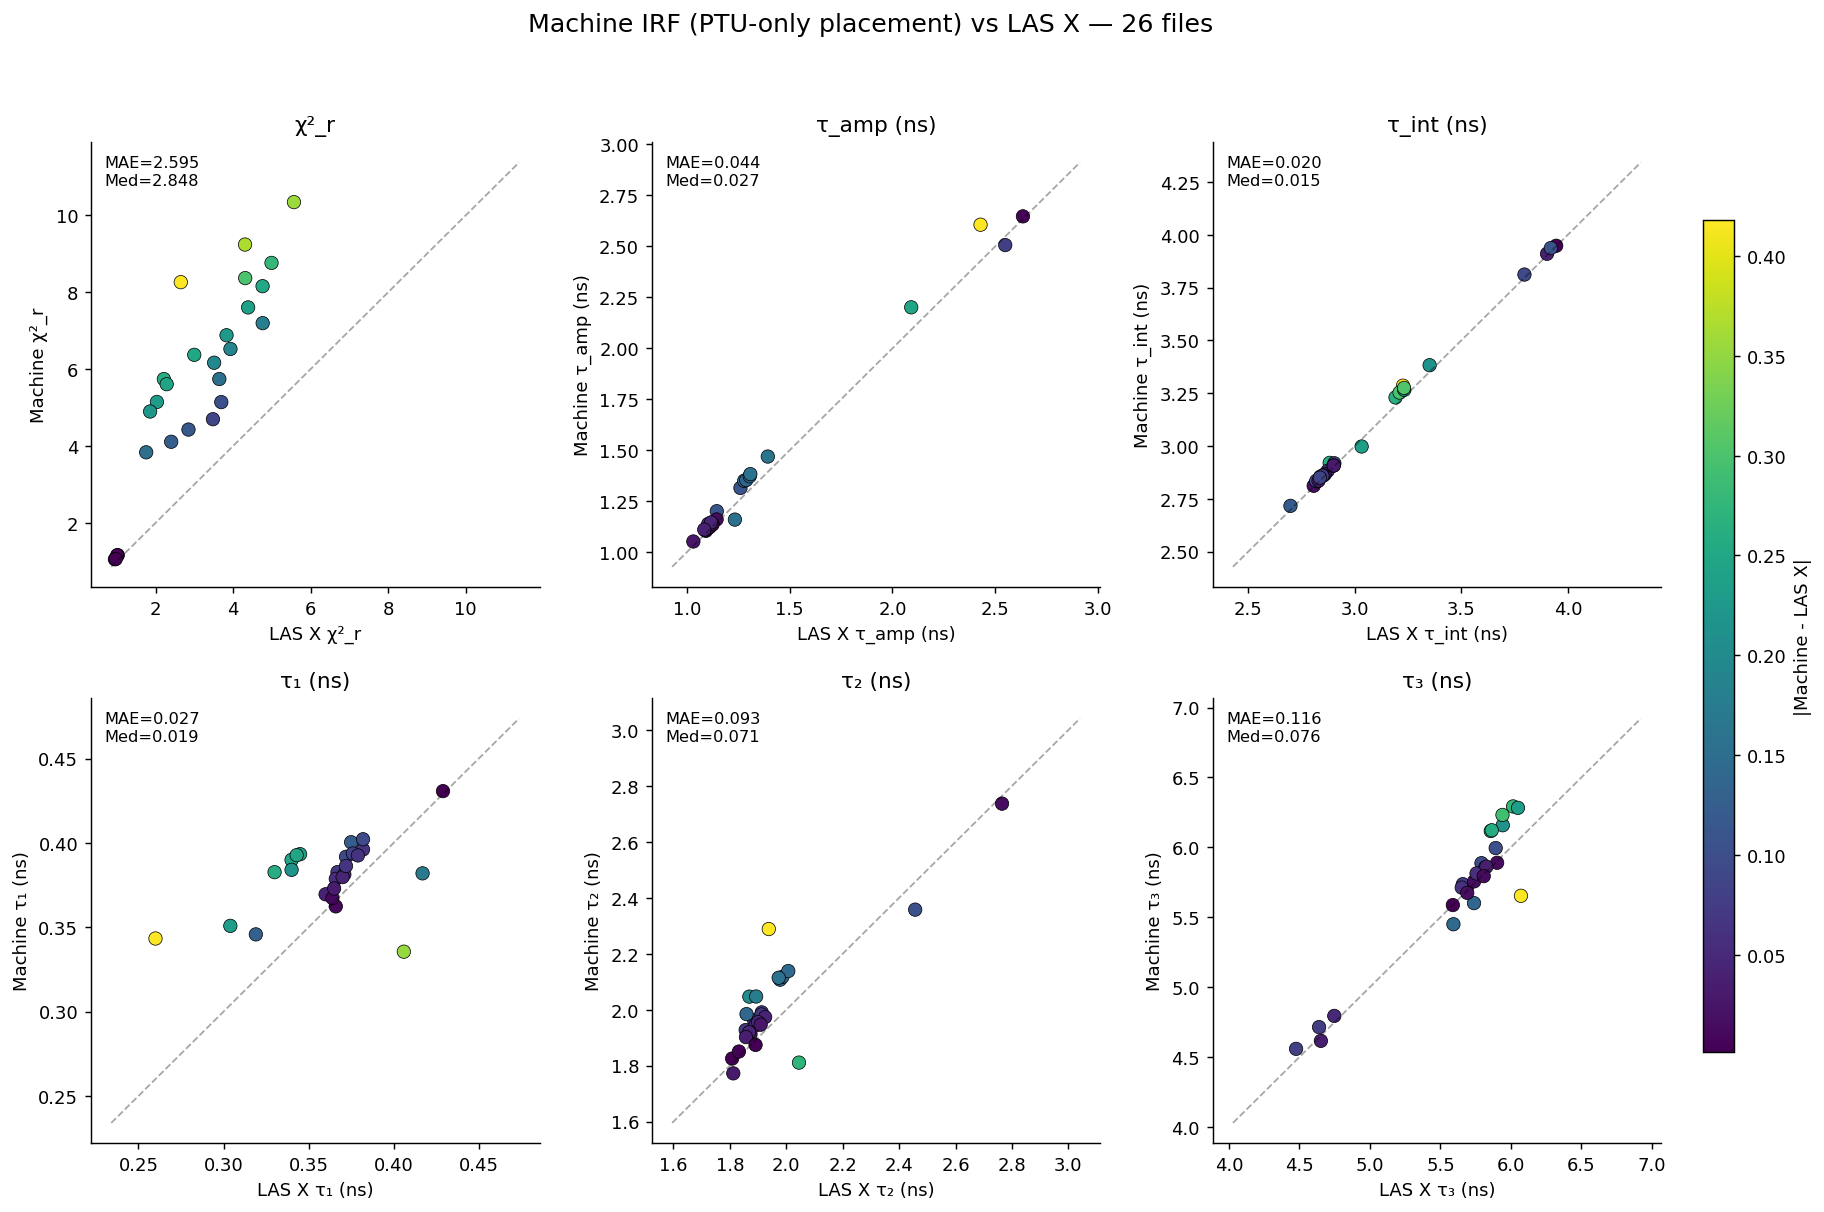

In [67]:
# ── Visual: all-26 metric scatter vs identity diagonal (Machine vs LAS X) ─────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Machine IRF (PTU-only placement) vs LAS X — 26 files', fontsize=14, y=0.98)

plot_specs_m = [
    ('χ²_r', 'lasx_chi2', 'ma_chi2_r'),
    ('τ_amp (ns)', 'lasx_tau_amp', 'ma_tau_amp'),
    ('τ_int (ns)', 'lasx_tau_int', 'ma_tau_int'),
    ('τ₁ (ns)', 'lasx_tau1', 'ma_tau1'),
    ('τ₂ (ns)', 'lasx_tau2', 'ma_tau2'),
    ('τ₃ (ns)', 'lasx_tau3', 'ma_tau3'),
]

sc = None
for ax, (label, xcol, ycol) in zip(axes.flat, plot_specs_m):
    x = df26m[xcol].values
    y = df26m[ycol].values
    d = np.abs(y - x)

    lo = min(np.nanmin(x), np.nanmin(y)) * 0.9
    hi = max(np.nanmax(x), np.nanmax(y)) * 1.1
    if lo == hi:
        lo, hi = lo - 1, hi + 1

    # Identity diagonal
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.35, lw=1)

    # Points colored by absolute error magnitude
    sc = ax.scatter(x, y, c=d, cmap='viridis', s=55, edgecolors='k', linewidths=0.4)

    mae = np.nanmean(d)
    med = np.nanmedian(d)
    ax.text(0.03, 0.97, f"MAE={mae:.3f}\nMed={med:.3f}", transform=ax.transAxes,
            va='top', ha='left', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.75, ec='none'))

    ax.set_xlabel(f'LAS X {label}')
    ax.set_ylabel(f'Machine {label}')
    ax.set_title(label)

# Leave room on the right and place colorbar outside the plot grid
fig.subplots_adjust(right=0.88, wspace=0.25, hspace=0.25)
cax = fig.add_axes([0.90, 0.18, 0.015, 0.64])
cbar = fig.colorbar(sc, cax=cax)
cbar.set_label('|Machine - LAS X|')

plt.show()

In [68]:
# ── Strategy comparison: improve χ² vs preserve lifetime accuracy (all 26) ─────
# We compare machine-IRF fitting variants and report MAE vs LAS X for all metrics.
strategy_rows = []

for i, (name, ptu_path, xlsx_path, fit_path) in enumerate(pairs_26):
    print(f"[{i+1}/{len(pairs_26)}] {name}")

    ptu_f = PTUFile(str(ptu_path), verbose=False)
    dec = ptu_f.summed_decay().astype(float)
    nbins = ptu_f.n_bins
    tres = ptu_f.tcspc_res

    with contextlib.redirect_stdout(io.StringIO()):
        xlsx_data = load_xlsx(str(xlsx_path))
    lasx = parse_lasx_fit(str(fit_path))
    lasx_taus = sorted(lasx['taus_ns'])

    base = {
        'name': name,
        'lasx_chi2': lasx['chi2'],
        'lasx_tau_amp': lasx['tau_amp_ns'],
        'lasx_tau_int': lasx['tau_int_ns'],
        'lasx_tau1': lasx_taus[0],
        'lasx_tau2': lasx_taus[1],
        'lasx_tau3': lasx_taus[2],
    }

    # PTU-only placement of machine IRF
    dec_peak = int(np.argmax(dec))
    mirf_peak = int(np.argmax(machine_irf_median))
    shift_bins = dec_peak - mirf_peak
    irf_m = shift_irf_subbin(machine_irf_median, nbins, shift_bins)

    # Leica interp reference (as before)
    try:
        irf_li = irf_from_xlsx(xlsx_data, nbins, tres)
        with contextlib.redirect_stdout(io.StringIO()):
            _, s_li = fit_summed(dec, tres, nbins, irf_li,
                                 True, True, True,
                                 N_EXP, Tau_min, Tau_max,
                                 optimizer='de', de_popsize=30, de_maxiter=5000,
                                 workers=-1, polish=True, cost_function='poisson')
        row = dict(base, strategy='leica_interp')
        row.update({
            'chi2': s_li['reduced_chi2'],
            'tau_amp': s_li['tau_mean_amp_ns'],
            'tau_int': s_li['tau_mean_int_ns'],
            'tau1': sorted(s_li['taus_ns'])[0],
            'tau2': sorted(s_li['taus_ns'])[1],
            'tau3': sorted(s_li['taus_ns'])[2],
        })
        strategy_rows.append(row)
    except Exception:
        pass

    # Strategy A: machine fixed shape (current best lifetime accuracy)
    try:
        with contextlib.redirect_stdout(io.StringIO()):
            _, s_a = fit_summed(dec, tres, nbins, irf_m,
                                False, True, False,
                                N_EXP, Tau_min, Tau_max,
                                optimizer='de', de_popsize=30, de_maxiter=5000,
                                workers=-1, polish=True, cost_function='poisson')
        row = dict(base, strategy='machine_fixed')
        row.update({
            'chi2': s_a['reduced_chi2'],
            'tau_amp': s_a['tau_mean_amp_ns'],
            'tau_int': s_a['tau_mean_int_ns'],
            'tau1': sorted(s_a['taus_ns'])[0],
            'tau2': sorted(s_a['taus_ns'])[1],
            'tau3': sorted(s_a['taus_ns'])[2],
        })
        strategy_rows.append(row)
    except Exception:
        pass

    # Strategy B: machine + fit sigma (allow slight broadening)
    try:
        with contextlib.redirect_stdout(io.StringIO()):
            _, s_b = fit_summed(dec, tres, nbins, irf_m,
                                False, True, True,
                                N_EXP, Tau_min, Tau_max,
                                optimizer='de', de_popsize=30, de_maxiter=5000,
                                workers=-1, polish=True, cost_function='poisson')
        row = dict(base, strategy='machine_sigma')
        row.update({
            'chi2': s_b['reduced_chi2'],
            'tau_amp': s_b['tau_mean_amp_ns'],
            'tau_int': s_b['tau_mean_int_ns'],
            'tau1': sorted(s_b['taus_ns'])[0],
            'tau2': sorted(s_b['taus_ns'])[1],
            'tau3': sorted(s_b['taus_ns'])[2],
        })
        strategy_rows.append(row)
    except Exception:
        pass

    # Strategy C: machine + sigma + tail (max flexibility)
    try:
        with contextlib.redirect_stdout(io.StringIO()):
            _, s_c = fit_summed(dec, tres, nbins, irf_m,
                                True, True, True,
                                N_EXP, Tau_min, Tau_max,
                                optimizer='de', de_popsize=30, de_maxiter=5000,
                                workers=-1, polish=True, cost_function='poisson')
        row = dict(base, strategy='machine_sigma_tail')
        row.update({
            'chi2': s_c['reduced_chi2'],
            'tau_amp': s_c['tau_mean_amp_ns'],
            'tau_int': s_c['tau_mean_int_ns'],
            'tau1': sorted(s_c['taus_ns'])[0],
            'tau2': sorted(s_c['taus_ns'])[1],
            'tau3': sorted(s_c['taus_ns'])[2],
        })
        strategy_rows.append(row)
    except Exception:
        pass

strategy_df = pd.DataFrame(strategy_rows)

# MAE summary vs LAS X
summary_rows = []
for strat, g in strategy_df.groupby('strategy'):
    summary_rows.append({
        'strategy': strat,
        'n': len(g),
        'chi2_mae': (g['chi2'] - g['lasx_chi2']).abs().mean(),
        'tau_amp_mae_ns': (g['tau_amp'] - g['lasx_tau_amp']).abs().mean(),
        'tau_int_mae_ns': (g['tau_int'] - g['lasx_tau_int']).abs().mean(),
        'tau1_mae_ns': (g['tau1'] - g['lasx_tau1']).abs().mean(),
        'tau2_mae_ns': (g['tau2'] - g['lasx_tau2']).abs().mean(),
        'tau3_mae_ns': (g['tau3'] - g['lasx_tau3']).abs().mean(),
    })

strategy_summary = pd.DataFrame(summary_rows).sort_values('chi2_mae')
print("\nStrategy MAE vs LAS X (lower is better):")
print(strategy_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# show tradeoff ranking
print("\nRank by χ² MAE:")
for i, r in strategy_summary.reset_index(drop=True).iterrows():
    print(f"  {i+1}. {r['strategy']}  χ²_MAE={r['chi2_mae']:.3f}, "
          f"τ_amp_MAE={r['tau_amp_mae_ns']:.3f}, τ_int_MAE={r['tau_int_mae_ns']:.3f}")

[1/26] Ado_1
[2/26] Ctrl_1
[3/26] Dara_Ima_2
[4/26] Dara_Ima_Ado_2
[5/26] Daratumab_1
[6/26] Daratumab_Ado_1
[7/26] Daratumab_Ado_2
[8/26] Etr_Pom1_PSB_2
[9/26] Etr_Pom1_PSB_Ado_2
[10/26] Etrumadenant_1
[11/26] Etrumadenant_Ado_2
[12/26] Imaradenant_2
[13/26] Imaradenant_Ado_2
[14/26] PBMCs-well2-untreated-FOV1
[15/26] PSB12379_1
[16/26] PSB12379_Ado_1
[17/26] Pom1_2
[18/26] Tcells-well1-untreated-FOV1
[19/26] Tcells-well2-untreated-FOV1
[20/26] Tcells-well2-untreated-FOV5
[21/26] well1-FOV1-20x
[22/26] well2-FOV1-40xH2O
[23/26] well4-FOV1-40x-ado-t0
[24/26] well4-FOV1-40x-ado-t20
[25/26] well4-FOV1-40x-ado-t40
[26/26] well4-FOV1-40x-ado-t60

Strategy MAE vs LAS X (lower is better):
          strategy  n  chi2_mae  tau_amp_mae_ns  tau_int_mae_ns  tau1_mae_ns  tau2_mae_ns  tau3_mae_ns
     machine_sigma 26    0.6220          0.0710          0.0159       0.0556       0.1625       0.2009
      leica_interp 26    2.0474          0.4572          1.2665       0.1187       1.1815       2.6680

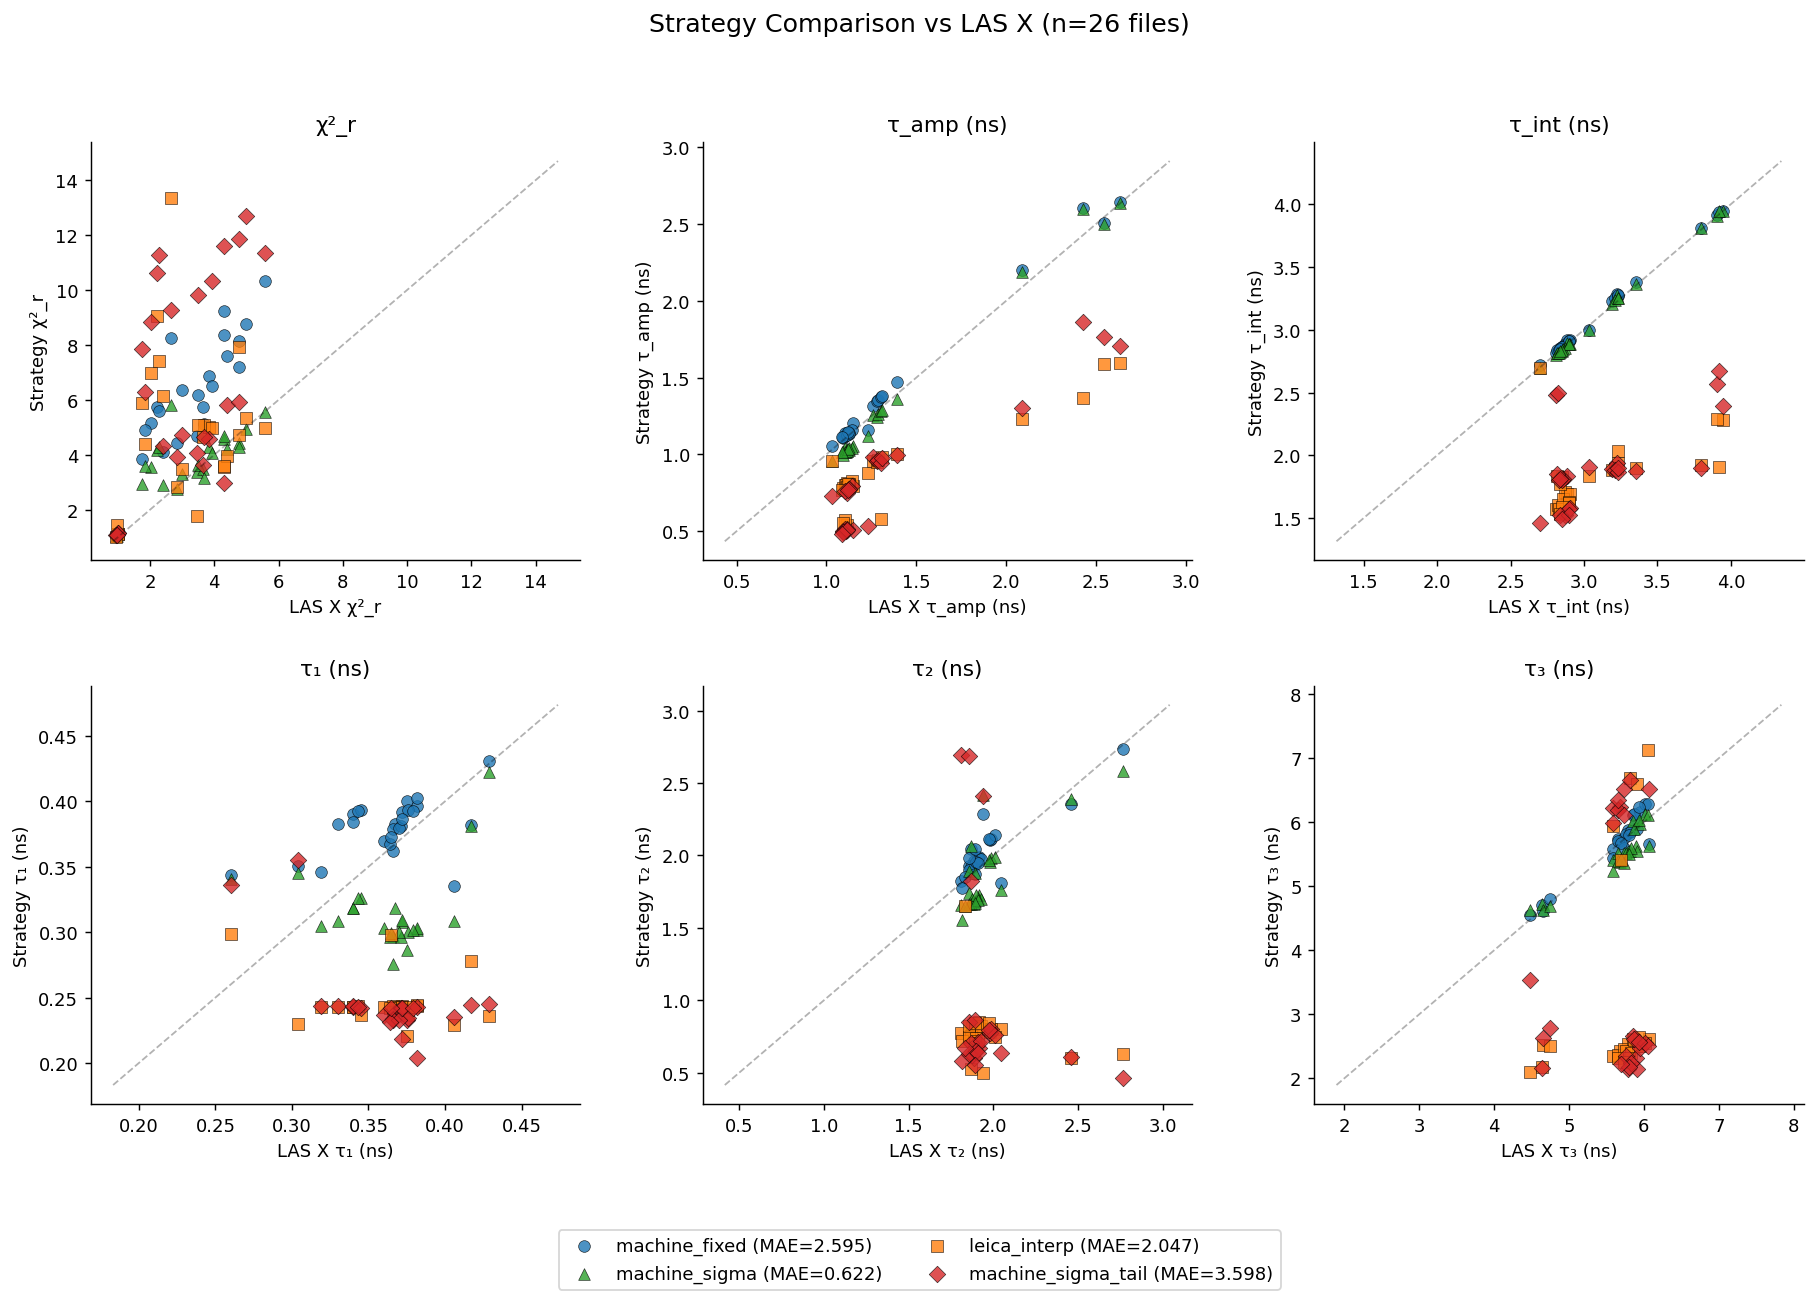

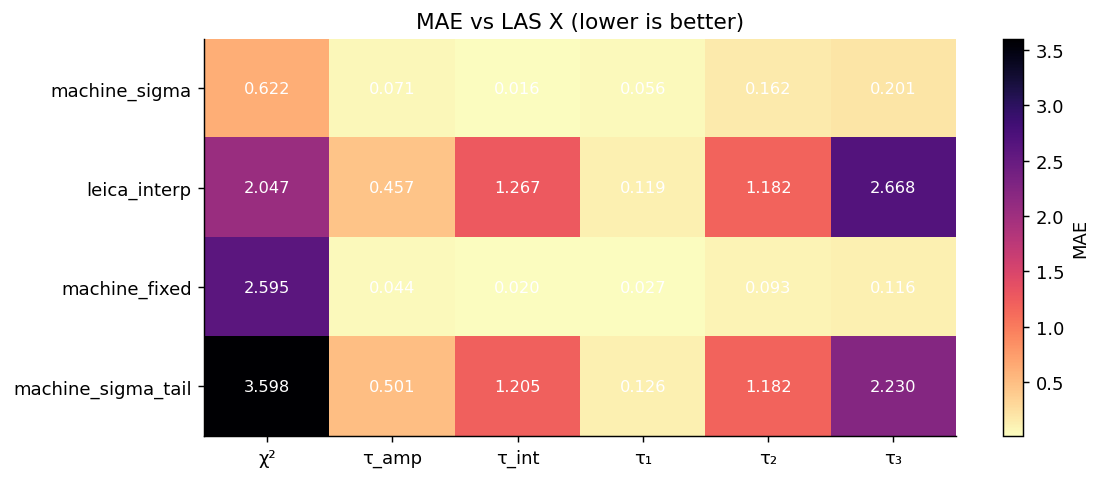

In [69]:
# ── Visualize strategy tradeoffs vs LAS X (all 26 files) ──────────────────────
# Strategy scatter panels
strategies_plot = ['machine_fixed', 'machine_sigma', 'leica_interp', 'machine_sigma_tail']
colors = {
    'machine_fixed': 'tab:blue',
    'machine_sigma': 'tab:green',
    'leica_interp': 'tab:orange',
    'machine_sigma_tail': 'tab:red',
}
markers = {
    'machine_fixed': 'o',
    'machine_sigma': '^',
    'leica_interp': 's',
    'machine_sigma_tail': 'D',
}

metrics_plot = [
    ('χ²_r', 'lasx_chi2', 'chi2'),
    ('τ_amp (ns)', 'lasx_tau_amp', 'tau_amp'),
    ('τ_int (ns)', 'lasx_tau_int', 'tau_int'),
    ('τ₁ (ns)', 'lasx_tau1', 'tau1'),
    ('τ₂ (ns)', 'lasx_tau2', 'tau2'),
    ('τ₃ (ns)', 'lasx_tau3', 'tau3'),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Strategy Comparison vs LAS X (n=26 files)', fontsize=14, y=0.98)

for ax, (label, ref_col, y_col) in zip(axes.flat, metrics_plot):
    # gather bounds across all strategies
    all_x, all_y = [], []
    for strat in strategies_plot:
        g = strategy_df[strategy_df['strategy'] == strat]
        all_x.extend(g[ref_col].values.tolist())
        all_y.extend(g[y_col].values.tolist())

    lo = min(np.nanmin(all_x), np.nanmin(all_y)) * 0.9
    hi = max(np.nanmax(all_x), np.nanmax(all_y)) * 1.1
    if lo == hi:
        lo, hi = lo - 1, hi + 1
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.3, lw=1)

    for strat in strategies_plot:
        g = strategy_df[strategy_df['strategy'] == strat]
        d = np.abs(g[y_col].values - g[ref_col].values)
        ax.scatter(g[ref_col].values, g[y_col].values,
                   s=42, alpha=0.8, c=colors[strat], marker=markers[strat],
                   edgecolors='k', linewidths=0.35,
                   label=f"{strat} (MAE={d.mean():.3f})")

    ax.set_xlabel(f'LAS X {label}')
    ax.set_ylabel(f'Strategy {label}')
    ax.set_title(label)

# single legend for all panels
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, frameon=True, bbox_to_anchor=(0.5, -0.01))
fig.subplots_adjust(bottom=0.14, wspace=0.25, hspace=0.30)
plt.show()

# MAE heatmap for quick ranking
heat = strategy_summary.set_index('strategy')[['chi2_mae', 'tau_amp_mae_ns', 'tau_int_mae_ns',
                                               'tau1_mae_ns', 'tau2_mae_ns', 'tau3_mae_ns']]

fig, ax = plt.subplots(figsize=(9, 3.8))
im = ax.imshow(heat.values, aspect='auto', cmap='magma_r')
ax.set_xticks(np.arange(heat.shape[1]))
ax.set_xticklabels(['χ²', 'τ_amp', 'τ_int', 'τ₁', 'τ₂', 'τ₃'])
ax.set_yticks(np.arange(heat.shape[0]))
ax.set_yticklabels(heat.index.tolist())
ax.set_title('MAE vs LAS X (lower is better)')

# annotate values
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f"{heat.values[i, j]:.3f}", ha='center', va='center', color='white', fontsize=9)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('MAE')
plt.tight_layout()
plt.show()

In [70]:
# ── Intermediate technique: adaptive fixed-vs-sigma chooser ───────────────────
# Choose machine_sigma only when it improves chi2 enough; otherwise keep machine_fixed.
base_cols = ['name', 'lasx_chi2', 'lasx_tau_amp', 'lasx_tau_int', 'lasx_tau1', 'lasx_tau2', 'lasx_tau3',
             'chi2', 'tau_amp', 'tau_int', 'tau1', 'tau2', 'tau3']

fx = strategy_df[strategy_df['strategy'] == 'machine_fixed'][base_cols].copy()
sg = strategy_df[strategy_df['strategy'] == 'machine_sigma'][base_cols].copy()

fx = fx.rename(columns={'chi2':'fx_chi2','tau_amp':'fx_tau_amp','tau_int':'fx_tau_int',
                        'tau1':'fx_tau1','tau2':'fx_tau2','tau3':'fx_tau3'})
sg = sg.rename(columns={'chi2':'sg_chi2','tau_amp':'sg_tau_amp','tau_int':'sg_tau_int',
                        'tau1':'sg_tau1','tau2':'sg_tau2','tau3':'sg_tau3'})

cmp = fx.merge(sg[['name','sg_chi2','sg_tau_amp','sg_tau_int','sg_tau1','sg_tau2','sg_tau3']], on='name', how='inner')
cmp['delta_chi2'] = cmp['fx_chi2'] - cmp['sg_chi2']

thresholds = [0.00, 0.10, 0.25, 0.50, 1.00]
rows = []
for thr in thresholds:
    choose_sigma = cmp['delta_chi2'] >= thr
    out = cmp.copy()
    for m in ['chi2','tau_amp','tau_int','tau1','tau2','tau3']:
        out[f'hy_{m}'] = np.where(choose_sigma, out[f'sg_{m}'], out[f'fx_{m}'])

    rows.append({
        'threshold': thr,
        'use_sigma_count': int(choose_sigma.sum()),
        'chi2_mae': (out['hy_chi2'] - out['lasx_chi2']).abs().mean(),
        'tau_amp_mae': (out['hy_tau_amp'] - out['lasx_tau_amp']).abs().mean(),
        'tau_int_mae': (out['hy_tau_int'] - out['lasx_tau_int']).abs().mean(),
        'tau1_mae': (out['hy_tau1'] - out['lasx_tau1']).abs().mean(),
        'tau2_mae': (out['hy_tau2'] - out['lasx_tau2']).abs().mean(),
        'tau3_mae': (out['hy_tau3'] - out['lasx_tau3']).abs().mean(),
    })

hyb = pd.DataFrame(rows)
print('Adaptive hybrid (machine_fixed vs machine_sigma):')
print(hyb.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Compare against endpoints for context
print('\nEndpoints:')
for strat in ['machine_fixed', 'machine_sigma']:
    g = strategy_df[strategy_df['strategy'] == strat]
    print(f"{strat:>14}: χ²={((g['chi2']-g['lasx_chi2']).abs().mean()):.4f}, "
          f"τ_amp={((g['tau_amp']-g['lasx_tau_amp']).abs().mean()):.4f}, "
          f"τ_int={((g['tau_int']-g['lasx_tau_int']).abs().mean()):.4f}")

Adaptive hybrid (machine_fixed vs machine_sigma):
 threshold  use_sigma_count  chi2_mae  tau_amp_mae  tau_int_mae  tau1_mae  tau2_mae  tau3_mae
    0.0000               23    0.6216       0.0718       0.0160    0.0556    0.1571    0.2007
    0.1000               22    0.6219       0.0721       0.0158    0.0557    0.1520    0.1981
    0.2500               22    0.6219       0.0721       0.0158    0.0557    0.1520    0.1981
    0.5000               22    0.6219       0.0721       0.0158    0.0557    0.1520    0.1981
    1.0000               21    0.6565       0.0738       0.0164    0.0568    0.1561    0.2050

Endpoints:
 machine_fixed: χ²=2.5955, τ_amp=0.0441, τ_int=0.0197
 machine_sigma: χ²=0.6220, τ_amp=0.0710, τ_int=0.0159


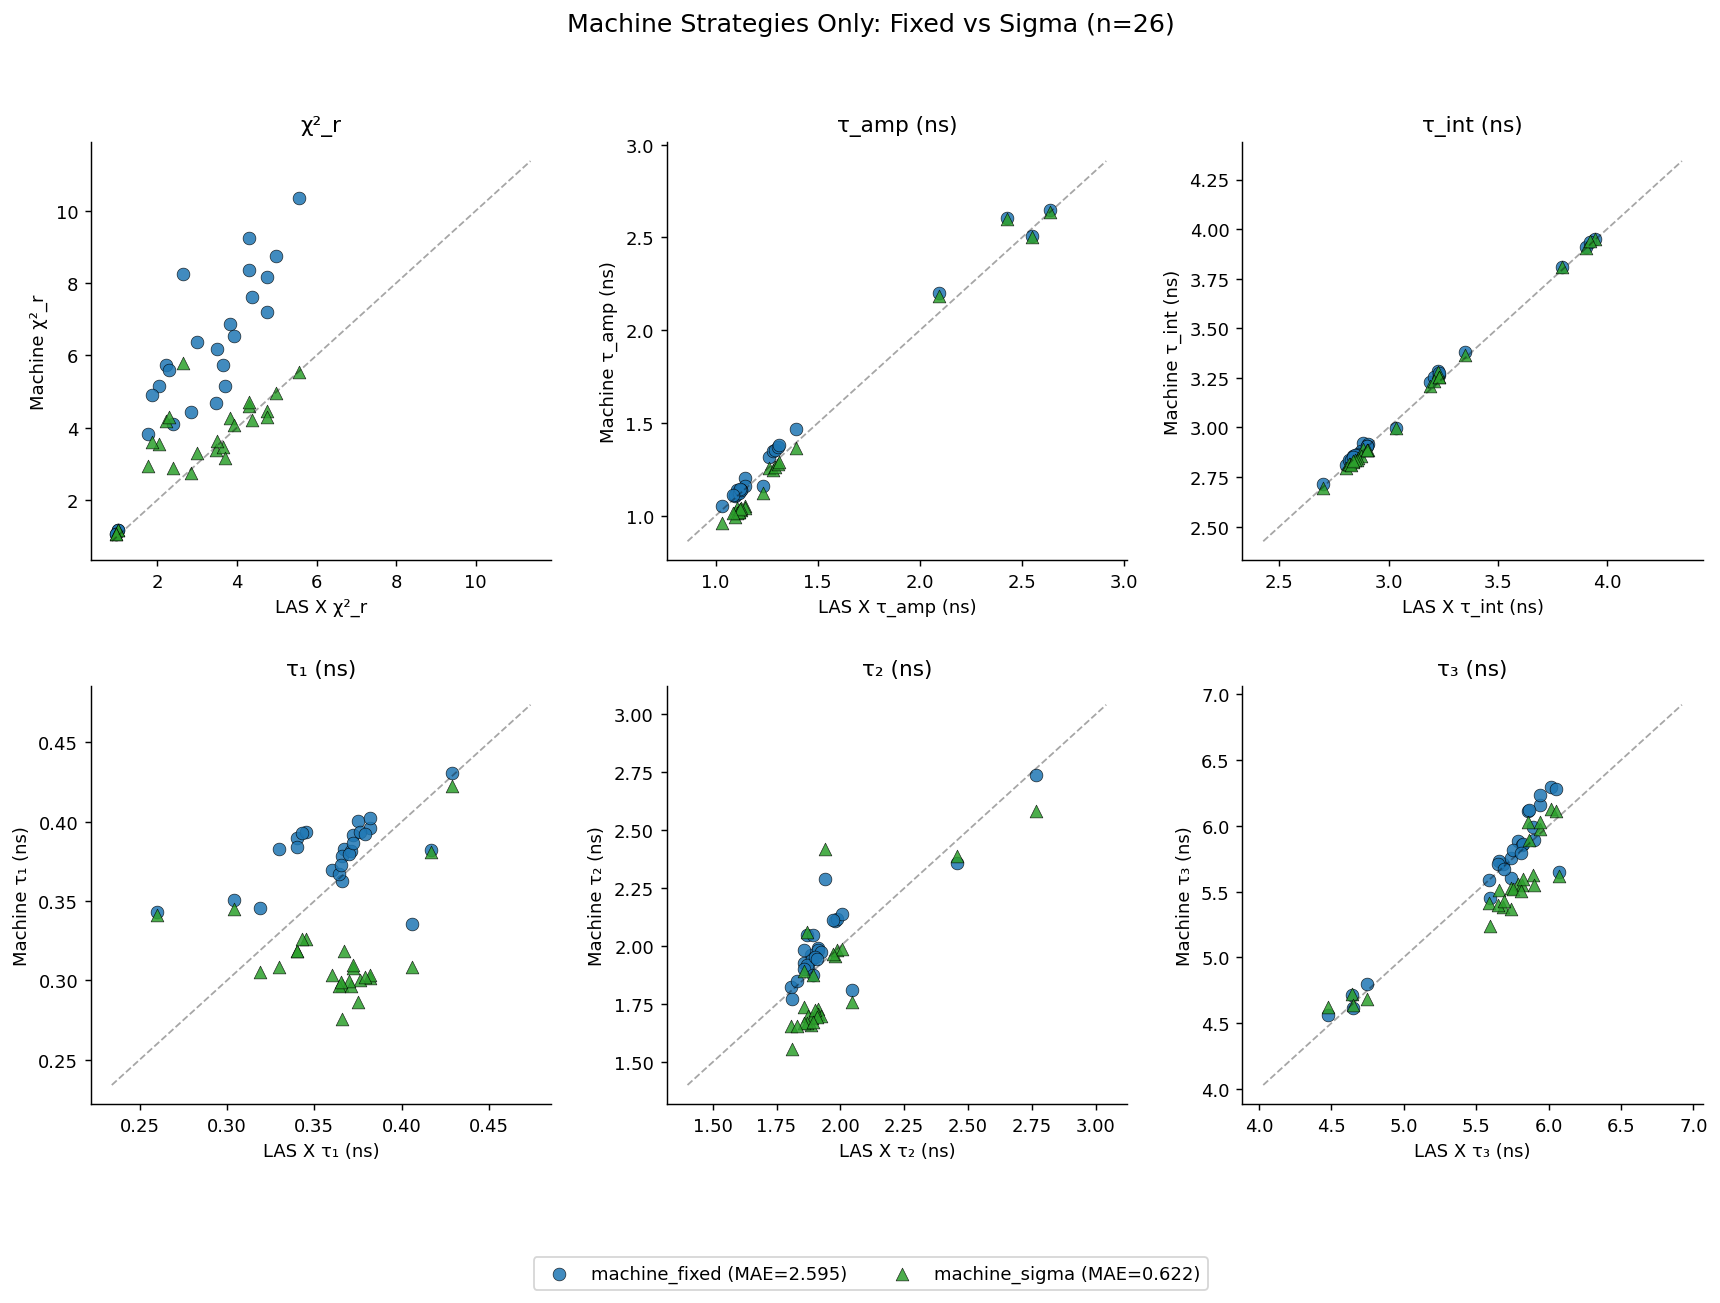

In [71]:
# ── Visual: Machine fixed vs Machine sigma only ───────────────────────────────
plot_df = strategy_df[strategy_df['strategy'].isin(['machine_fixed', 'machine_sigma'])].copy()

styles = {
    'machine_fixed': dict(color='tab:blue', marker='o'),
    'machine_sigma': dict(color='tab:green', marker='^'),
}

metrics_plot2 = [
    ('χ²_r', 'lasx_chi2', 'chi2'),
    ('τ_amp (ns)', 'lasx_tau_amp', 'tau_amp'),
    ('τ_int (ns)', 'lasx_tau_int', 'tau_int'),
    ('τ₁ (ns)', 'lasx_tau1', 'tau1'),
    ('τ₂ (ns)', 'lasx_tau2', 'tau2'),
    ('τ₃ (ns)', 'lasx_tau3', 'tau3'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Machine Strategies Only: Fixed vs Sigma (n=26)', fontsize=14, y=0.98)

for ax, (label, ref_col, y_col) in zip(axes.flat, metrics_plot2):
    # common bounds
    vals_x = plot_df[ref_col].values
    vals_y = plot_df[y_col].values
    lo = min(np.nanmin(vals_x), np.nanmin(vals_y)) * 0.9
    hi = max(np.nanmax(vals_x), np.nanmax(vals_y)) * 1.1
    if lo == hi:
        lo, hi = lo - 1, hi + 1

    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.35, lw=1)

    for strat in ['machine_fixed', 'machine_sigma']:
        g = plot_df[plot_df['strategy'] == strat]
        d = np.abs(g[y_col].values - g[ref_col].values)
        st = styles[strat]
        ax.scatter(g[ref_col].values, g[y_col].values,
                   s=50, alpha=0.85, c=st['color'], marker=st['marker'],
                   edgecolors='k', linewidths=0.35,
                   label=f"{strat} (MAE={d.mean():.3f})")

    ax.set_xlabel(f'LAS X {label}')
    ax.set_ylabel(f'Machine {label}')
    ax.set_title(label)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, frameon=True, bbox_to_anchor=(0.5, -0.01))
fig.subplots_adjust(bottom=0.14, wspace=0.25, hspace=0.30)
plt.show()

In [72]:
# ── R² ranking vs LAS X: which strategy is closest overall? ───────────────────
from scipy.stats import linregress

r2_rows = []
metrics_r2 = [
    ('chi2', 'lasx_chi2', 'chi2'),
    ('tau_amp', 'lasx_tau_amp', 'tau_amp'),
    ('tau_int', 'lasx_tau_int', 'tau_int'),
    ('tau1', 'lasx_tau1', 'tau1'),
    ('tau2', 'lasx_tau2', 'tau2'),
    ('tau3', 'lasx_tau3', 'tau3'),
]

for strat, g in strategy_df.groupby('strategy'):
    row = {'strategy': strat}
    r2_vals = []
    for label, xcol, ycol in metrics_r2:
        x = g[xcol].values
        y = g[ycol].values
        m = ~(np.isnan(x) | np.isnan(y))
        if m.sum() >= 3 and np.std(x[m]) > 0 and np.std(y[m]) > 0:
            lr = linregress(x[m], y[m])
            r2 = lr.rvalue ** 2
        else:
            r2 = np.nan
        row[f'r2_{label}'] = r2
        if not np.isnan(r2):
            r2_vals.append(r2)

    # Overall R² summaries
    row['r2_mean_all6'] = np.mean(r2_vals)
    row['r2_mean_lifetimes'] = np.mean([row['r2_tau_amp'], row['r2_tau_int'], row['r2_tau1'], row['r2_tau2'], row['r2_tau3']])

    # pooled overall R² over all points of all metrics
    X_pool, Y_pool = [], []
    for _, xcol, ycol in metrics_r2:
        x = g[xcol].values
        y = g[ycol].values
        m = ~(np.isnan(x) | np.isnan(y))
        X_pool.extend(x[m].tolist())
        Y_pool.extend(y[m].tolist())
    X_pool = np.array(X_pool)
    Y_pool = np.array(Y_pool)
    lr_pool = linregress(X_pool, Y_pool)
    row['r2_pooled'] = lr_pool.rvalue ** 2

    r2_rows.append(row)

r2_df = pd.DataFrame(r2_rows).sort_values('r2_mean_lifetimes', ascending=False)
print('R² per strategy vs LAS X:')
print(r2_df[['strategy', 'r2_chi2', 'r2_tau_amp', 'r2_tau_int', 'r2_tau1', 'r2_tau2', 'r2_tau3',
             'r2_mean_lifetimes', 'r2_mean_all6', 'r2_pooled']]
      .to_string(index=False, float_format=lambda x: f'{x:.4f}'))

best_life = r2_df.iloc[0]['strategy']
best_pooled = r2_df.sort_values('r2_pooled', ascending=False).iloc[0]['strategy']
print(f"\nBest by mean lifetime R²: {best_life}")
print(f"Best by pooled overall R²: {best_pooled}")

R² per strategy vs LAS X:
          strategy  r2_chi2  r2_tau_amp  r2_tau_int  r2_tau1  r2_tau2  r2_tau3  r2_mean_lifetimes  r2_mean_all6  r2_pooled
     machine_fixed   0.7872      0.9914      0.9978   0.2633   0.7518   0.9063             0.7821        0.7830     0.7698
     machine_sigma   0.5981      0.9927      0.9982   0.0268   0.6105   0.8369             0.6930        0.6772     0.9432
machine_sigma_tail   0.2685      0.8650      0.3730   0.4382   0.0612   0.0087             0.3492        0.3358     0.3078
      leica_interp   0.0421      0.8154      0.2166   0.0694   0.0678   0.0667             0.2472        0.2130     0.3042

Best by mean lifetime R²: machine_fixed
Best by pooled overall R²: machine_sigma


In [73]:
# ── R² ranking (lifetimes only; χ² excluded) ───────────────────────────────────
from scipy.stats import linregress

lifetime_metrics = [
    ('tau_amp', 'lasx_tau_amp', 'tau_amp'),
    ('tau_int', 'lasx_tau_int', 'tau_int'),
    ('tau1', 'lasx_tau1', 'tau1'),
    ('tau2', 'lasx_tau2', 'tau2'),
    ('tau3', 'lasx_tau3', 'tau3'),
]

rows_life = []
for strat, g in strategy_df.groupby('strategy'):
    row = {'strategy': strat}
    r2_vals = []
    for label, xcol, ycol in lifetime_metrics:
        x = g[xcol].values
        y = g[ycol].values
        m = ~(np.isnan(x) | np.isnan(y))
        if m.sum() >= 3 and np.std(x[m]) > 0 and np.std(y[m]) > 0:
            lr = linregress(x[m], y[m])
            r2 = lr.rvalue ** 2
        else:
            r2 = np.nan
        row[f'r2_{label}'] = r2
        if not np.isnan(r2):
            r2_vals.append(r2)

    row['r2_mean_lifetimes'] = float(np.mean(r2_vals)) if len(r2_vals) else np.nan

    # pooled R² using only lifetime points
    X_pool, Y_pool = [], []
    for _, xcol, ycol in lifetime_metrics:
        x = g[xcol].values
        y = g[ycol].values
        m = ~(np.isnan(x) | np.isnan(y))
        X_pool.extend(x[m].tolist())
        Y_pool.extend(y[m].tolist())
    X_pool = np.array(X_pool)
    Y_pool = np.array(Y_pool)
    if len(X_pool) >= 3 and np.std(X_pool) > 0 and np.std(Y_pool) > 0:
        lr_pool = linregress(X_pool, Y_pool)
        row['r2_pooled_lifetimes'] = lr_pool.rvalue ** 2
    else:
        row['r2_pooled_lifetimes'] = np.nan

    rows_life.append(row)

r2_life_df = pd.DataFrame(rows_life).sort_values('r2_mean_lifetimes', ascending=False)
print('R² vs LAS X (lifetimes only; χ² excluded):')
print(r2_life_df[['strategy', 'r2_tau_amp', 'r2_tau_int', 'r2_tau1', 'r2_tau2', 'r2_tau3',
                  'r2_mean_lifetimes', 'r2_pooled_lifetimes']]
      .to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print(f"\nBest by mean lifetime R²: {r2_life_df.iloc[0]['strategy']}")
print(f"Best by pooled lifetime R²: {r2_life_df.sort_values('r2_pooled_lifetimes', ascending=False).iloc[0]['strategy']}")

R² vs LAS X (lifetimes only; χ² excluded):
          strategy  r2_tau_amp  r2_tau_int  r2_tau1  r2_tau2  r2_tau3  r2_mean_lifetimes  r2_pooled_lifetimes
     machine_fixed      0.9914      0.9978   0.2633   0.7518   0.9063             0.7821               0.9978
     machine_sigma      0.9927      0.9982   0.0268   0.6105   0.8369             0.6930               0.9955
machine_sigma_tail      0.8650      0.3730   0.4382   0.0612   0.0087             0.3492               0.6555
      leica_interp      0.8154      0.2166   0.0694   0.0678   0.0667             0.2472               0.6758

Best by mean lifetime R²: machine_fixed
Best by pooled lifetime R²: machine_fixed
